# [분할 작업본 1/4] FFCell v80 (PART 번호 연속 정리판) — 환경설정 · 데이터 전처리 · EDA · 가설검정 · 피처엔지니어링

- 범위: PART 1~4 (cell 0~132)
- 원본: `FFCell_integrated_notebook_v80_PART연속.ipynb` (PART 15~19 번호를 연속으로 재정리한 버전)

기존 v80의 `df_all`/`final_features` 체크포인트 셀(맨 위, PART1 끝)은 그대로 유지되어 있다.
---


# FFCell 로봇 제조 셀 — 결함 분류 프로젝트 (통합 재구성판)

## 개요
이 노트북은 팀의 여러 분석 경로(개인 탐색, 멘토 피드백, 팀원 교차검증)에서 나온 결과를 하나의
일관된 흐름으로 재구성한 버전이다. 특히 아래 두 가지 핵심 수정 사항을 전체 파이프라인에
반영했다.

1. **R04 딥그랩 순번 재해석**: 5회 딥그랩 = 트레이 집기(1회) + 부품 분해(4회). 기존에
   "1번째=Nose"로 가정했던 것을 "2번째=Nose(State11, ~206초)"로 정정했다.
2. **Nose 판별 주 신호 교체**: R04 힘 대신, **R03 조립구간 93~100초 최댓값**을 채택했다.
   이 신호는 Normal vs NoNose를 압도적으로 잘 가르며(교차검증으로 확인), R04 힘은 시간대(세션)에
   따라 흔들리는 교란 변수였음이 밝혀져 격하되었다.

탐색 과정에서 나왔던 여러 가설(방향전환빈도, 부호-Pot 방향 일치율 등)은 최종적으로 채택되지
않았으므로 이 재구성판에는 생략했으며, 그 과정과 이유는 부록에 요약만 남긴다.

| 항목 | 내용 |
|------|------|
| 수집 기간 | 2023-12-11 ~ 2023-12-12 (약 29시간) |
| 설비 | 6축 로봇 4대(R01~R04) 조립 라인, 10Hz 샘플링 |
| 원시 데이터 | 974,836행 × 63컬럼, CSV 7개 병합 |
| 사이클 수 (원본 스펙) | 327개 → 지속시간 기준 불완전 2개 제거 → **325개** |
| 사이클 수 (최종 사용) | 325개 중 데이터 수집 초반 워밍업으로 추정되는 R04 그리퍼 부하 변동성
이상 사이클 5개(`0_1~0_3`, `1_1`,`1_2`) 제외 → **320개** (v80 정정 — 상세 근거는 14장) |
| 라벨(4클래스) | Normal / NoNose / NoNose,NoBody2 / NoNose,NoBody2,NoBody1 |


> **v55 갱신**: PART 6(25~30장, 베이스라인 사다리·recall/PR-AUC·SMOTE 비교·confusion matrix 스토리·이상 사이클 민감도 분석)을 새로 추가했다.

> **v56 갱신**: 오늘 멘토 피드백을 반영해 PART 7(31~35장, 시간 상관관계 전수조사·R04 오염 재검토 및 전면 제외·세션 내 상대값 전환·베이스라인 재검증·최종 결론 갱신)을 추가했다.

> **v57 갱신**: 같은 팀원의 독립 분석(R04 오염 검증 보고서)과 비교해 PART 8(36~40장, 라벨통제 시간상관관계 재검증·최종 피처셋 확정·Block A 직접 검증·GroupKFold 근본원인 정량화·통합 결론)을 추가했다.

> **v58 갱신**: PART 9(41~45장, Block A 전체데이터 재검증·I_R02_Gripper_Pot_min 최종 판정·세션상대값 축소판·종합 재검증·최종 결론)을 추가했다.

> **v59 갱신**: PART 10(46~50장, Body1·Body2 슬롯 신호 추출·효과크기 비교·부품별 계층적 판정 규칙·세션5 내부 시간분할 검증·최종 결론)을 추가했다.

> **v60 갱신**: PART 11(51~54장)에서 v59의 3가지 설계 결함(결측 처리·NaN 임계값·불공정한 시간분할)을 수정하고 재검증했다.

> **v61 갱신**: PART 12(55~58장)에서 NoBody2·NoBody1을 학습에서 완전히 제외한 진짜 GroupKFold 상황을 재현해 규칙기반과 ML을 재대결시켰다.

> **v79 갱신**: 18-2 절에서 고친 `rise_slope` NaN 버그의 잔여 경계 케이스(`t_peak == start`,
예: `5_182`)를 추가로 수정하고(18-2-1), 그 수정이 만드는 극단치(분모 클리핑 아티팩트)를
진단하여 IQR 기반 클리핑을 도입했다(18-2-2).

> **v80 갱신**: (1) `1_1`,`1_2`·세션0(`0_1~3`) 제외 근거를 "센서 값 비어있음"(오류로 확인됨)에서
"R04 그리퍼 부하 표준편차가 전체 327개 사이클 중 압도적 상위 5개"(원본 CSV로 재검증, 6위와
뚜렷한 격차)로 정정했다(14장). (2) PART 1 종료 시점(`df_all`)과 PART 4 종료 시점
(`final_features`)에 체크포인트 캐싱을 추가해, 뒷부분 PART만 반복 디버깅할 때 무거운
로드·병합·전처리를 매번 다시 돌릴 필요가 없도록 했다.

## 체크포인트 캐싱 안내 (v80 신규, 선택사항)

PART 1(원본 CSV 로드·병합·전처리, 974,836행)이 전체 파이프라인에서 가장 오래 걸리는 단계다.
PART 17 이후처럼 뒷부분만 반복해서 디버깅할 때도 매번 여기서부터 다시 돌리는 건 비효율적이라,
**PART 1 종료 시점(`df_all`)**과 **PART 4 종료 시점(`final_features`)**에 체크포인트를 저장해두고
필요할 때 바로 불러와 이어서 시작할 수 있게 했다.

- 평소(전체를 처음부터 다시 검증할 때)에는 아래 셀의 `USE_CHECKPOINT = None`을 그대로 두고
  PART 1부터 순서대로 실행하면 된다 — 각 체크포인트는 해당 PART 끝에서 자동 저장된다.
- 뒷부분(PART 5 이후, 특히 PART 17 근처)만 빠르게 반복 확인하고 싶을 때는 아래 셀에서
  `USE_CHECKPOINT = 'final_features'`로 바꾸고 실행한 뒤, **PART 5 셀부터** 이어서 실행한다.
- PART 2~4(EDA·가설검정·파생변수)까지는 다시 보고 싶지만 PART 1(가장 무거운 로드·병합)은
  건너뛰고 싶다면 `USE_CHECKPOINT = 'df_all'`로 바꾸고 **PART 2 셀부터** 이어서 실행한다.


In [1]:
# ── 빠른 재시작용 체크포인트 로드 (v80 신규, 선택사항) ──────────────────────────
USE_CHECKPOINT = None  # 'df_all' | 'final_features' | None  ← 평소엔 None 유지

from pathlib import Path
import pandas as pd

_CACHE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints')

if USE_CHECKPOINT is not None:
    from google.colab import drive
    drive.mount('/content/drive')
    _path = _CACHE_DIR / f'{USE_CHECKPOINT}.pkl'
    if _path.exists():
        globals()[USE_CHECKPOINT] = pd.read_pickle(_path)
        _obj = globals()[USE_CHECKPOINT]
        print(f"[체크포인트 로드 완료] {USE_CHECKPOINT} ← {_path}")
        print(f"  shape: {_obj.shape}")
        if USE_CHECKPOINT == 'df_all':
            print("  → 이제 PART 2(EDA)부터 순서대로 실행하세요. PART 1 셀은 건너뛰어도 됩니다.")
        elif USE_CHECKPOINT == 'final_features':
            print("  → 이제 PART 5(모델링)부터 순서대로 실행하세요. PART 1~4 셀은 건너뛰어도 됩니다.")
    else:
        print(f"[체크포인트 없음] {_path} 파일이 없습니다 — 아래 PART를 순서대로 한 번 실행해서")
        print("  체크포인트를 먼저 만들어두세요(각 PART 끝에서 자동 저장됩니다).")
else:
    print("[체크포인트 미사용] USE_CHECKPOINT = None — 처음부터(PART 1 셀부터) 정상 실행합니다.")


[체크포인트 미사용] USE_CHECKPOINT = None — 처음부터(PART 1 셀부터) 정상 실행합니다.


---
# PART 1. 데이터 전처리

환경 설정 → 원본 CSV 로드/병합(사이클 수 327개 확정) → 기본 정보 확인 → 라벨(결함 클래스) 분포 확인 → 결측치·이상치 처리.
---

## 0. 환경 설정

In [2]:
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib as mpl
import matplotlib.font_manager as fm
fm.fontManager.__init__()
mpl.rc("font", family="NanumGothic")
mpl.rcParams["axes.unicode_minus"] = False
print("나눔고딕 설정 완료")

나눔고딕 설정 완료


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FFCell')  # ← 경로 수정

FILES = {
    'safety'  : 'FFCell_SafetyManagement.csv',
    'R01'     : 'R01_Data.csv',
    'R02'     : 'R02_Data.csv',
    'R03'     : 'R03_Data.csv',
    'R04'     : 'R04_Data.csv',
    'conveyor': 'Conveyor_Signals.csv',
    'cycle'   : 'FFCell_CycleManagement.csv',
}

LABEL_ORDER = ['Normal', 'NoNose', 'NoNose,NoBody2', 'NoNose,NoBody2,NoBody1']
LABEL_MAP   = {'Normal': 0, 'NoNose': 1, 'NoNose,NoBody2': 2, 'NoNose,NoBody2,NoBody1': 3}
COLORS      = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
ROBOTS      = ['R01', 'R02', 'R03', 'R04']

## 1. 데이터 로드 및 병합

In [5]:
dfs = {}
for key, fname in FILES.items():
    df = pd.read_csv(DATA_DIR / fname, parse_dates=['_time'], low_memory=False)
    if key != 'cycle':
        df = df.drop(columns=['Description'], errors='ignore')
    dfs[key] = df
    print(f'[{key:8s}] {df.shape}')

[safety  ] (974836, 5)
[R01     ] (974836, 9)
[R02     ] (974836, 9)
[R03     ] (974836, 9)
[R04     ] (974836, 9)
[conveyor] (974836, 10)
[cycle   ] (974836, 4)


In [6]:
# ── 병합 전 _time 품질 점검 ──────────────────────────────────────
for key, df in dfs.items():
    null_cnt = df['_time'].isna().sum()
    dup_cnt  = df['_time'].duplicated().sum()
    print(f'[{key:8s}]  전체: {len(df):,}  |  결측: {null_cnt:,}  |  중복: {dup_cnt:,}')

[safety  ]  전체: 974,836  |  결측: 0  |  중복: 0
[R01     ]  전체: 974,836  |  결측: 0  |  중복: 0
[R02     ]  전체: 974,836  |  결측: 0  |  중복: 0
[R03     ]  전체: 974,836  |  결측: 0  |  중복: 0
[R04     ]  전체: 974,836  |  결측: 0  |  중복: 0
[conveyor]  전체: 974,836  |  결측: 0  |  중복: 0
[cycle   ]  전체: 974,836  |  결측: 0  |  중복: 0


### 참고: 왜 327개인가? (이식 — ZeroEscape_CycleAnalysis)

`Q_Cell_CycleCount`는 0~275까지의 값을 가지므로 `unique()` 기준으로는 276개로 보인다.
하지만 약 29시간 수집 구간 동안 **사이클 카운터가 5번 리셋**되면서 동일한 번호가 재사용되었다.
리셋이 발생하면 카운터가 감소(예: 6→0, 15→1)하므로, `diff() < 0`인 시점을 세션 경계로 삼으면
6개 세션(=아래 `reset_flag` 0~5)으로 나뉘고, 세션별 사이클을 합산하면 총 **327개**가 된다.
이후 불완전 사이클 2개(자동 탐지)를 제거하면 **325개**로 확정된다.

In [7]:
# ── [개선 8] cycle_id 생성 — merge 전 cycle 원본에서 계산 ──────────
#
# 문제: outer merge 후 타 파일 타임스탬프가 끼어들면서
#       diff() 계산 시 14:09 구간에 가짜 리셋 감지 → 329개 오류
# 해결: merge 전 순수한 cycle 파일에서 diff() 계산
#       → merge 후에는 ffill로 전파

cycle_raw = dfs['cycle'].copy()
cycle_raw['Q_Cell_CycleCount'] = pd.to_numeric(
    cycle_raw['Q_Cell_CycleCount'], errors='coerce')
cycle_raw['reset_flag'] = (cycle_raw['Q_Cell_CycleCount'].diff() < 0).cumsum()
cycle_raw['cycle_id']   = (cycle_raw['reset_flag'].astype(str)
                            + '_'
                            + cycle_raw['Q_Cell_CycleCount'].astype(str))

print(f'cycle 원본 reset_flag: {sorted(cycle_raw["reset_flag"].unique())}  (기대: 0~5)')
print(f'cycle 원본 cycle_id 수: {cycle_raw["cycle_id"].nunique()}  (기대: 327)')

# cycle_id 포함 상태로 갱신
dfs['cycle'] = cycle_raw

# ── outer merge → 정렬 → _time datetime 변환 ─────────────────────
df_all = dfs['cycle'].copy()
for key in ['safety', 'R01', 'R02', 'R03', 'R04', 'conveyor']:
    df_all = df_all.merge(dfs[key], on='_time', how='outer')

df_all = (df_all
          .dropna(subset=['_time'])
          .drop_duplicates(subset=['_time'], keep='first')
          .sort_values('_time')
          .reset_index(drop=True))

# [개선 1] _time 변환을 병합 직후 수행
df_all['_time'] = pd.to_datetime(
    df_all['_time'].astype(str).str.replace('Z', '', regex=False),
    format='mixed'
)

# merge 후 cycle_id / reset_flag → ffill (다른 파일 타임스탬프 행 NaN 채움)
df_all['cycle_id']   = df_all['cycle_id'].ffill()
df_all['reset_flag'] = df_all['reset_flag'].ffill().fillna(0).astype(int)

print(f'\n병합 결과 : {df_all.shape}')
print(f'_time     : {df_all["_time"].dtype}')
print(f'범위      : {df_all["_time"].min()} ~ {df_all["_time"].max()}')
print(f'중복 행   : {len(df_all) - df_all["_time"].nunique():,}건')
print(f'\nmerge 후 reset_flag: {sorted(df_all["reset_flag"].unique())}  (기대: 0~5)')
print(f'merge 후 cycle_id 수: {df_all["cycle_id"].nunique()}  (기대: 327)')
print()
for flag in sorted(df_all['reset_flag'].unique()):
    seg = df_all[df_all['reset_flag'] == flag]
    t_s = seg['_time'].min().strftime('%m-%d %H:%M')
    t_e = seg['_time'].max().strftime('%m-%d %H:%M')
    print(f'  reset_flag={flag}  {t_s}~{t_e}  사이클수={seg["cycle_id"].nunique()}')

# ── 불완전 사이클 자동 탐지: Duration(초) 기준 ───────────────────
# [변경] 하드코딩(INCOMPLETE = ['2_0', '4_0']) → Duration 기반 자동 탐지
# 근거: 10Hz 균일 샘플링이므로 행 수 ≈ Duration × 10이지만,
#       샘플링 결손/중복 제거에 더 안정적인 Duration(초)을 직접 기준으로 삼는다.
cycle_duration = (
    df_all.groupby('cycle_id')['_time']
    .agg(lambda s: (s.max() - s.min()).total_seconds())
    .rename('duration_sec')
)
log_dur = np.log1p(cycle_duration)
q1, q3  = log_dur.quantile([0.25, 0.75])
iqr     = q3 - q1
lower   = q1 - 3 * iqr  # 하한만 사용 (짧은 사이클 = 불완전 의심)

incomplete_auto = log_dur[log_dur < lower].index.tolist()
print(f'Duration 기준 불완전 사이클 자동 탐지: {incomplete_auto}')
print(f'(참고) 기존 하드코딩 기준과 일치 여부: {set(incomplete_auto) == {"2_0", "4_0"}}')

before = len(df_all)
df_all = df_all[~df_all['cycle_id'].isin(incomplete_auto)].reset_index(drop=True)
print(f'\n불완전 사이클 제거: {incomplete_auto}  ({before - len(df_all):,}행 제거)')
print(f'잔여 고유 사이클  : {df_all["cycle_id"].nunique()}개  ✅ (문서 기준 325개)')

cycle 원본 reset_flag: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]  (기대: 0~5)
cycle 원본 cycle_id 수: 327  (기대: 327)

병합 결과 : (974836, 51)
_time     : datetime64[ns]
범위      : 2023-12-11 13:04:12.348000 ~ 2023-12-12 18:07:42.283000
중복 행   : 0건

merge 후 reset_flag: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]  (기대: 0~5)
merge 후 cycle_id 수: 327  (기대: 327)

  reset_flag=0  12-11 13:04~12-11 13:18  사이클수=3
  reset_flag=1  12-11 13:49~12-11 14:19  사이클수=6
  reset_flag=2  12-11 14:27~12-11 15:41  사이클수=16
  reset_flag=3  12-11 16:50~12-11 17:46  사이클수=11
  reset_flag=4  12-11 17:50~12-11 19:08  사이클수=16
  reset_flag=5  12-11 19:15~12-12 18:07  사이클수=275
Duration 기준 불완전 사이클 자동 탐지: ['2_0', '4_0']
(참고) 기존 하드코딩 기준과 일치 여부: True

불완전 사이클 제거: ['2_0', '4_0']  (199행 제거)
잔여 고유 사이클  : 325개  ✅ (문서 기준 325개)


In [8]:
# ── [개선 2] label 생성 + 타임스탬프 중복 체크 ──────────────────────
df_all['label'] = df_all['Description'].fillna('').replace('', 'Normal')

total      = len(df_all)
unique     = df_all['_time'].nunique()
duplicated = total - unique
print(f'전체 행 수  : {total:,}')
print(f'중복 행     : {duplicated:,}건')
print()
print('행 단위 라벨 분포:')
print(df_all['label'].value_counts())

전체 행 수  : 974,637
중복 행     : 0건

행 단위 라벨 분포:
label
Normal                    481976
NoNose                    177644
NoNose,NoBody2,NoBody1    161166
NoNose,NoBody2            153851
Name: count, dtype: int64


## 2. 기본 정보 확인

In [9]:
df_all.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974637 entries, 0 to 974636
Data columns (total 52 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   _time                     974637 non-null  datetime64[ns]
 1   Q_Cell_CycleCount         974637 non-null  int64         
 2   I_MHS_GreenRocketTray     974637 non-null  bool          
 3   Description               492661 non-null  object        
 4   reset_flag                974637 non-null  int64         
 5   cycle_id                  974637 non-null  object        
 6   CabinetESTOP              0 non-null       float64       
 7   I_SafetyDoor1_Status      974637 non-null  bool          
 8   I_SafetyDoor2_Status      974637 non-null  bool          
 9   I_HMI_EStop_Status        974637 non-null  bool          
 10  I_R01_Gripper_Load        974637 non-null  int64         
 11  I_R01_Gripper_Pot         974637 non-null  int64         
 12  M_

In [10]:
# Boolean 변환
# [버그 수정] 기존 코드는 이미 bool dtype인 컬럼에도 무조건
#   df_all[col].map({'TRUE': True, 'FALSE': False}) 를 적용했다.
#   실제 True/False 값은 문자열 'TRUE'/'FALSE'와 매칭되지 않아 전부 NaN이 되는
#   문제가 있었다(실행 결과에서 안전/스토퍼 컬럼 974,637건 전부 결측으로 확인됨).
#   → dtype이 이미 bool이면 매핑을 건너뛰고, object(문자열)일 때만 매핑한다.
bool_cols = [
    'CabinetESTOP',
    'I_SafetyDoor1_Status', 'I_SafetyDoor2_Status', 'I_HMI_EStop_Status',
    'I_Stopper1_Status', 'I_Stopper2_Status', 'I_Stopper3_Status',
    'I_Stopper4_Status', 'I_Stopper5_Status', 'I_MHS_GreenRocketTray',
]
for col in bool_cols:
    if col not in df_all.columns:
        continue
    if df_all[col].dtype == bool:
        print(f'{col}: 이미 bool dtype — 매핑 건너뜀')
        continue
    before_null = df_all[col].isna().sum()
    df_all[col] = df_all[col].map({'TRUE': True, 'FALSE': False})
    after_null = df_all[col].isna().sum()
    print(f'{col}: object -> bool 매핑 완료 '
          f'(결측 {before_null:,} -> {after_null:,})')

num_cols = df_all.select_dtypes(include='number').columns.tolist()
print(f'\n수치형 컬럼 수: {len(num_cols)}')
df_all[num_cols].describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

CabinetESTOP: object -> bool 매핑 완료 (결측 974,637 -> 974,637)
I_SafetyDoor1_Status: 이미 bool dtype — 매핑 건너뜀
I_SafetyDoor2_Status: 이미 bool dtype — 매핑 건너뜀
I_HMI_EStop_Status: 이미 bool dtype — 매핑 건너뜀
I_Stopper1_Status: 이미 bool dtype — 매핑 건너뜀
I_Stopper2_Status: 이미 bool dtype — 매핑 건너뜀
I_Stopper3_Status: 이미 bool dtype — 매핑 건너뜀
I_Stopper4_Status: 이미 bool dtype — 매핑 건너뜀
I_Stopper5_Status: 이미 bool dtype — 매핑 건너뜀
I_MHS_GreenRocketTray: 이미 bool dtype — 매핑 건너뜀

수치형 컬럼 수: 38


,count,mean,std,min,25%,50%,75%,max
Q_Cell_CycleCount,974637.000000,117.468514,87.081706,1.000000,31.000000,113.000000,194.000000,275.000000
reset_flag,974637.000000,4.627357,0.989479,0.000000,5.000000,5.000000,5.000000,5.000000
I_R01_Gripper_Load,974637.000000,393.442557,64.563510,-259.000000,359.000000,394.000000,432.000000,822.000000
I_R01_Gripper_Pot,974637.000000,11030.408889,968.872591,4523.000000,11143.000000,11184.000000,11227.000000,11785.000000
M_R01_BJointAngle_Degree,974637.000000,-82.779032,23.639450,-90.988075,-90.001137,-90.001137,-90.001137,0.000000
M_R01_LJointAngle_Degree,974637.000000,1.483512,6.755369,0.000000,0.000749,0.000749,0.000749,47.938351
M_R01_RJointAngle_Degree,974637.000000,-0.174187,0.870483,-5.540575,0.001235,0.001235,0.001235,0.001853
M_R01_SJointAngle_Degree,974637.000000,-3.392041,15.698841,-100.202698,0.001872,0.001872,0.001872,0.001872
M_R01_TJointAngle_Degree,974637.000000,1.211939,8.014770,-9.127035,0.001853,0.001853,0.001853,56.684830
M_R01_UJointAngle_Degree,974637.000000,84.284868,24.271740,0.000000,89.998543,89.998543,89.998543,135.899231


## 3. 라벨(결함 클래스) 분포

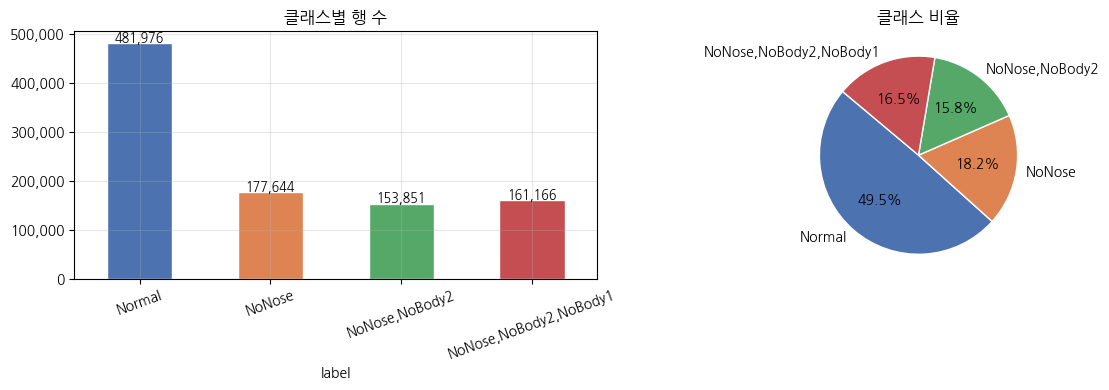

label
Normal                    481976
NoNose                    177644
NoNose,NoBody2            153851
NoNose,NoBody2,NoBody1    161166
Name: count, dtype: int64


In [11]:
label_counts = df_all['label'].value_counts().reindex(LABEL_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_counts.plot(kind='bar', ax=axes[0], color=COLORS, edgecolor='white', rot=20)
axes[0].set_title('클래스별 행 수')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(axes[0].patches, label_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+3000,
                 f'{val:,}', ha='center', fontsize=9)

axes[1].pie(label_counts, labels=LABEL_ORDER, autopct='%1.1f%%',
            colors=COLORS, startangle=140, wedgeprops={'edgecolor':'white'})
axes[1].set_title('클래스 비율')

plt.tight_layout()
plt.show()
print(label_counts)

### 3-1. 사이클 단위 클래스 분포 + 시간축 타임라인 (이식 — ZeroEscape_EDA Step3)

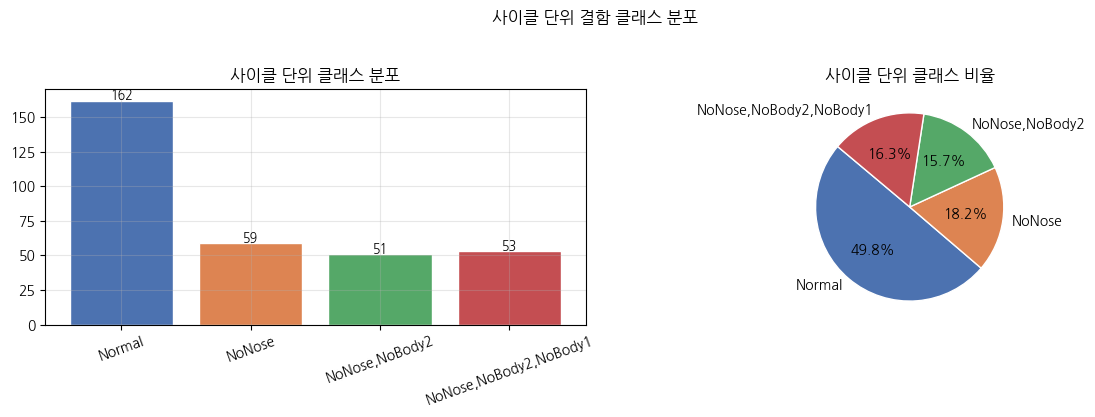

label
Normal                    162
NoNose                     59
NoNose,NoBody2             51
NoNose,NoBody2,NoBody1     53
Name: count, dtype: int64


In [12]:
# ── 사이클 단위 클래스 분포 (행 단위 분포와 별도로 확인) ──────────────
cycle_label_dist   = df_all.groupby('cycle_id')['label'].max()
cycle_class_counts = cycle_label_dist.value_counts().reindex(LABEL_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(cycle_class_counts.index, cycle_class_counts.values,
            color=COLORS, edgecolor='white')
axes[0].set_title('사이클 단위 클래스 분포')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(axes[0].patches, cycle_class_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:,}', ha='center', fontsize=9)

axes[1].pie(cycle_class_counts, labels=LABEL_ORDER, autopct='%1.1f%%',
            colors=COLORS, startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('사이클 단위 클래스 비율')

plt.suptitle('사이클 단위 결함 클래스 분포', y=1.03)
plt.tight_layout()
plt.show()
print(cycle_class_counts)

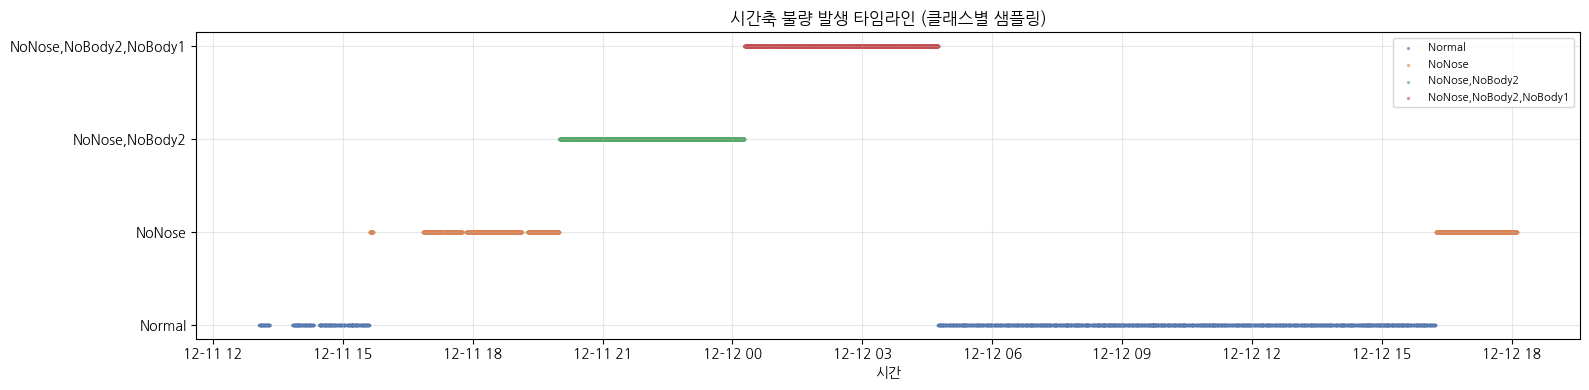

In [13]:
# ── 시간축 불량 발생 타임라인 (행이 많아 클래스별 샘플링) ─────────────
fig, ax = plt.subplots(figsize=(16, 4))
for lbl in LABEL_ORDER:
    grp    = df_all[df_all['label'] == lbl]
    sample = grp.sample(min(len(grp), 5000), random_state=42)
    ax.scatter(sample['_time'], [LABEL_MAP[lbl]] * len(sample),
               c=COLORS[LABEL_MAP[lbl]], s=2, alpha=0.5, label=lbl)

ax.set_yticks(list(LABEL_MAP.values()))
ax.set_yticklabels(LABEL_ORDER)
ax.set_title('시간축 불량 발생 타임라인 (클래스별 샘플링)')
ax.set_xlabel('시간')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

> ⚠️ **라벨 타이밍 주의사항**: 위 두 그림은 `label`을 행(row) 단위로 그대로 사용한다.
> 그런데 `label`은 사이클의 **최종 판정 결과**가 사이클 전체 구간(조립 전 포함)에
> 동일하게 반복 기록된 값이다. 즉 아직 부품을 조립하지도 않은 사이클 초반 구간까지도
> "불량" 라벨이 찍혀 보인다. 사이클 단위 요약(섹션 11, 12)은 이 문제와 무관하지만,
> 이런 행 단위 시각화는 해석에 주의가 필요하다. → **섹션 15에서 조립구간 기준으로 재검증한다.**

## 4. 결측치 / 이상치 처리

In [14]:
null_summary = df_all.isnull().sum()
null_summary = null_summary[null_summary > 0]
print(f'결측치가 있는 컬럼: {len(null_summary)}개')
print(null_summary)

결측치가 있는 컬럼: 2개
Description     481976
CabinetESTOP    974637
dtype: int64


### 4-1. VFD 오버플로우 특이값 플래그 (이식 — ZeroEscape_EDA)

In [15]:
# ── IEEE754 float 오버플로우(±2.98e38 수준) 특이값을 별도 플래그로 보존 ──
# 아래 셀(범위/변화율 필터)이 값을 NaN으로 바꾸기 전에 먼저 플래그를 만들어 둔다.
# 오버플로우는 "극단값"만 잡고, 다음 셀의 rate-of-change 필터는 "정상 범위 안의
# 미세한 글리치"까지 잡으므로 서로 보완적이다 — 최종 사용 여부는 팀 논의 후 결정.
FAULT_THRESHOLD = 1000  # 온도로서 물리적으로 불가능한 절대값 기준(°F)  # [수정] 튜터 피드백: 실제 값 범위(0~200)가 VFD 정상 작동온도와 맞는 건 화씨 기준 -> 라벨을 °C에서 °F로 정정 (값 변환 아님)
vfd_cols_pre = ['Q_VFD1_Temperature', 'Q_VFD2_Temperature',
                'Q_VFD3_Temperature', 'Q_VFD4_Temperature']

for col in vfd_cols_pre:
    fault_col = f'{col}_fault'
    df_all[fault_col] = df_all[col].abs() > FAULT_THRESHOLD
    n_fault = df_all[fault_col].sum()
    print(f'{col}: 오버플로우 의심 {n_fault:,}건 (|value| > {FAULT_THRESHOLD})')

Q_VFD1_Temperature: 오버플로우 의심 0건 (|value| > 1000)
Q_VFD2_Temperature: 오버플로우 의심 4,626건 (|value| > 1000)
Q_VFD3_Temperature: 오버플로우 의심 4,113건 (|value| > 1000)
Q_VFD4_Temperature: 오버플로우 의심 4,136건 (|value| > 1000)


In [16]:
# ── VFD 온도 이상치 처리 (물리 범위 0~200°F + 변화율 기반 글리치 탐지) ─────
# [수정] 튜터 피드백 반영: raw 값 범위가 화씨 기준 VFD 정상 작동온도(약 32~200°F)와
#        일치함을 확인 -> 단위 라벨을 °C에서 °F로 정정 (수치 변환은 하지 않음)
# [수정] 범위 필터만으로는 2.94e-38처럼 "0~200 범위 안에 있는 글리치"를
#        잡지 못하므로, 직전/직후 값과의 변화율(rate of change)을 추가로 본다.
vfd_cols = ['Q_VFD1_Temperature','Q_VFD2_Temperature',
            'Q_VFD3_Temperature','Q_VFD4_Temperature']

MAX_JUMP_PER_SAMPLE = 5  # 10Hz(0.1초) 기준 허용 가능한 최대 온도 변화(°F), 값 조정 필요

for col in vfd_cols:
    before_null = df_all[col].isna().sum()

    # 1) 기존 범위 필터
    range_outlier = (df_all[col] < 0) | (df_all[col] > 200)

    # 2) 변화율 기반 필터: 앞뒤로 급격히 튀었다가 돌아오는 스파이크 탐지
    diff_forward  = df_all[col].diff().abs()
    diff_backward = df_all[col].diff(-1).abs()
    spike_outlier = (diff_forward > MAX_JUMP_PER_SAMPLE) & (diff_backward > MAX_JUMP_PER_SAMPLE)

    combined_outlier = range_outlier | spike_outlier
    n_range = range_outlier.sum()
    n_spike = (spike_outlier & ~range_outlier).sum()

    df_all.loc[combined_outlier, col] = np.nan

    print(f'{col}:')
    print(f'  기존 결측        : {before_null:,}건')
    print(f'  범위 이상치       : {n_range:,}건')
    print(f'  추가 탐지된 글리치 : {n_spike:,}건  (범위 필터는 통과했지만 변화율로 잡힌 것)')
    print(f'  최종 NaN          : {df_all[col].isna().sum():,}건')
    print()


Q_VFD1_Temperature:
  기존 결측        : 0건
  범위 이상치       : 0건
  추가 탐지된 글리치 : 0건  (범위 필터는 통과했지만 변화율로 잡힌 것)
  최종 NaN          : 0건

Q_VFD2_Temperature:
  기존 결측        : 0건
  범위 이상치       : 7,351건
  추가 탐지된 글리치 : 2,629건  (범위 필터는 통과했지만 변화율로 잡힌 것)
  최종 NaN          : 9,980건

Q_VFD3_Temperature:
  기존 결측        : 0건
  범위 이상치       : 6,584건
  추가 탐지된 글리치 : 2,428건  (범위 필터는 통과했지만 변화율로 잡힌 것)
  최종 NaN          : 9,012건

Q_VFD4_Temperature:
  기존 결측        : 0건
  범위 이상치       : 6,561건
  추가 탐지된 글리치 : 2,328건  (범위 필터는 통과했지만 변화율로 잡힌 것)
  최종 NaN          : 8,889건



In [17]:
# ── [개선 3] VFD NaN 보간 ────────────────────────────────────────
# method='time' → DatetimeIndex 필요 → _time 임시 인덱스 설정 방식
for col in vfd_cols:
    total_null = df_all[col].isna().sum()
    if total_null == 0:
        print(f'{col}: 결측치 없음 ✅')
        continue

    null_s      = df_all[col].isna()
    groups      = null_s.ne(null_s.shift()).cumsum()
    run_lengths = null_s[null_s].groupby(groups[null_s]).count()
    print(f'{col}: 전체 결측 {total_null:,}  |  최대 연속 {run_lengths.max()}  |  연속 10+ 구간 {(run_lengths >= 10).sum()}')

    df_all[col] = (df_all
                   .set_index('_time')[col]
                   .interpolate(method='time', limit=9, limit_direction='both')
                   .values)

print('\nVFD 보간 완료')
print(df_all[vfd_cols].isnull().sum())

Q_VFD1_Temperature: 결측치 없음 ✅
Q_VFD2_Temperature: 전체 결측 9,980  |  최대 연속 5  |  연속 10+ 구간 0
Q_VFD3_Temperature: 전체 결측 9,012  |  최대 연속 5  |  연속 10+ 구간 0
Q_VFD4_Temperature: 전체 결측 8,889  |  최대 연속 5  |  연속 10+ 구간 0

VFD 보간 완료
Q_VFD1_Temperature    0
Q_VFD2_Temperature    0
Q_VFD3_Temperature    0
Q_VFD4_Temperature    0
dtype: int64


### 그리퍼 센서 명세 (도메인 정보)

| 컬럼 | 센서 종류 | 의미 |
|------|----------|------|
| `I_R0x_Gripper_Pot` | 포텐셔미터 | 그리퍼 **개폐 상태**(위치) — 열림/닫힘 위치값 |
| `I_R0x_Gripper_Load` | 로드셀 | **물체 파지 여부**(힘) — 그리퍼가 닫혀도 물체가 없으면 낮게 나옴 |

> **주의**: 두 컬럼은 raw 센서값이며 물리 단위(N, mm 등)로 변환되지 않은 값이다.
> 따라서 절대 임계값이 아니라 **로봇별 분포 기반**으로 이상치를 판단해야 하고,
> Load의 급격한 스파이크는 노이즈가 아니라 **분해/파지 동작 자체의 신호**일 수 있으므로
> 단순 IQR로 제거하지 않고 노이즈/신호 구분 후 피처화하는 방향을 검토해야 한다.

In [18]:
# ── [진단] R04 Gripper Load 음수값 분포 확인 (이상치 처리 전 원본 상태) ──────
# 주의: 이 셀은 반드시 바로 다음 셀(Gripper Load 이상치 처리)보다 먼저 실행해야 한다.
#       먼저 NaN 처리가 되어버리면 원본 음수값 분포를 더 이상 볼 수 없다.

neg_vals = df_all.loc[df_all['I_R04_Gripper_Load'] < 0, 'I_R04_Gripper_Load']
print('I_R04_Gripper_Load 음수값 분포 (원본, 처리 전):')
print(neg_vals.describe())
print(f'전체 대비 비율: {len(neg_vals) / len(df_all) * 100:.1f}%')

# 다른 로봇과 비교 (참고용)
for robot in ['R01', 'R02', 'R03']:
    col = f'I_{robot}_Gripper_Load'
    if col in df_all.columns:
        n_neg = (df_all[col] < 0).sum()
        print(f'{col}  음수 비율: {n_neg / len(df_all) * 100:.2f}%  ({n_neg:,}건)')


I_R04_Gripper_Load 음수값 분포 (원본, 처리 전):
count   292732.0000
mean      -662.9123
std        362.5593
min      -1775.0000
25%       -964.0000
50%       -656.0000
75%       -347.0000
max         -1.0000
Name: I_R04_Gripper_Load, dtype: float64
전체 대비 비율: 30.0%
I_R01_Gripper_Load  음수 비율: 0.01%  (72건)
I_R02_Gripper_Load  음수 비율: 0.00%  (0건)
I_R03_Gripper_Load  음수 비율: 0.00%  (0건)


### 4-0-1. 그리퍼 이상치 탐지 방식 변경 (수정 — 피드백 반영)

기존에는 그리퍼 Load/Pot의 raw 값 자체에 `Q3+3×IQR`을 적용해 "값이 큰 쪽 꼬리"를
통째로 제거했다. 그런데 피드백을 반영해보면 이 방식에는 문제가 있다.

- **분포 기반 임계값 자체는 맞는 방향**이지만, 로봇(컬럼)마다 값의 범위와 분포가
  전혀 다르므로 반드시 컬럼별로 따로 계산해야 한다.
- **raw 신호 값에 직접 IQR을 적용하면, 정상적으로 부품을 파지할 때 발생하는
  진짜 하중 피크까지 "극단값"으로 오인해 잘라버린다.** 그리퍼 값은 대부분
  대기 상태(baseline)이고 실제 파지 순간에만 크게 튀는데, 그 튀는 값이 바로
  우리가 찾던 신호이기 때문이다.
- **이상치를 처리하기 전에 "노이즈"와 "신호"를 구분해야 한다.** 노이즈는 센서
  글리치처럼 한 샘플만 튀었다가 곧바로 원래 값으로 돌아오는 것이고, 신호는
  여러 샘플에 걸쳐 값이 오르고 내리는 진짜 물리적 이벤트(파지 동작)다.

그래서 VFD 온도 이상치 처리에서 썼던 것과 같은 방식 — **컬럼별 변화율(diff) 분포를
기준으로, "스파이크 후 즉시 복귀"하는 패턴만 노이즈로 간주**하는 방식으로 교체한다.
지속되는 진짜 피크는 다음 샘플에서도 값이 비슷하게 유지되므로 이 조건에 걸리지 않는다.

In [19]:
# ── 그리퍼 글리치 탐지 공용 함수 ──────────────────────────────────
# 컬럼(로봇)마다 diff() 분포가 다르므로, 임계값은 항상 그 컬럼 자체의 분포에서
# 계산한다(로봇별로 따로 계산). "스파이크 후 즉시 복귀"만 노이즈로 잡고,
# 여러 샘플에 걸쳐 지속되는 진짜 파지 피크는 통과시킨다.
def detect_gripper_glitch(series, k=3):
    diff_forward  = series.diff().abs()
    diff_backward = series.diff(-1).abs()
    q1, q3 = diff_forward.quantile(0.25), diff_forward.quantile(0.75)
    thresh = q3 + k * (q3 - q1)
    spike  = (diff_forward > thresh) & (diff_backward > thresh)
    return spike, thresh

In [20]:
# ── Gripper Load 이상치 처리 (R01/R02/R04_Pot) ───────────────────
# [수정] raw 값 기준 IQR 대신, 컬럼별 변화율(diff) 분포 기반 글리치 탐지로 교체.
# 음수(물리적으로 불가능)만 도메인 규칙으로 제거하고,
# "스파이크 후 즉시 복귀"하는 것만 노이즈로 간주해 제거한다.
gripper_cols = ['I_R01_Gripper_Load', 'I_R02_Gripper_Load', 'I_R04_Gripper_Pot']
for col in gripper_cols:
    if col not in df_all.columns:
        continue
    n_neg = (df_all[col] < 0).sum()
    df_all.loc[df_all[col] < 0, col] = np.nan

    spike, thresh = detect_gripper_glitch(df_all[col])
    n_spike = spike.sum()
    df_all.loc[spike, col] = np.nan

    print(f'{col}  음수: {n_neg:,}건 → NaN  |  '
          f'글리치(변화율 임계 {thresh:.0f}): {n_spike:,}건 → NaN')

I_R01_Gripper_Load  음수: 72건 → NaN  |  글리치(변화율 임계 189): 5,971건 → NaN
I_R02_Gripper_Load  음수: 0건 → NaN  |  글리치(변화율 임계 75): 120건 → NaN
I_R04_Gripper_Pot  음수: 4,472건 → NaN  |  글리치(변화율 임계 363): 13,763건 → NaN


### 4-1-1. R04 Gripper Load — 부호 보존 처리 (해결됨 — 튜터 피드백 반영)

`I_R04_Gripper_Load`는 원본 데이터의 **30.0%가 음수**였다. R01(0.01%)·R02(0%)·R03(0%)과
비교하면, 분해 작업을 담당하는 R04에서만 이렇게 높은 비율로 음수가 나오는 것은
무작위 오류로 보기 어렵다.

> **[해결됨] 튜터 코멘트 (질의 Q7 답변)**
> - 전류제동·회전제동 가설은 물리적으로 불가능하다 — 배제.
> - 단위가 N이 아닐 뿐, **부호는 실제 힘의 방향을 반영하는 물리 데이터**가 맞다.
> - R04는 분해 공정 로봇이라 원래부터 미는 힘(양수)이 기본이다.
> - **정상 부품과 달리 부품이 빠져있다면, 분해할 때 압축력이 줄어드는 과정에서
>   음수(-)가 나올 수 있다.**
>
> 즉 이 부호는 단순한 잡음이 아니라 **결함(부품 누락) 여부와 직접 관련될 수 있는
> 신호**다. 아래(4-4-2)에서 이 가설을 실제 데이터로 검증한다.

따라서 `abs()`로 부호를 뭉개지 않고 부호를 보존한 채, 변화율 기반 글리치 탐지로
이상치만 제거한 것은 결과적으로 올바른 선택이었다.

In [21]:
# ── R04 Gripper Load: 부호 보존 + 글리치 탐지 기반 이상치 제거 ───────────
load_col = 'I_R04_Gripper_Load'
if load_col in df_all.columns:
    # 부호(방향/상태 정보로 추정)를 별도 피처로 분리 보존
    df_all[f'{load_col}_sign'] = np.sign(df_all[load_col])  # -1(음수) / 0 / 1(양수)

    spike, thresh = detect_gripper_glitch(df_all[load_col])
    n_spike = spike.sum()
    df_all.loc[spike, load_col] = np.nan  # 글리치만 제거, 부호와 지속되는 피크는 유지

    n_neg = (df_all[f'{load_col}_sign'] == -1).sum()
    n_pos = (df_all[f'{load_col}_sign'] == 1).sum()
    print(f'{load_col}  글리치(변화율 임계 {thresh:.0f}): {n_spike:,}건 → NaN (부호·피크 유지)')
    print(f'{load_col}_sign 생성 완료 — 음수(-1): {n_neg:,}건, 양수(1): {n_pos:,}건')

I_R04_Gripper_Load  글리치(변화율 임계 3635): 200건 → NaN (부호·피크 유지)
I_R04_Gripper_Load_sign 생성 완료 — 음수(-1): 292,732건, 양수(1): 681,853건


In [22]:
# ── R03 Gripper 이상치 처리 ──────────────────────────────────────
# [수정] R01/R02와 동일하게, raw 값 기준 IQR 대신 변화율 기반 글리치 탐지로 교체.
# (고정값 5,000이든 Q3+3×IQR이든, raw 값에 직접 적용하면 R03의 진짜 조립 피크가
#  같이 삭제된다 — 피드백 반영: 노이즈와 신호를 먼저 구분해야 한다)
r03_cols = ['I_R03_Gripper_Load', 'I_R03_Gripper_Pot']
for col in r03_cols:
    if col not in df_all.columns:
        continue
    n_neg = (df_all[col] < 0).sum()
    df_all.loc[df_all[col] < 0, col] = np.nan

    spike, thresh = detect_gripper_glitch(df_all[col])
    n_spike = spike.sum()
    df_all.loc[spike, col] = np.nan

    print(f'{col}  음수: {n_neg:,}건  |  글리치(변화율 임계 {thresh:.0f}): {n_spike:,}건 → NaN')

# [개선 4] 이상치 처리 후 num_cols 재선언
num_cols = [c for c in df_all.select_dtypes(include='number').columns
            if c not in ['label_code', 'reset_flag']]
print(f'\nnum_cols 재선언 완료: {len(num_cols)}개')

I_R03_Gripper_Load  음수: 0건  |  글리치(변화율 임계 57): 5,473건 → NaN
I_R03_Gripper_Pot  음수: 0건  |  글리치(변화율 임계 48): 16,075건 → NaN

num_cols 재선언 완료: 38개


In [23]:
# ── 그리퍼 Load/Pot NaN 보간 (cycle_id 단위 시간 보간) ──────────────
# [추가] 위에서 음수/IQR 이상치를 NaN으로 바꾼 뒤 보간이 빠져 있던 부분.
# VFD와 동일하게 method='time' 보간을 적용하되, 사이클 경계를 넘어
# 다른 사이클 값이 섞이지 않도록 cycle_id 단위로 그룹화해서 보간한다.

gripper_interp_cols = [c for c in df_all.columns
                        if ('Gripper_Load' in c or 'Gripper_Pot' in c)
                        and not c.endswith('_sign')]  # [수정] 부호 플래그는 보간 대상 제외
print('보간 대상 그리퍼 컬럼:', gripper_interp_cols)
print()

for col in gripper_interp_cols:
    total_null = df_all[col].isna().sum()
    if total_null == 0:
        print(f'{col}: 결측치 없음 ✅')
        continue

    null_s      = df_all[col].isna()
    groups      = null_s.ne(null_s.shift()).cumsum()
    run_lengths = null_s[null_s].groupby(groups[null_s]).count()
    print(f'{col}: 전체 결측 {total_null:,}  |  최대 연속 {run_lengths.max()}  '
          f'|  연속 10+ 구간 {(run_lengths >= 10).sum()}')

    interpolated = (
        df_all.groupby('cycle_id', sort=False, group_keys=False)
        .apply(lambda g: g.set_index('_time')[col]
               .interpolate(method='time', limit=9, limit_direction='both'))
    )
    df_all[col] = interpolated.values

print('\n그리퍼 NaN 보간 완료')
print(df_all[gripper_interp_cols].isnull().sum())


보간 대상 그리퍼 컬럼: ['I_R01_Gripper_Load', 'I_R01_Gripper_Pot', 'I_R02_Gripper_Load', 'I_R02_Gripper_Pot', 'I_R03_Gripper_Load', 'I_R03_Gripper_Pot', 'I_R04_Gripper_Load', 'I_R04_Gripper_Pot']

I_R01_Gripper_Load: 전체 결측 6,043  |  최대 연속 5  |  연속 10+ 구간 0
I_R01_Gripper_Pot: 결측치 없음 ✅
I_R02_Gripper_Load: 전체 결측 120  |  최대 연속 2  |  연속 10+ 구간 0
I_R02_Gripper_Pot: 결측치 없음 ✅
I_R03_Gripper_Load: 전체 결측 5,473  |  최대 연속 12  |  연속 10+ 구간 1
I_R03_Gripper_Pot: 전체 결측 16,075  |  최대 연속 10  |  연속 10+ 구간 1
I_R04_Gripper_Load: 전체 결측 200  |  최대 연속 7  |  연속 10+ 구간 0
I_R04_Gripper_Pot: 전체 결측 18,235  |  최대 연속 16  |  연속 10+ 구간 3

그리퍼 NaN 보간 완료
I_R01_Gripper_Load    0
I_R01_Gripper_Pot     0
I_R02_Gripper_Load    0
I_R02_Gripper_Pot     0
I_R03_Gripper_Load    0
I_R03_Gripper_Pot     0
I_R04_Gripper_Load    0
I_R04_Gripper_Pot     0
dtype: int64


### 4-2. 다중 레이블 결함 플래그 (이식 — Untitled5)

In [24]:
# ── 단일 4클래스 label 외에 개별 부품별 결함 여부를 별도 플래그로 분리 ──
# NoNose → +NoBody2 → +NoBody1 순으로 결함이 누적되는 구조이므로,
# 개별 플래그로 보면 특정 부품 결함 시점의 센서 패턴을 별도로 분석할 수 있다.
# (최종 저장본 포함 여부는 팀 논의 필요 — 섹션 10 참고)
df_all['is_defect']      = (df_all['label'] != 'Normal').astype(int)
df_all['defect_NoNose']  = df_all['label'].str.contains('NoNose',  na=False).astype(int)
df_all['defect_NoBody1'] = df_all['label'].str.contains('NoBody1', na=False).astype(int)
df_all['defect_NoBody2'] = df_all['label'].str.contains('NoBody2', na=False).astype(int)

print('다중 레이블 결함 플래그 생성 완료:')
print(df_all[['is_defect', 'defect_NoNose', 'defect_NoBody1', 'defect_NoBody2']].sum())

다중 레이블 결함 플래그 생성 완료:
is_defect         492661
defect_NoNose     492661
defect_NoBody1    161166
defect_NoBody2    315017
dtype: int64


### 4-3. 안전 정지 플래그 (이식 — ZeroEscape_EDA)

In [25]:
# ── 안전 도어 열림 또는 비상정지 활성 구간 플래그 ────────────────────
# 로봇이 정지 중인 구간이므로 피처 추출 시 제외 후보로 표시
# (bool_cols 변환은 섹션 2에서 이미 완료된 상태이므로 True/False 비교 가능)
df_all['safety_stop'] = (
    (df_all['I_SafetyDoor1_Status'] == False) |
    (df_all['I_SafetyDoor2_Status'] == False) |
    (df_all['I_HMI_EStop_Status']   == False)
)
cnt = df_all['safety_stop'].sum()
print(f'Safety stop 행 수 : {cnt:,}  ({cnt / len(df_all) * 100:.2f}%)')

Safety stop 행 수 : 25,343  (2.60%)


## 5~12. 기본 EDA 및 기초 피처 유의성 검정

검증된 EDA·Kruskal-Wallis 파이프라인을 재사용한다.

In [26]:
# ── 체크포인트 저장: PART 1 완료 시점 df_all (v80 신규) ─────────────────────────
# 위쪽 '빠른 재시작' 셀에서 USE_CHECKPOINT='df_all'로 불러올 수 있도록 여기서 저장한다.
# 974,836행 로드·병합·전처리는 파이프라인에서 가장 오래 걸리는 단계라, 뒷부분(PART 2 이후)만
# 반복 작업할 때 이 저장분을 재사용하면 매번 다시 돌릴 필요가 없다.
from pathlib import Path
_CACHE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints')
_CACHE_DIR.mkdir(parents=True, exist_ok=True)
df_all.to_pickle(_CACHE_DIR / 'df_all.pkl')
print(f"[체크포인트 저장 완료] df_all → {_CACHE_DIR / 'df_all.pkl'}  ({df_all.shape[0]:,}행 x {df_all.shape[1]}열)")


[체크포인트 저장 완료] df_all → /content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints/df_all.pkl  (974,637행 x 62열)


---
# PART 2. EDA (탐색적 데이터 분석)

시간 축·관절각도·그리퍼 부하·VFD 온도를 클래스별로 그림으로 먼저 훑어보고, 상관관계 히트맵으로 중복 변수를 확인한 뒤 사이클 단위로 집계한다.
---

## 5. 시간 축 기본 분석

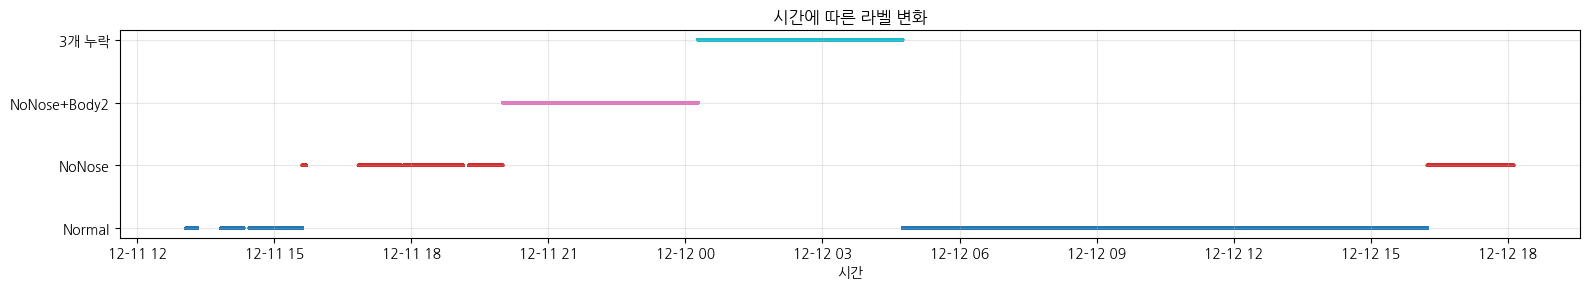

In [27]:
df_plot = df_all.set_index('_time')[['label']].copy()
df_plot['label_code'] = df_plot['label'].map(LABEL_MAP)

plt.figure(figsize=(16, 3))
plt.scatter(df_plot.index, df_plot['label_code'],
            c=df_plot['label_code'], cmap='tab10', s=1.5, alpha=0.5)
plt.yticks([0,1,2,3], ['Normal','NoNose','NoNose+Body2','3개 누락'])
plt.title('시간에 따른 라벨 변화')
plt.xlabel('시간')
plt.tight_layout()
plt.show()

## 6. 로봇별 관절 각도 분포

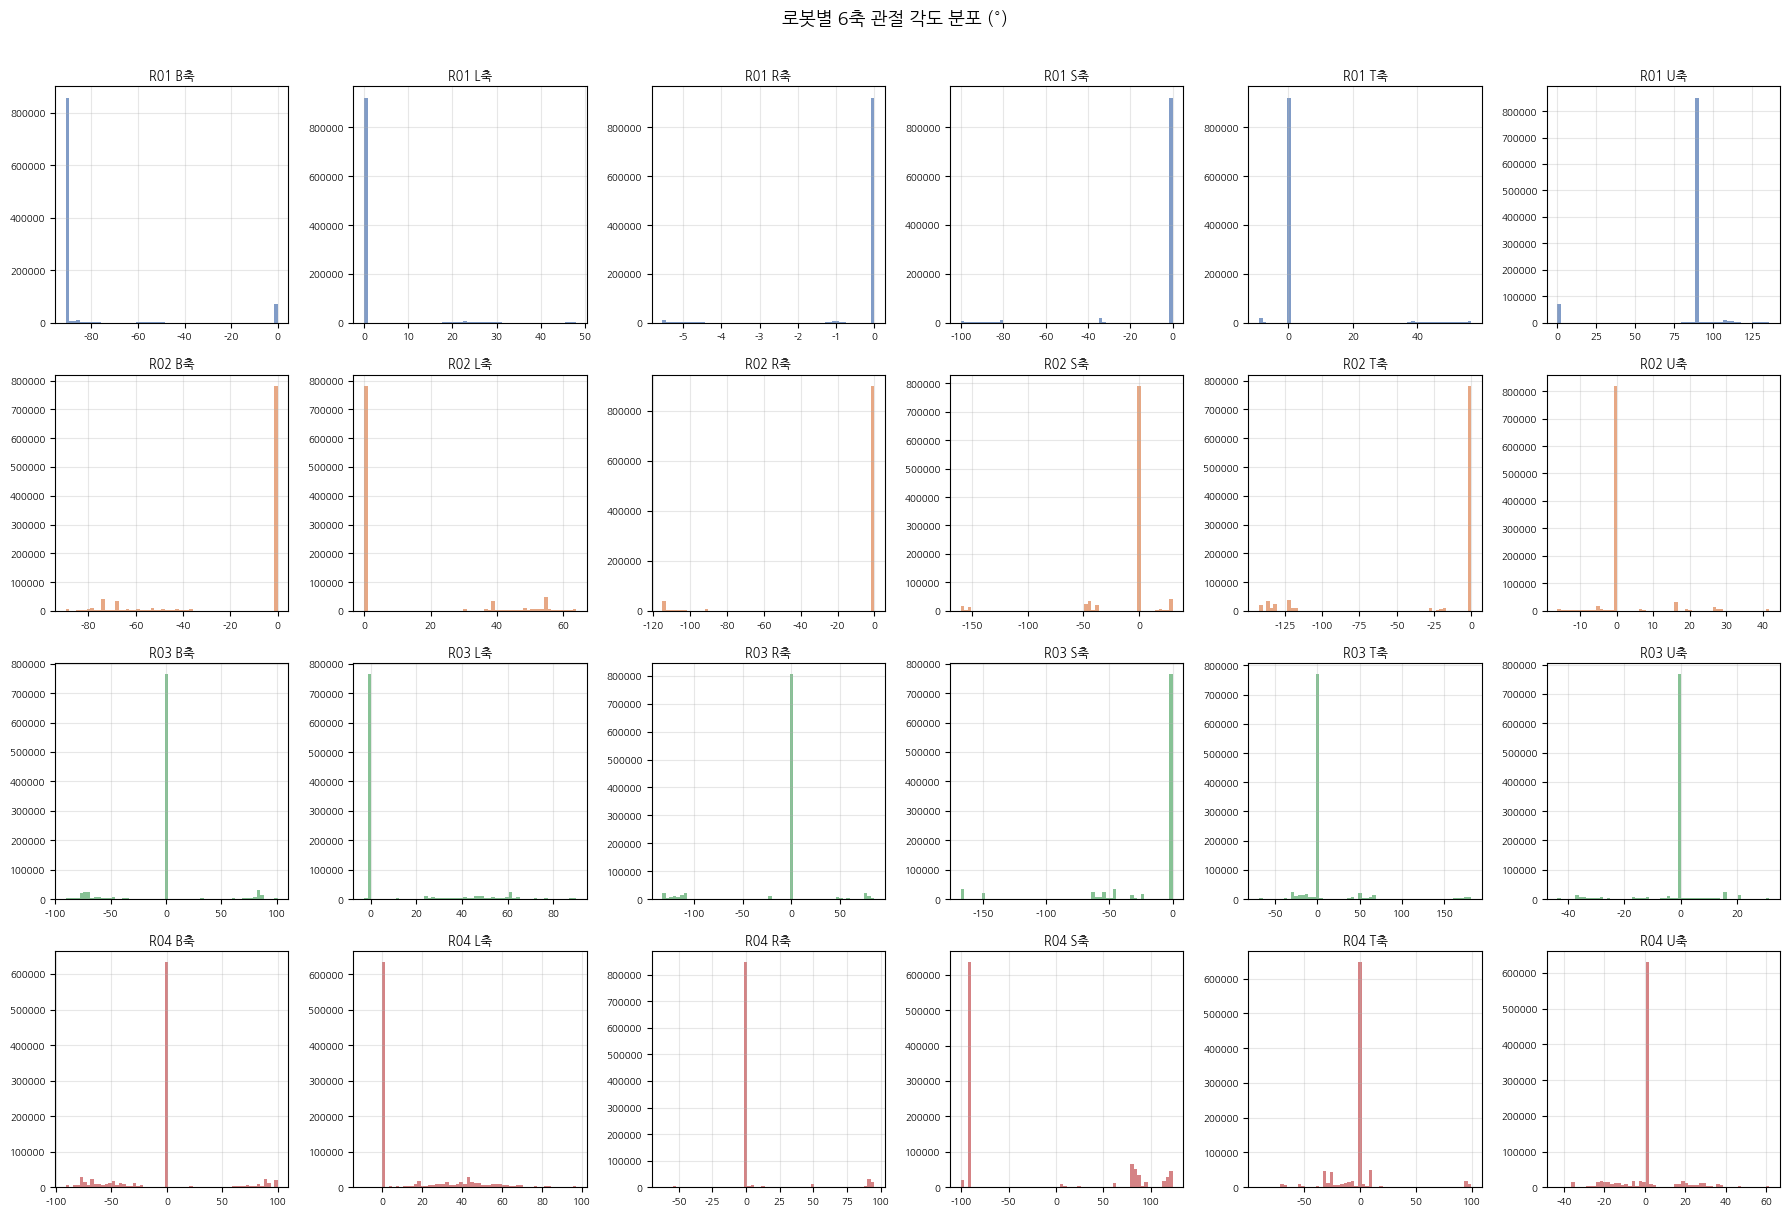

In [28]:
joint_axes = ['B','L','R','S','T','U']
fig, axes = plt.subplots(len(ROBOTS), len(joint_axes), figsize=(18, 12), sharex=False)
for ri, robot in enumerate(ROBOTS):
    for ji, joint in enumerate(joint_axes):
        col = f'M_{robot}_{joint}JointAngle_Degree'
        if col in df_all.columns:
            axes[ri, ji].hist(df_all[col].dropna(), bins=60,
                              color=COLORS[ri], alpha=0.7, edgecolor='none')
            axes[ri, ji].set_title(f'{robot} {joint}축', fontsize=9)
            axes[ri, ji].tick_params(labelsize=7)
fig.suptitle('로봇별 6축 관절 각도 분포 (°)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. 클래스별 그리퍼 부하 비교

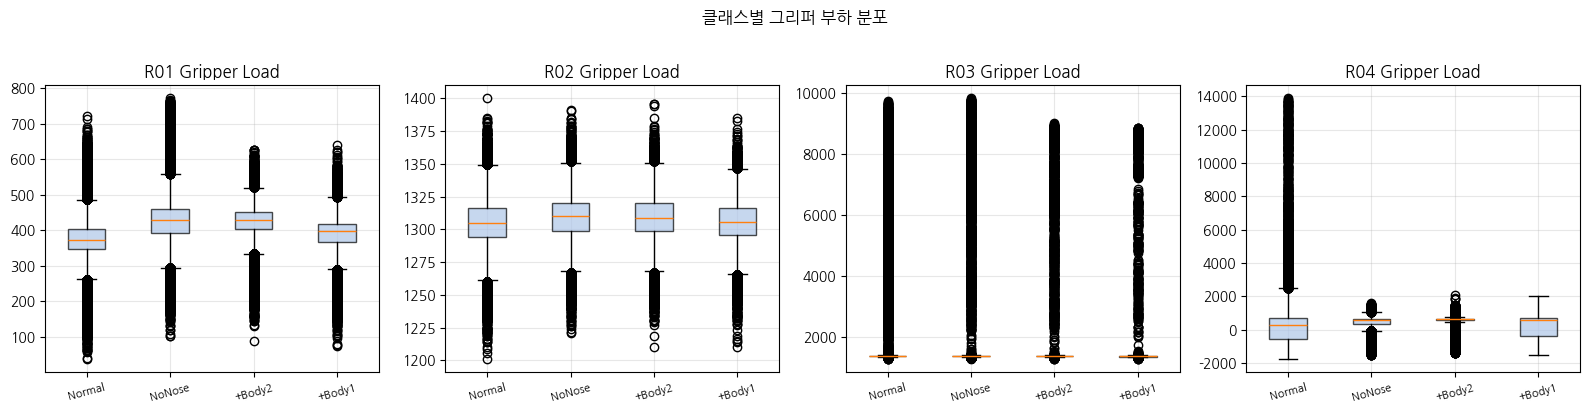

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, robot in enumerate(ROBOTS):
    col = f'I_{robot}_Gripper_Load'
    if col not in df_all.columns:
        continue
    data = [df_all.loc[df_all['label']==lbl, col].dropna() for lbl in LABEL_ORDER]
    axes[i].boxplot(data, labels=['Normal','NoNose','+Body2','+Body1'],
                    patch_artist=True, boxprops=dict(facecolor='#AEC6E8', alpha=0.7))
    axes[i].set_title(f'{robot} Gripper Load')
    axes[i].tick_params(axis='x', labelsize=8, rotation=15)
plt.suptitle('클래스별 그리퍼 부하 분포', y=1.02)
plt.tight_layout()
plt.show()

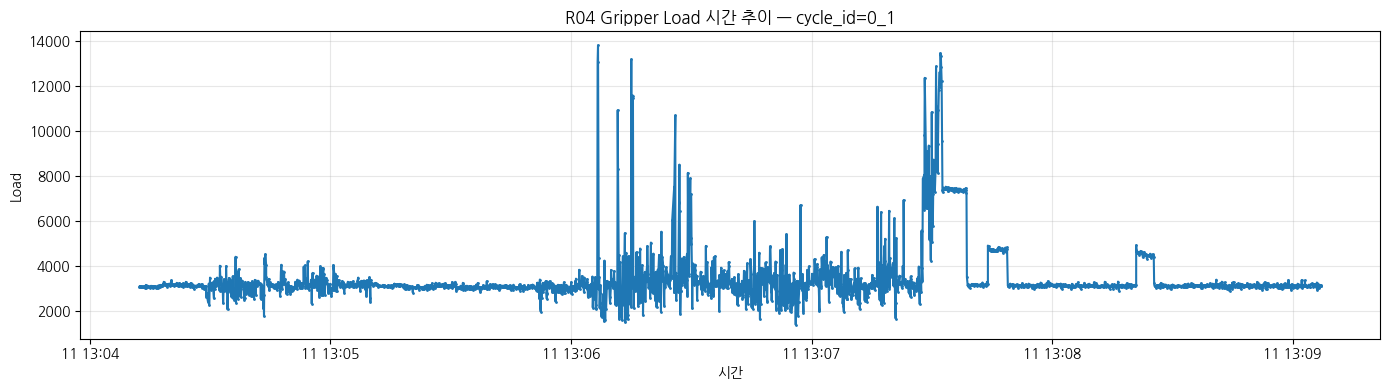

In [30]:
# ── R04 Gripper Load 사이클 단위 시간추이 확인 ──────────────────────
# [추가] 클래스별 분포(박스플롯)만으로는 "언제, 어떤 패턴으로" 부하가 변하는지 알 수 없으므로
# 사이클 하나를 골라 시간순으로 직접 확인한다.
# 관찰 결과(예시): 베이스라인 ~3,000 → 분해 구간(13:06~13:07:30) 1,500~14,000 격렬한 진동
#                → 이후 ~7,400 / ~4,800 / ~4,600 단계별 plateau로 복귀
# → 격렬한 진동 구간은 노이즈가 아니라 R04의 분해 동작(11~14단계) 자체의 신호로 해석된다.

sample_cid = df_all['cycle_id'].iloc[100]  # 필요시 다른 cycle_id로 교체
sample = df_all[df_all['cycle_id'] == sample_cid].sort_values('_time')

plt.figure(figsize=(14, 4))
plt.plot(sample['_time'], sample['I_R04_Gripper_Load'], marker='.', markersize=2)
plt.title(f'R04 Gripper Load 시간 추이 — cycle_id={sample_cid}')
plt.xlabel('시간'); plt.ylabel('Load')
plt.tight_layout()
plt.show()


### 7-1. 클래스별 · 로봇별 개별 Y-scale 시각화 (이식 — ZeroEscape_CycleAnalysis)

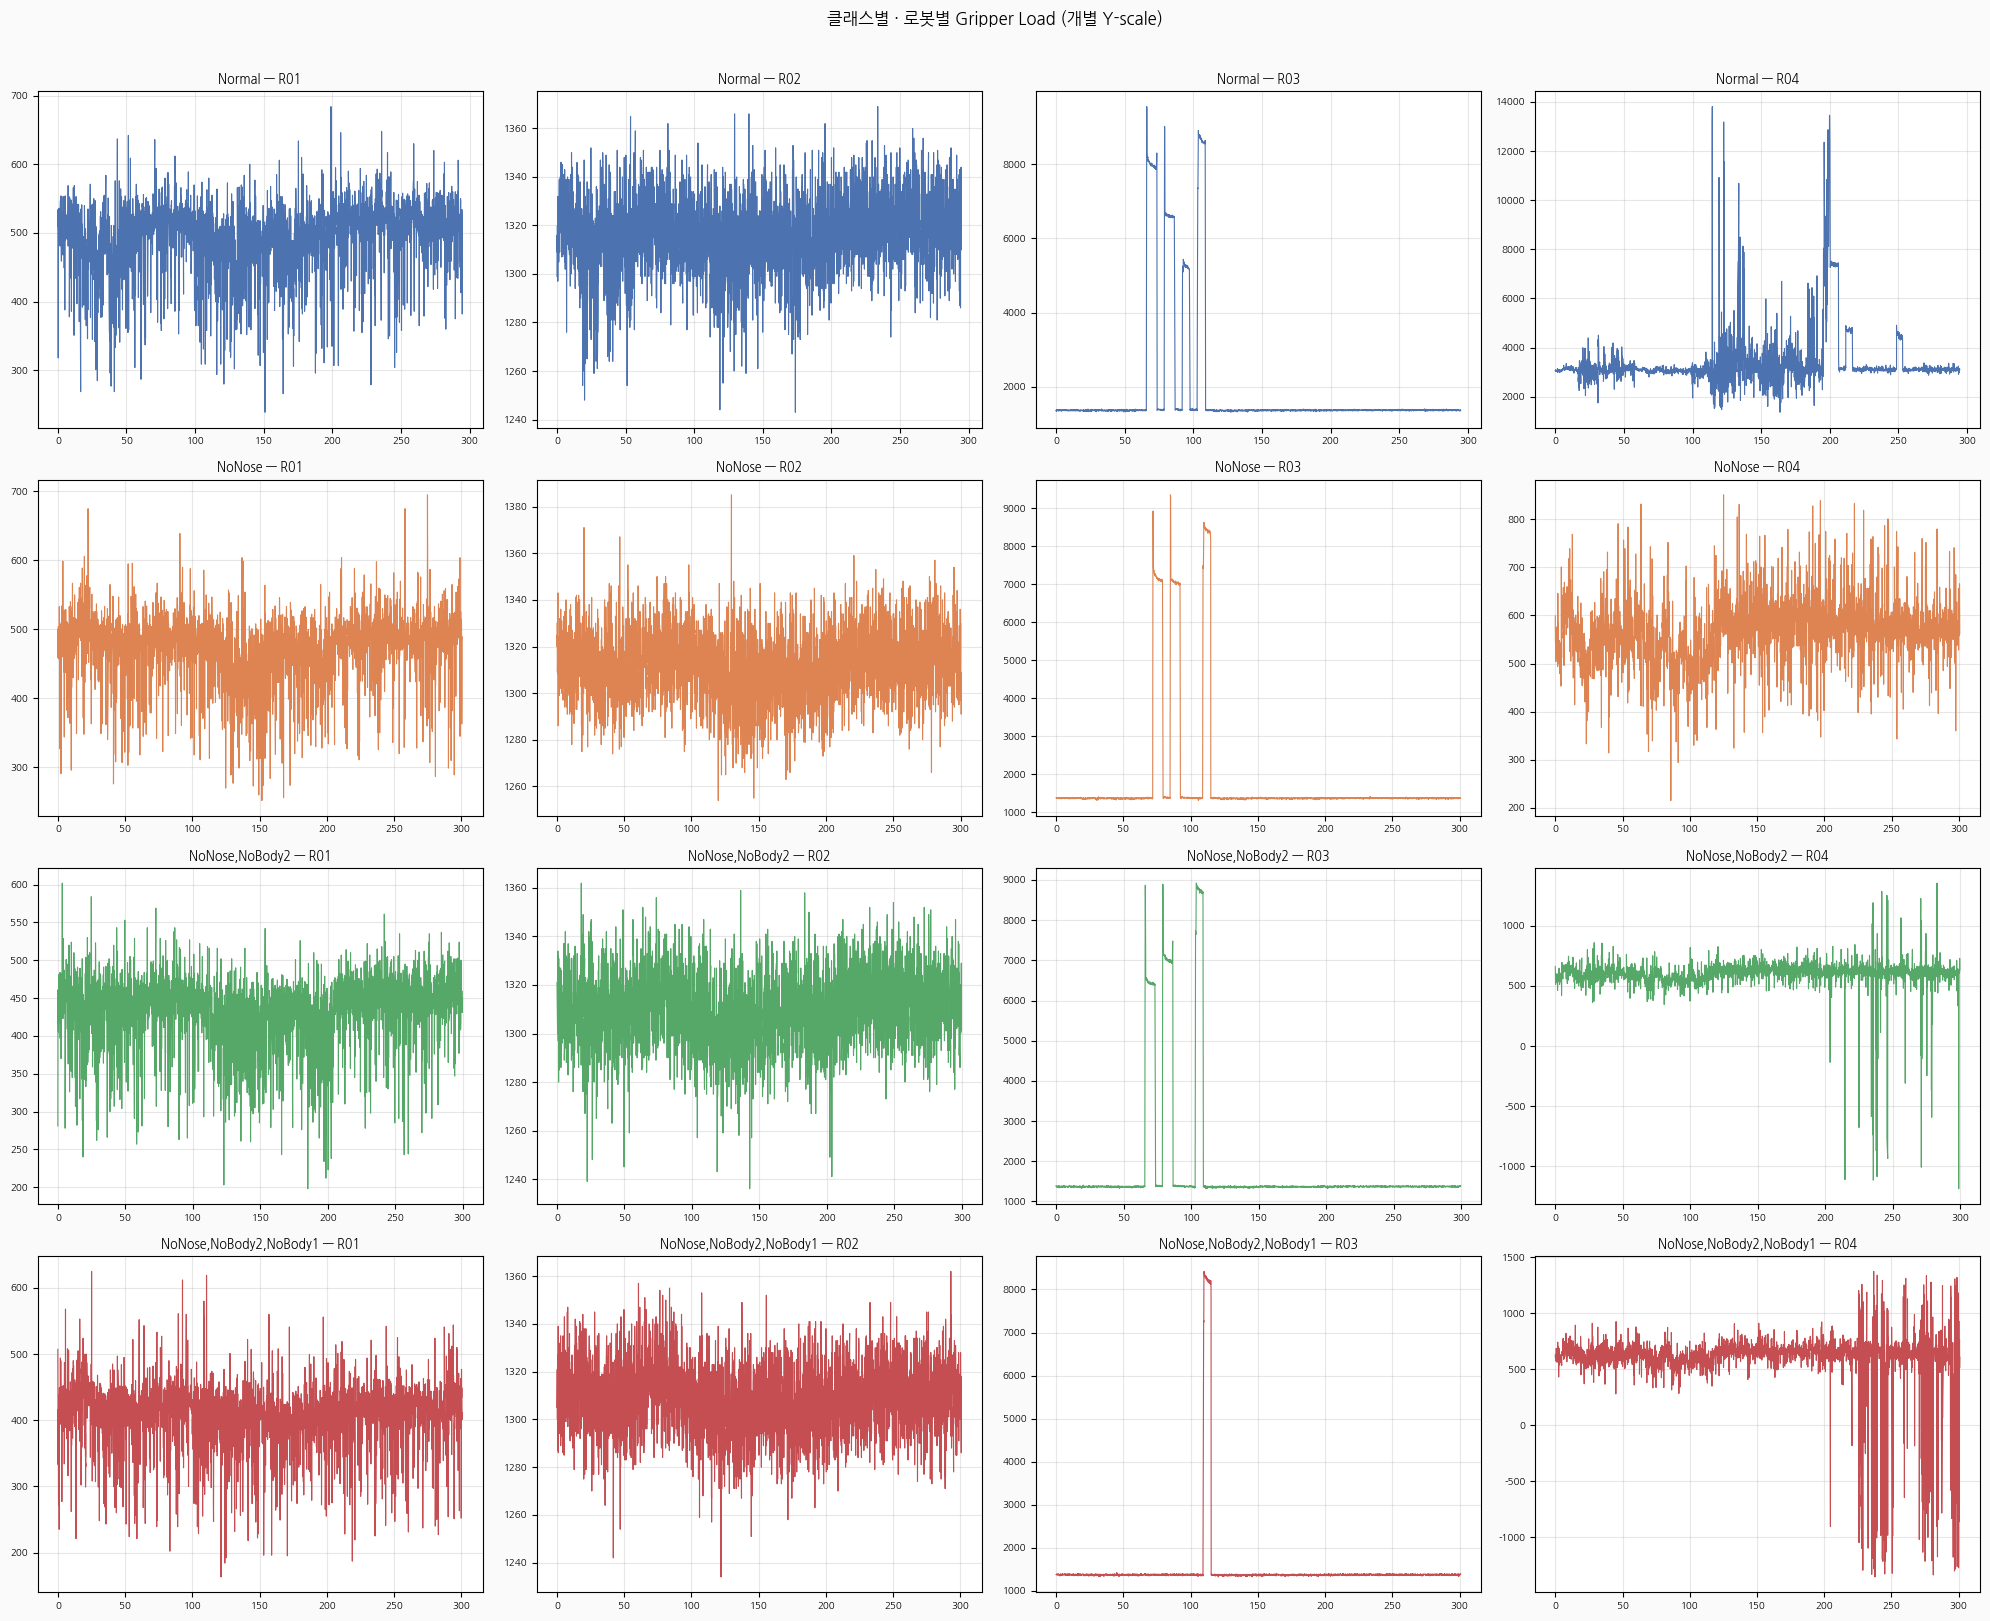

In [31]:
# ── R03의 하중 피크(~10,000)가 스케일을 압도해 R01/R02/R04 패턴이 안 보이는
#    문제를 해결하기 위해, 클래스별 대표 사이클 1개씩을 로봇마다 개별 Y축으로 그린다.
picks = {}
for lbl in LABEL_ORDER:
    cids = df_all.loc[df_all['label'] == lbl, 'cycle_id'].unique()
    if len(cids):
        picks[lbl] = cids[0]

fig, axes = plt.subplots(len(picks), len(ROBOTS),
                          figsize=(20, 4 * len(picks)), facecolor='#FAFAFA')
for row, lbl in enumerate(picks):
    cid = picks[lbl]
    sub = df_all[df_all['cycle_id'] == cid].sort_values('_time')
    elapsed = (sub['_time'] - sub['_time'].iloc[0]).dt.total_seconds()
    for col_idx, robot in enumerate(ROBOTS):
        ax = axes[row, col_idx] if len(picks) > 1 else axes[col_idx]
        load_col = f'I_{robot}_Gripper_Load'
        if load_col in sub.columns:
            ax.plot(elapsed, sub[load_col], lw=0.8, color=COLORS[LABEL_MAP[lbl]])
        ax.set_title(f'{lbl} — {robot}', fontsize=9)
        ax.tick_params(labelsize=7)

fig.suptitle('클래스별 · 로봇별 Gripper Load (개별 Y-scale)', y=1.01)
plt.tight_layout()
plt.show()

> ⚠️ **라벨 타이밍 주의사항**: 이 그림 역시 사이클의 최종 라벨을 그대로 색상에 사용했다.
> 각 사이클의 앞부분(아직 조립 중인 구간)까지 그 사이클의 최종 라벨 색으로 표시되므로,
> "이 순간에 정말 결함이 있었는지"보다는 "이 사이클이 결국 어떻게 끝났는지"를 보여주는
> 그림임을 감안해서 해석해야 한다. → **섹션 15 참고.**

## 8. VFD 온도 추이

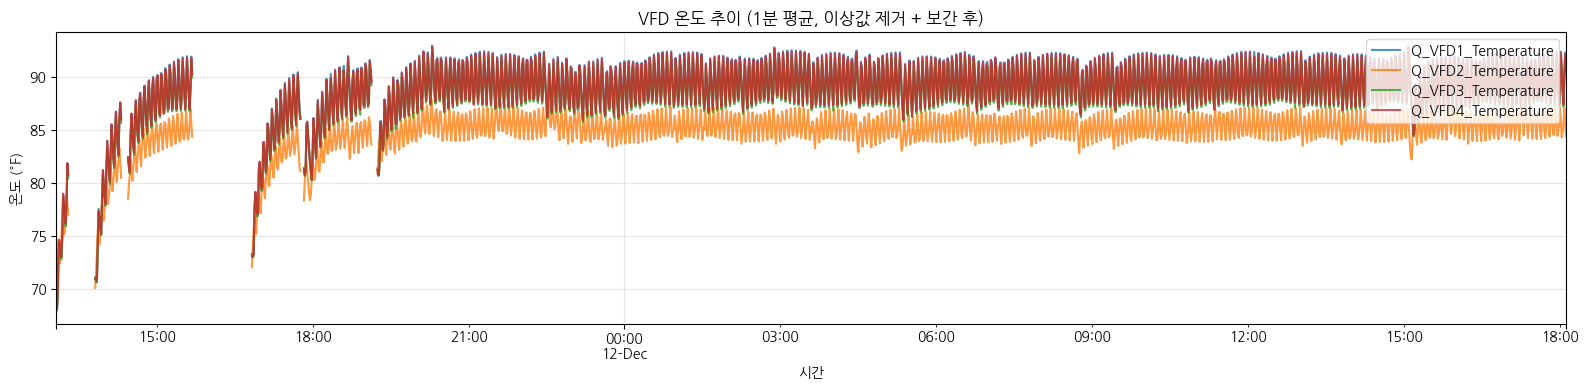

In [32]:
df_temp = df_all.set_index('_time')[vfd_cols].resample('1min').mean()
df_temp.plot(figsize=(16, 4), alpha=0.8)
plt.title('VFD 온도 추이 (1분 평균, 이상값 제거 + 보간 후)')  # [수정] 단위 라벨 정정
plt.ylabel('온도 (°F)')
plt.xlabel('시간')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 9. 상관관계 히트맵

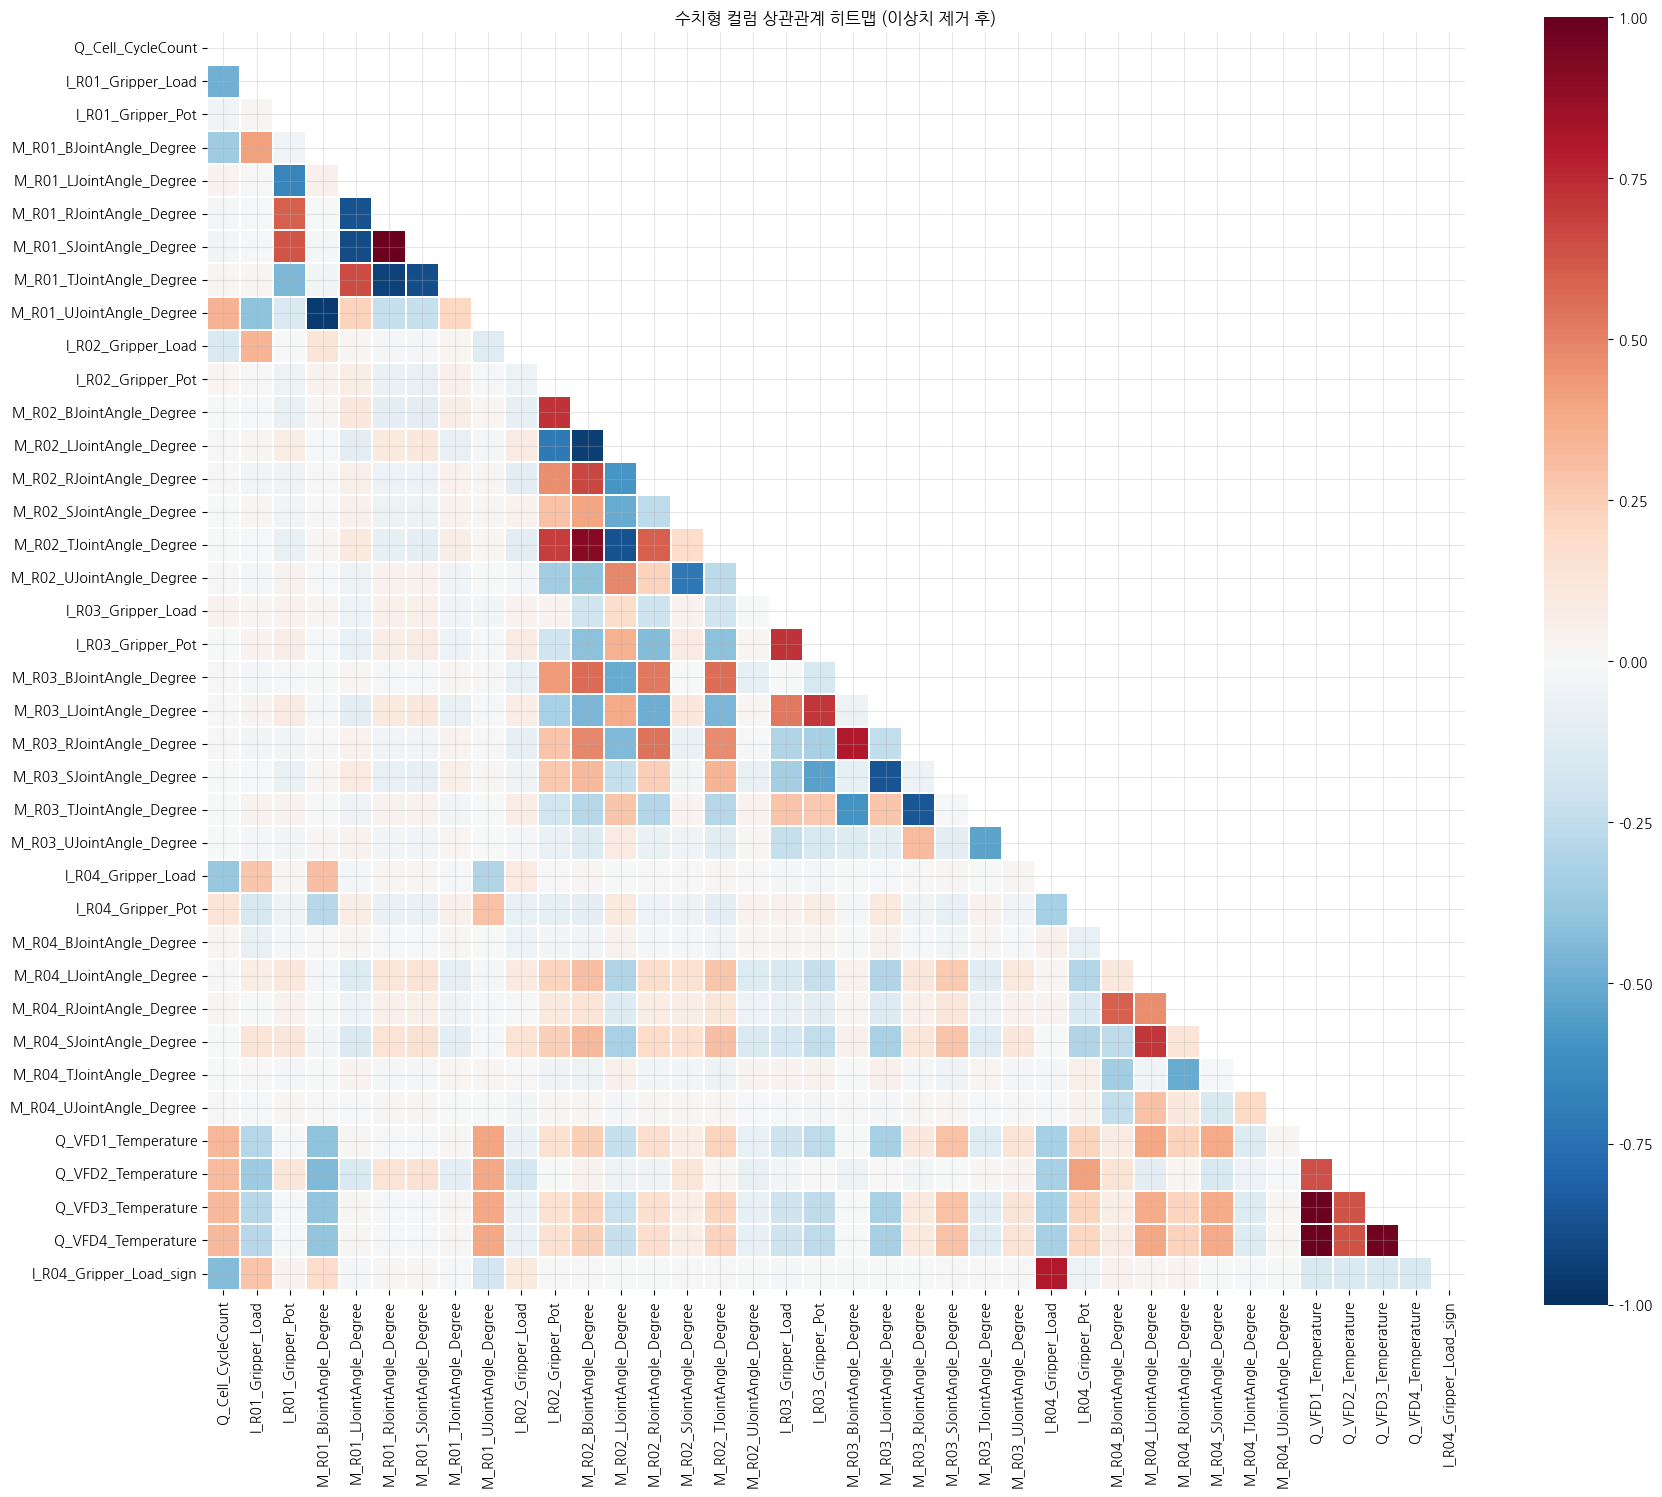

In [33]:
sample = df_all[num_cols].sample(n=min(50_000, len(df_all)), random_state=42)
corr   = sample.corr()

plt.figure(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, annot=False, square=True)
plt.title('수치형 컬럼 상관관계 히트맵 (이상치 제거 후)')
plt.tight_layout()
plt.show()

## 10. 클래스 인코딩 및 저장

In [34]:
df_all['label_code'] = df_all['label'].map(LABEL_MAP)
print('라벨 인코딩:')
print(df_all[['label','label_code']].value_counts().sort_index())

df_all.to_csv(DATA_DIR / 'FFCell_merged.csv', index=False)
print(f'\n저장 완료: FFCell_merged.csv  |  shape: {df_all.shape}')

라벨 인코딩:
label                   label_code
NoNose                  1             177644
NoNose,NoBody2          2             153851
NoNose,NoBody2,NoBody1  3             161166
Normal                  0             481976
Name: count, dtype: int64

저장 완료: FFCell_merged.csv  |  shape: (974637, 63)


## 11. 사이클 단위 집계

In [35]:
# 사이클 수 최종 확인
print(f'고유 사이클 수: {df_all["cycle_id"].nunique()}  (목표: 325)')
cycle_sizes = df_all.groupby('cycle_id').size()
print(f'사이클별 행 수  min:{cycle_sizes.min()}  max:{cycle_sizes.max()}  median:{cycle_sizes.median():.0f}')

고유 사이클 수: 325  (목표: 325)
사이클별 행 수  min:2872  max:4459  median:2950


In [36]:
# cycle_id 기준 집계 (mean/std/max/min)
cycle_feat = df_all.groupby('cycle_id')[num_cols].agg(['mean','std','max','min'])
cycle_feat.columns = ['_'.join(col) for col in cycle_feat.columns]

# 라벨 집계 — max() 사용 이유:
# 사이클 내 1건의 결함도 해당 사이클을 결함으로 분류 (재현율 중심 보수적 설계)
cycle_feat['label'] = df_all.groupby('cycle_id')['label'].max()

print(f'집계된 사이클 수: {len(cycle_feat)}  ✅')
print()
print(cycle_feat['label'].value_counts())

집계된 사이클 수: 325  ✅

label
Normal                    162
NoNose                     59
NoNose,NoBody2,NoBody1     53
NoNose,NoBody2             51
Name: count, dtype: int64


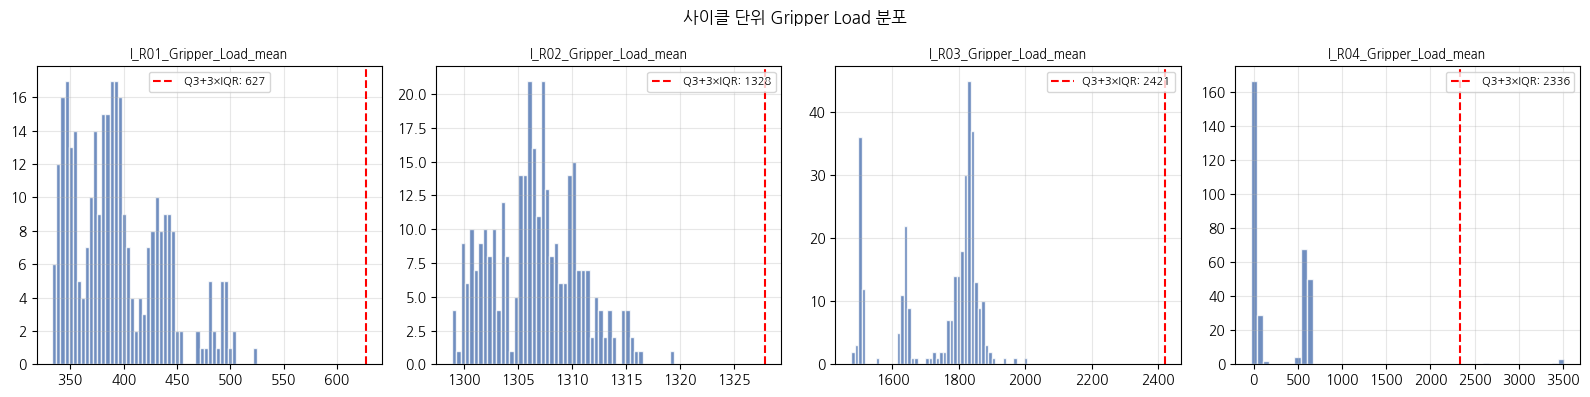

In [37]:
# 사이클 단위 Gripper Load 분포 + IQR 임계값 시각화
gripper_mean_cols = [c for c in cycle_feat.columns if 'Gripper_Load_mean' in c]
if gripper_mean_cols:
    fig, axes = plt.subplots(1, len(gripper_mean_cols), figsize=(16, 4))
    if len(gripper_mean_cols) == 1: axes = [axes]
    for i, col in enumerate(gripper_mean_cols):
        axes[i].hist(cycle_feat[col].dropna(), bins=50,
                     color='#4C72B0', edgecolor='white', alpha=0.8)
        q3    = cycle_feat[col].quantile(0.75)
        upper = q3 + 3*(q3 - cycle_feat[col].quantile(0.25))
        axes[i].axvline(upper, color='red', linestyle='--', lw=1.5,
                        label=f'Q3+3×IQR: {upper:.0f}')
        axes[i].set_title(col, fontsize=9)
        axes[i].legend(fontsize=8)
    plt.suptitle('사이클 단위 Gripper Load 분포', fontsize=12)
    plt.tight_layout()
    plt.show()

---
# PART 3. 가설검정 — 1차 피처 선별

EDA에서 집계한 121개 피처에 Kruskal-Wallis(+Dunn's test)를 돌려 "진짜 의미 있는 변수"를 통계로 골라낸다. **이 단계에서 나오는 `sig_feat_cols`가 PART 4의 최종 피처셋을 만드는 재료로 그대로 쓰이기 때문에, 파생변수 생성보다 먼저 와야 한다.**
---

## 12. 가설검정 (Kruskal-Wallis)

- **H₀**: 4개 클래스 간 분포 차이 없음
- **기각 기준**: p-value < 0.05

### 12-0. 정규성·등분산성 확인 (비모수 검정 선택 근거)

튜터 피드백 반영: Kruskal-Wallis(비모수 검정)를 선택한 근거를 사전에 확인하지 않았다는 지적을 반영해, Shapiro-Wilk(정규성) · Levene(등분산성) 검정으로 비모수 검정 선택이 타당한지 사후 확인한다.


In [38]:
from scipy.stats import shapiro, levene

feat_cols_check = [c for c in cycle_feat.columns if c != 'label']
groups_check    = [cycle_feat[cycle_feat['label'] == lbl] for lbl in LABEL_ORDER]

normality_violations, normality_total = 0, 0
variance_violations, variance_total = 0, 0

for col in feat_cols_check:
    samples = [g[col].dropna() for g in groups_check]
    if any(len(s) < 3 for s in samples):
        continue
    for s in samples:
        s_test = s.sample(5000, random_state=42) if len(s) > 5000 else s
        try:
            _, p_norm = shapiro(s_test)
            normality_total += 1
            if p_norm < 0.05:
                normality_violations += 1
        except Exception:
            pass
    try:
        _, p_var = levene(*samples)
        variance_total += 1
        if p_var < 0.05:
            variance_violations += 1
    except Exception:
        pass

print(f'정규성 위반(Shapiro-Wilk p<0.05): {normality_violations}/{normality_total}건 '
      f'({normality_violations/max(normality_total,1):.1%})')
print(f'등분산성 위반(Levene p<0.05)   : {variance_violations}/{variance_total}개 피처 '
      f'({variance_violations/max(variance_total,1):.1%})')
print()
print('두 위반 비율이 모두 높게 나온다면, ANOVA 대신 Kruskal-Wallis(비모수) 선택이 타당함을 뜻한다.')


정규성 위반(Shapiro-Wilk p<0.05): 423/608건 (69.6%)
등분산성 위반(Levene p<0.05)   : 58/152개 피처 (38.2%)

두 위반 비율이 모두 높게 나온다면, ANOVA 대신 Kruskal-Wallis(비모수) 선택이 타당함을 뜻한다.


In [39]:
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

feat_cols = [c for c in cycle_feat.columns if c != 'label']
groups    = [cycle_feat[cycle_feat['label'] == lbl] for lbl in LABEL_ORDER]

results = []
for col in feat_cols:
    samples = [g[col].dropna() for g in groups]
    if any(len(s) < 2 for s in samples):
        continue
    try:
        stat, p = kruskal(*samples)
        k = len(samples)
        n = sum(len(s) for s in samples)
        # 효과크기 (epsilon-squared) — 튜터 피드백: 효과크기 미보고 문제 반영
        epsilon_sq = (stat - k + 1) / (n - k) if n > k else np.nan
        results.append({'feature': col, 'stat': stat, 'p_value': p, 'epsilon_sq': epsilon_sq})
    except Exception:
        pass

result_df = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)
result_df['significant_raw'] = result_df['p_value'] < 0.05

# ── 다중비교 보정 (FDR, Benjamini-Hochberg) — 튜터 피드백: 121회 검정을 보정 없이 판정한 문제 반영
reject, p_fdr, _, _ = multipletests(result_df['p_value'], alpha=0.05, method='fdr_bh')
result_df['p_value_fdr'] = p_fdr
result_df['significant_fdr'] = reject

print(f'유의미한 피처 수 (raw p<0.05)  : {result_df["significant_raw"].sum()} / {len(result_df)}')
print(f'유의미한 피처 수 (FDR 보정 후) : {result_df["significant_fdr"].sum()} / {len(result_df)}')
print(f'FDR 보정으로 탈락한 피처 수    : {result_df["significant_raw"].sum() - result_df["significant_fdr"].sum()}')
print()
print(result_df.head(20).to_string(index=False))


유의미한 피처 수 (raw p<0.05)  : 110 / 121
유의미한 피처 수 (FDR 보정 후) : 109 / 121
FDR 보정으로 탈락한 피처 수    : 1

                     feature     stat  p_value  epsilon_sq  significant_raw  p_value_fdr  significant_fdr
     I_R03_Gripper_Load_mean 256.4952   0.0000      0.7897             True       0.0000             True
      I_R02_Gripper_Pot_mean 223.2214   0.0000      0.6860             True       0.0000             True
       I_R02_Gripper_Pot_std 221.9482   0.0000      0.6821             True       0.0000             True
       I_R02_Gripper_Pot_min 219.8687   0.0000      0.6756             True       0.0000             True
      I_R03_Gripper_Load_std 213.7731   0.0000      0.6566             True       0.0000             True
       I_R04_Gripper_Pot_std 203.4337   0.0000      0.6244             True       0.0000             True
      I_R04_Gripper_Pot_mean 180.2340   0.0000      0.5521             True       0.0000             True
       I_R03_Gripper_Pot_max 170.2470   0.0000      0.521

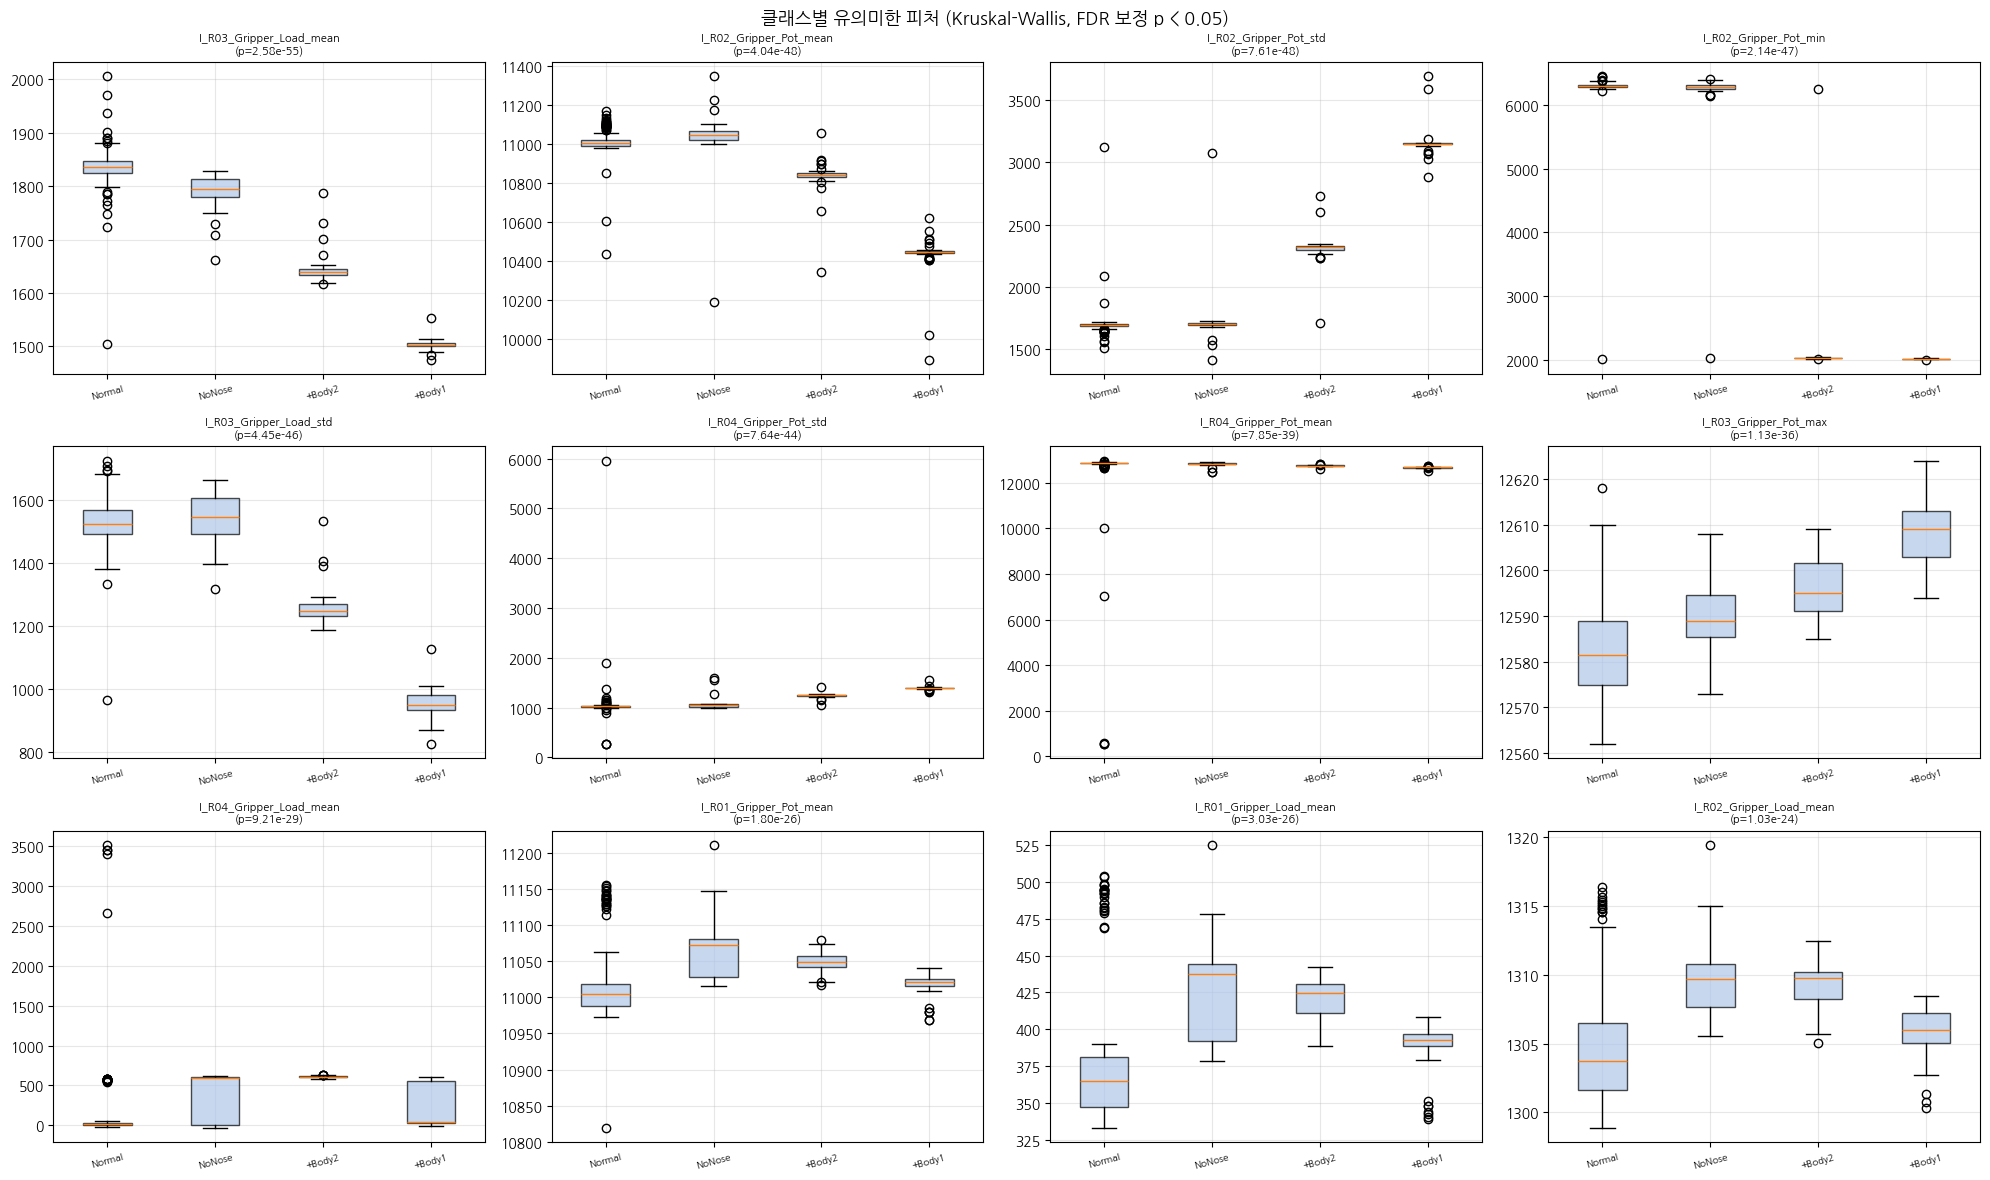

In [40]:
top_feats = result_df[result_df['significant_fdr']].head(12)['feature'].tolist()
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for i, feat in enumerate(top_feats):
    data = [cycle_feat.loc[cycle_feat['label']==lbl, feat].dropna() for lbl in LABEL_ORDER]
    axes[i].boxplot(data, labels=['Normal','NoNose','+Body2','+Body1'],
                    patch_artist=True, boxprops=dict(facecolor='#AEC6E8', alpha=0.7))
    p_val = result_df.loc[result_df['feature']==feat, 'p_value'].values[0]
    axes[i].set_title(f'{feat}\n(p={p_val:.2e})', fontsize=8)
    axes[i].tick_params(axis='x', labelsize=7, rotation=15)
plt.suptitle('클래스별 유의미한 피처 (Kruskal-Wallis, FDR 보정 p < 0.05)', fontsize=13)
plt.tight_layout()
plt.show()

In [41]:
# ── [정리] 유의미 피처 확정 (다중비교 보정 반영판) ────────────────────────────
result_df_sig = result_df[result_df['significant_fdr']].copy()
print(f'유의미 피처(FDR 보정, p<0.05): {len(result_df_sig)}개 / 전체 {len(result_df)}개')
print(f'(참고) 보정 전 raw 기준으로는 {result_df["significant_raw"].sum()}개였음 — '
      f'다중비교 보정으로 {result_df["significant_raw"].sum() - len(result_df_sig)}개 추가 탈락')
# 효과크기(epsilon_sq) 내림차순 정렬 — 통계적 유의미함과 실질적 중요도를 함께 반영
sig_feat_cols = result_df_sig.sort_values('epsilon_sq', ascending=False)['feature'].tolist()


유의미 피처(FDR 보정, p<0.05): 109개 / 전체 121개
(참고) 보정 전 raw 기준으로는 110개였음 — 다중비교 보정으로 1개 추가 탈락


### 12-1. 사후검정 (Dunn's test) — 어느 클래스 쌍이 구체적으로 다른가?

튜터 피드백 반영: Kruskal-Wallis는 '4개 클래스 중 최소 하나는 다르다'는 전역 검정 결과만 알려준다. 구체적으로 어느 클래스 쌍끼리 다른지 확인하기 위해, 효과크기(epsilon_sq) 상위 15개 피처에 대해 Dunn's test(Bonferroni 보정)를 수행한다.


In [42]:
!pip install scikit-posthocs --quiet


In [43]:
import scikit_posthocs as sp

top_effect_feats = result_df_sig.sort_values('epsilon_sq', ascending=False).head(15)['feature'].tolist()

dunn_results = {}
for feat in top_effect_feats:
    sub = cycle_feat[['label', feat]].dropna()
    dunn_results[feat] = sp.posthoc_dunn(sub, val_col=feat, group_col='label', p_adjust='bonferroni')

# 상위 3개 피처는 표 자체를 출력
for feat in top_effect_feats[:3]:
    print(f'\n=== {feat} (Dunn test, Bonferroni 보정) ===')
    print(dunn_results[feat].round(4))

# 클래스 쌍별로 상위 15개 피처 중 몇 개에서 유의미한 차이가 나는지 요약
pair_sig_count = {}
for feat, dunn in dunn_results.items():
    labels_ = dunn.columns.tolist()
    for i in range(len(labels_)):
        for j in range(i+1, len(labels_)):
            pair = tuple(sorted([labels_[i], labels_[j]]))
            if dunn.iloc[i, j] < 0.05:
                pair_sig_count[pair] = pair_sig_count.get(pair, 0) + 1

print('\n[클래스 쌍별 유의미한 피처 개수] (효과크기 상위 15개 피처 기준)')
for pair, cnt in sorted(pair_sig_count.items(), key=lambda x: -x[1]):
    print(f'  {pair[0]} vs {pair[1]}: {cnt}/{len(top_effect_feats)}개 피처에서 유의미')



=== I_R03_Gripper_Load_mean (Dunn test, Bonferroni 보정) ===
                        NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
NoNose                  1.0000          0.0011                  0.0000  0.0000
NoNose,NoBody2          0.0011          1.0000                  0.0229  0.0000
NoNose,NoBody2,NoBody1  0.0000          0.0229                  1.0000  0.0000
Normal                  0.0000          0.0000                  0.0000  1.0000

=== I_R02_Gripper_Pot_mean (Dunn test, Bonferroni 보정) ===
                        NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
NoNose                  1.0000          0.0000                  0.0000  0.0001
NoNose,NoBody2          0.0000          1.0000                  0.0181  0.0000
NoNose,NoBody2,NoBody1  0.0000          0.0181                  1.0000  0.0000
Normal                  0.0001          0.0000                  0.0000  1.0000

=== I_R02_Gripper_Pot_std (Dunn test, Bonferroni 보정) ===
                        NoNose  N

In [44]:
# ── 이번 섹션들(13~20)에서 필요한 통계·신호처리 함수 임포트 ─────────────────
from scipy.stats import mannwhitneyu, linregress
from scipy.signal import find_peaks

In [45]:
# ── Mann-Whitney U 효과크기 (rank-biserial correlation) ─────────────────────
# 튜터 피드백: 이후 2클래스 비교(R03/R04 신호, Lag 등)에서도 p-value만 보고하고
# 효과크기가 없었던 문제를 반영해, 재사용 가능한 헬퍼 함수를 추가한다.
def rank_biserial(u_stat, n1, n2):
    """Mann-Whitney U 통계량으로부터 rank-biserial correlation 효과크기 계산 (-1~1)."""
    return 1 - (2 * u_stat) / (n1 * n2)


---
# PART 4. 파생변수 생성 및 신호 검증

공정 구조(21단계 SOP, State 경계, 딥그랩 순번)를 확정하고, 그 위에서 Nose/Tail 등 핵심 신호를 그래프+통계검정으로 검증하며 새로운 파생 피처(Window 모양 피처, R03 Nose 신호 등)를 만든다. PART 3의 유의미 피처 + 여기서 새로 만든 피처를 합쳐 최종 피처셋을 확정한다.
---

## 13. 21단계 공정 매핑 — 실측 State 경계 반영 (수정판)

기존에는 각 구간을 "관찰 기반 근사치"(예: 38초를 4등분)로 나눴다. 이번 재구성에서는
팀원이 실측한 State 경계 시점(표준편차 ±0.1~0.4초로 매우 일관적)을 공식 기준으로 채택한다.
핵심 정정: **R04의 유의미한 동작은 192초가 아니라 컨베이어 이송이 끝나는 206.3초에 시작한다.**

In [46]:
# ── 사이클 내 경과 시간(elapsed_s) 계산 ────────────────────────────
df_all['elapsed_s'] = df_all.groupby('cycle_id')['_time'] \
    .transform(lambda s: (s - s.min()).dt.total_seconds())

# ── 실측 State 경계표 (팀원 진행상황 공유 문서 Table 5 기준) ─────────────
STATE_BOUNDARIES = {
    'State1_3_R01투입':      (0.0,   25.0),
    'State4_7_R02조립':      (25.0,  49.3),   # R03 S-Joint 시작 49.3±0.1초
    'State8_R03조립':        (49.3,  113.0),  # ★ 노즈콘 파지창 93~100초 포함
    'State9_10_컨베이어이송': (113.0, 206.3),  # Stopper3 ON 138.1±0.8초
    'State11_R04노즈분해':    (206.3, 216.0),  # ★ R04 딥그랩 2번째 진입 206.3±0.3초
    'State12_14_R04분해잔여': (216.0, 265.0),  # Body2·Body1·Tail (세부경계 미제공, 균등3등분 근사)
    'State15_18_R04되돌림':   (265.0, 285.0),
    'State19_21_R04복귀':     (285.0, 294.2),  # R04 S-Joint 종료 294.2±0.4초
}

print('[실측 State 경계표]')
for name, (s, e) in STATE_BOUNDARIES.items():
    print(f'  {name:24s}: {s:6.1f} ~ {e:6.1f}초  ({e-s:5.1f}초)')

NOSE_WINDOW_START, NOSE_WINDOW_END = 93.0, 100.0   # ★ R03 노즈콘 파지창 (본 노트북의 핵심 신호)
R04_NOSE_START, R04_NOSE_END = STATE_BOUNDARIES['State11_R04노즈분해']

_s, _e = STATE_BOUNDARIES['State12_14_R04분해잔여']
_step = (_e - _s) / 3
R04_SUBPHASES = {
    'Nose_제거':  STATE_BOUNDARIES['State11_R04노즈분해'],
    'Body2_제거': (_s + 0 * _step, _s + 1 * _step),
    'Body1_제거': (_s + 1 * _step, _s + 2 * _step),
    'Tail_제거':  (_s + 2 * _step, _s + 3 * _step),
}
part_to_defect_col = {
    'Nose_제거': 'defect_NoNose', 'Body2_제거': 'defect_NoBody2', 'Body1_제거': 'defect_NoBody1',
}
print('\n[R04 분해 하위구간, 수정판]')
for part, (s, e) in R04_SUBPHASES.items():
    print(f'  {part:12s}: {s:6.1f} ~ {e:6.1f}초')

cycle_defect_flags = df_all.groupby('cycle_id')[['defect_NoNose', 'defect_NoBody2', 'defect_NoBody1']].max()
label_by_cycle = df_all.groupby('cycle_id')['label'].first()


[실측 State 경계표]
  State1_3_R01투입          :    0.0 ~   25.0초  ( 25.0초)
  State4_7_R02조립          :   25.0 ~   49.3초  ( 24.3초)
  State8_R03조립            :   49.3 ~  113.0초  ( 63.7초)
  State9_10_컨베이어이송        :  113.0 ~  206.3초  ( 93.3초)
  State11_R04노즈분해         :  206.3 ~  216.0초  (  9.7초)
  State12_14_R04분해잔여      :  216.0 ~  265.0초  ( 49.0초)
  State15_18_R04되돌림       :  265.0 ~  285.0초  ( 20.0초)
  State19_21_R04복귀        :  285.0 ~  294.2초  (  9.2초)

[R04 분해 하위구간, 수정판]
  Nose_제거     :  206.3 ~  216.0초
  Body2_제거    :  216.0 ~  232.3초
  Body1_제거    :  232.3 ~  248.7초
  Tail_제거     :  248.7 ~  265.0초


## 14. 사이클 수 최종 확정 — 두 단계 QA 반영 (v80 정정)

사이클 수는 서로 다른 두 단계의 품질 검사를 거쳐 확정된다. 두 숫자(325개, 323개)가
서로 모순되는 것이 아니라, **검사 기준이 다른 두 단계**라는 점을 명확히 한다.

| 단계 | 검사 기준 | 통과 개수 |
|------|-----------|----------|
| ① 원본 스펙 | `Q_Cell_CycleCount` 리셋 기준 327개 중, 사이클 **경계(시작~끝)** 가 온전한지만 확인 | 325개 |
| ② 추가 검증(본 절) | ①을 통과한 325개 중, **R04 신호가 정상 범위인지**까지 확인 | 323개 |

(참고: 세션0 3개(`0_1`,`0_2`,`0_3`)는 같은 근거로 더 이후 단계인 19장 최종 피처셋에서
별도로 제외되어 최종 320개가 된다 — `'0_'` 프리픽스로 걸러내는 기존 로직 그대로 유지.)

**[v80 정정]** 기존 문서는 "`1_1`, `1_2`는 R01·R04 센서 값이 비어있어서 제외한다"고 서술했는데,
원본 CSV로 독립 재검증한 결과 이 서술은 **사실이 아닌 것으로 확인됐다** — 결측률 0%, 신호 존재
비율 99.97~100%로 오히려 신호가 항상 있었다. 대신 재검증에서 다음 근거가 새로 확인됐다.

1. **R04 그리퍼 부하(`I_R04_Gripper_Load`)의 사이클별 표준편차**가 전체 327개 사이클 중
   `1_1`(1590), `1_2`(1919), `0_1`(1344), `0_2`(1464), `0_3`(1655)로 **상위 5개를 압도적으로
   차지**한다 — 6위(`5_260`, 787)와 뚜렷한 격차가 있어 임계값(예: 1000)으로 깔끔하게 분리된다.
2. `1_2`는 사이클 도중 **안전 도어(`I_SafetyDoor1_Status`)가 열림→닫힘으로 기록**되어 있어
   작업자 개입(수동 조작·점검)의 물리적 흔적이 남아있다.
3. 이 5개 사이클은 정확히 **데이터 수집 시작 직후(세션0 전체 3개 + 세션1 초반 2개)**에
   몰려 있다 — "라인 초기 워밍업/시운전" 서사와 시간적으로 정확히 일치한다.

즉 **제외 결정 자체(`1_1`,`1_2` 제외 → 323개)는 근거·재현성 모두 확인되어 유지**하되, 그 이유를
"센서 값 비어있음"에서 "R04 부하 변동성 이상 + 안전 도어 개입 흔적 + 수집 초반 위치"로
정정한다. 아래 검증 셀도 이 기준으로 다시 작성했다.

**보고서/문서 표기 권장 문구**: "원본 스펙 기준 325개 완전 사이클 중, 데이터 수집 초반
워밍업으로 판단되는 2개(`1_1`,`1_2` — R04 부하 변동성이 정상 사이클 대비 10배 이상)를 추가로
제외해 323개를 확정하고, 이후 세션0(동일 근거의 3개)까지 제외한 320개를 최종 분석에 사용함."


In [47]:
# ── 불완전 사이클(1_1, 1_2) 재확인 및 제거 (v80 정정 — 검증 기준 교체) ──────────
# [v80] 기존 'R01/R04 전부 0/NaN' 체크는 원본 CSV 재검증에서 사실이 아닌 것으로 확인됐다
# (14장 참고). 대신 'R04 그리퍼 부하 변동성이 정상 사이클 대비 압도적으로 큰가'를 검증 기준으로
# 교체한다 — 이 기준은 원본 CSV로 재현했을 때 1_1·1_2·세션0(0_1~0_3) 5개가 전체 327개 중
# 상위 5개를 정확히 차지하고 6위와 뚜렷한 격차가 있음을 확인했다.
CANDIDATE_INCOMPLETE = ['1_1', '1_2']

r04_std_all = df_all.groupby('cycle_id')['I_R04_Gripper_Load'].std()
print('[R04 그리퍼 부하 표준편차 — 전체 사이클 중 상위 10개]')
print(r04_std_all.sort_values(ascending=False).head(10))
print(f'\n(참고) 6위 이하와 상위 5개 사이의 격차로 이상 사이클을 구분한다 — 1_1, 1_2가 여기 포함되는지 확인.')

for cid in CANDIDATE_INCOMPLETE:
    if cid not in df_all['cycle_id'].unique():
        print(f'{cid}: cycle_id 목록에 없음')
        continue
    g = df_all[df_all['cycle_id'] == cid]
    r04_std = g['I_R04_Gripper_Load'].std()
    door_col = 'I_SafetyDoor1_Status'
    door_changed = g[door_col].dropna().nunique() > 1 if door_col in g.columns else None
    print(f'{cid}: 행 수={len(g)}, R04 부하 std={r04_std:.1f} (전체 중앙값 {r04_std_all.median():.1f}), '
          f'사이클 중 안전도어 상태변화={door_changed}')

before_n = df_all['cycle_id'].nunique()
df_all = df_all[~df_all['cycle_id'].isin(CANDIDATE_INCOMPLETE)].copy()
label_by_cycle = df_all.groupby('cycle_id')['label'].first()
cycle_defect_flags = df_all.groupby('cycle_id')[['defect_NoNose', 'defect_NoBody2', 'defect_NoBody1']].max()
after_n = df_all['cycle_id'].nunique()
print(f'\n사이클 수: {before_n}개 → {after_n}개 (이상 사이클 제거 후)')


[R04 그리퍼 부하 표준편차 — 전체 사이클 중 상위 10개]
cycle_id
1_2     1735.0526
1_1     1427.3973
0_2     1360.1883
0_3     1320.2867
0_1     1208.1674
5_260    787.7175
5_258    781.0218
5_239    770.3028
5_232    767.4951
5_111    766.2025
Name: I_R04_Gripper_Load, dtype: float64

(참고) 6위 이하와 상위 5개 사이의 격차로 이상 사이클을 구분한다 — 1_1, 1_2가 여기 포함되는지 확인.
1_1: 행 수=2943, R04 부하 std=1427.4 (전체 중앙값 743.8), 사이클 중 안전도어 상태변화=False
1_2: 행 수=2951, R04 부하 std=1735.1 (전체 중앙값 743.8), 사이클 중 안전도어 상태변화=True

사이클 수: 325개 → 323개 (이상 사이클 제거 후)


## 15. R04 딥그랩 구조 — 순번 재해석 (수정판)

**기존 해석(기각)**: "1번째 딥그랩 = Nose"
**수정된 해석(채택)**: 5회 딥그랩 = **1회 트레이 집기 + 4회 부품 분해**. 즉 **2번째 딥그랩이
Nose 분해(State11, 206.3초)**에 대응한다. 아래에서 이를 실제 시각 데이터로 재확인한다.

In [48]:
# ── R04 딥그랩 탐지 함수 (기존 검증된 로직 재사용) ────────────────────────
from scipy.signal import find_peaks

R04_ACTIVE_START, R04_ACTIVE_END = 192, 294  # 트레이 집기~복귀 전체 포괄 (기존보다 넓게 잡음)
DROP_FRAC = 0.80          # baseline의 80% 미만으로 떨어지면(=20% 이상 하락) '깊게 닫힘'으로 판정
MIN_GRAB_DURATION = 0.3   # 초 미만은 노이즈로 간주

def find_deep_grab_intervals(g, start=R04_ACTIVE_START, end=R04_ACTIVE_END,
                              drop_frac=DROP_FRAC, min_duration=MIN_GRAB_DURATION):
    sub = g.loc[g['elapsed_s'].between(start, end)].sort_values('elapsed_s')
    pot = sub['I_R04_Gripper_Pot'].dropna()
    if pot.empty:
        return []
    baseline = pot.median()
    thresh = baseline * drop_frac  # [수정] baseline 대비 80%(=drop_frac) 지점까지 떨어지면 '깊게 닫힘'
    deep = (pot < thresh).astype(int)
    diff = deep.diff().fillna(0)
    entries = sub.loc[diff[diff == 1].index, 'elapsed_s'].values
    exits = sub.loc[diff[diff == -1].index, 'elapsed_s'].values
    intervals = []
    for s in entries:
        e_candidates = exits[exits > s]
        if len(e_candidates) == 0:
            continue
        e = e_candidates[0]
        if (e - s) >= min_duration:
            intervals.append((s, e))
    return intervals

deep_grab_intervals = df_all.groupby('cycle_id').apply(find_deep_grab_intervals)
grab_counts = deep_grab_intervals.apply(len)

print('[클래스별 딥그랩 횟수 분포] (트레이 1회 + 부품 최대 4회 = 최대 5회 예상)')
grab_df = grab_counts.rename('grab_count').to_frame().join(label_by_cycle)
grab_df = grab_df[~grab_df.index.str.startswith('0_')]
print(pd.crosstab(grab_df['label'], grab_df['grab_count']))


[클래스별 딥그랩 횟수 분포] (트레이 1회 + 부품 최대 4회 = 최대 5회 예상)
grab_count              0  3  4    5  6   7  8   9
label                                             
NoNose                  0  1  2   56  0   0  0   0
NoNose,NoBody2          0  0  1    2  2  46  0   0
NoNose,NoBody2,NoBody1  0  0  0    1  1   2  2  48
Normal                  1  1  1  153  0   0  0   0


In [49]:
# ── 2번째 딥그랩 시각 분포 — "2번째=Nose(206.3초)" 가설 직접 검증 ─────────────
second_grab_times = []
for cid, intervals in deep_grab_intervals.items():
    if cid.startswith('0_'):
        continue
    if len(intervals) >= 2:
        second_grab_times.append({'cycle_id': cid, 'second_grab_start': intervals[1][0]})

second_grab_df = pd.DataFrame(second_grab_times).set_index('cycle_id').join(label_by_cycle)

print('[2번째 딥그랩 시작 시각] (팀원 실측: 206.3±0.3초)')
print(second_grab_df['second_grab_start'].describe())

near_206 = second_grab_df['second_grab_start'].between(R04_NOSE_START - 3, R04_NOSE_START + 3)
print(f'\n{R04_NOSE_START-3:.0f}~{R04_NOSE_START+3:.0f}초 범위 안에 있는 비율: '
      f'{near_206.mean():.1%} ({near_206.sum()}/{len(second_grab_df)}개)')
print('※ 이 비율이 높으면 "2번째=Nose" 해석이 강하게 지지된다.')

# 딥그랩 순번 → State 구간 매핑 (1번째=트레이, 2~5번째=부품 분해)
def assign_grab_state(idx):
    mapping = {0: 'State9_10_트레이집기', 1: 'State11_Nose', 2: 'State12_Body2',
               3: 'State13_Body1', 4: 'State14_Tail'}
    return mapping.get(idx, 'State15+_되돌림')

grab_state_records = []
for cid, intervals in deep_grab_intervals.items():
    if cid.startswith('0_'):
        continue
    for idx, (s, e) in enumerate(intervals):
        grab_state_records.append({'cycle_id': cid, 'grab_idx': idx,
                                    'start_s': s, 'end_s': e,
                                    'assigned_state': assign_grab_state(idx)})
grab_state_df = pd.DataFrame(grab_state_records)
print('\n[딥그랩 순번 → State 매핑 요약]')
print(grab_state_df.groupby('assigned_state')['start_s'].agg(['mean', 'std', 'count']))


[2번째 딥그랩 시작 시각] (팀원 실측: 206.3±0.3초)
count   319.0000
mean    208.5143
std       6.7252
min     205.7660
25%     206.3840
50%     206.5050
75%     206.7125
max     271.4060
Name: second_grab_start, dtype: float64

203~209초 범위 안에 있는 비율: 86.5% (276/319개)
※ 이 비율이 높으면 "2번째=Nose" 해석이 강하게 지지된다.

[딥그랩 순번 → State 매핑 요약]
                    mean     std  count
assigned_state                         
State11_Nose    208.5143  6.7252    319
State12_Body2   218.7393  6.9104    319
State13_Body1   240.4404 12.8157    317
State14_Tail    250.3638 10.0623    313
State15+_되돌림    261.8047 10.9126    297
State9_10_트레이집기 195.9463  6.6415    319


## 16. R03 조립 구조 — 슬롯-부품 매핑 (확정판)

R03 조립구간(State8, 49.3~113초)에서 피크 4개가 각각 어느 부품에 대응하는지 확정한다.
방법: 결측 부품 개수만큼 피크 개수가 정확히 감소하는 패턴(4→3→2→1)을 이용해, 클래스 간
슬롯 존재 비율 차이로 슬롯의 정체를 데이터 주도로 추론한다.

In [50]:
# ── R03 피크 탐지 (prominence=1000, State8 구간) ────────────────────────
def r03_peaks_in_state8(g, prominence=1000, start=None, end=None):
    s8_start, s8_end = STATE_BOUNDARIES['State8_R03조립']
    start = s8_start if start is None else start
    end = s8_end if end is None else end
    sub = g.loc[g['elapsed_s'].between(start, end)].sort_values('elapsed_s')
    vals = sub['I_R03_Gripper_Load'].dropna().values
    times = sub.loc[sub['I_R03_Gripper_Load'].notna(), 'elapsed_s'].values
    if len(vals) < 3:
        return [], []
    peaks, _ = find_peaks(vals, prominence=prominence)
    return times[peaks].tolist(), vals[peaks].tolist()

r03_peak_info = df_all.groupby('cycle_id').apply(lambda g: r03_peaks_in_state8(g))
r03_peak_times = r03_peak_info.apply(lambda x: x[0])
r03_peak_heights = r03_peak_info.apply(lambda x: x[1])
r03_peak_counts = r03_peak_times.apply(len)

count_df = r03_peak_counts.rename('peak_count').to_frame().join(label_by_cycle)
count_df = count_df[~count_df.index.str.startswith('0_')]
print('[클래스 × R03 피크 개수 교차표]')
print(pd.crosstab(count_df['label'], count_df['peak_count']))


[클래스 × R03 피크 개수 교차표]
peak_count              0   1   2   3    4  5
label                                        
NoNose                  0   0   5  54    0  0
NoNose,NoBody2          1  10  38   2    0  0
NoNose,NoBody2,NoBody1  5  49   0   0    0  0
Normal                  1   0   3  10  136  6


In [51]:
# ── 슬롯 기준 시각 정의 + 결측 패턴 기반 슬롯-부품 매핑 (멘토 피드백 반영판) ──────
four_peak_cycles = count_df[count_df['peak_count'] == 4].index
ref_times = pd.DataFrame(
    [r03_peak_times[cid] for cid in four_peak_cycles],
    index=four_peak_cycles, columns=['slot1_t', 'slot2_t', 'slot3_t', 'slot4_t']
)
slot_reference_time = ref_times.median()
print('[슬롯 기준 시각] (4개 피크 검출 사이클의 순번별 중앙값)')
print(slot_reference_time)

def assign_to_slot(t, reference=slot_reference_time, tol=5):
    diffs = (reference - t).abs()
    nearest = diffs.idxmin()
    return nearest if diffs[nearest] <= tol else None

all_cids = [cid for cid in r03_peak_times.index if not cid.startswith('0_')]
slot_present_records = []
for cid in all_cids:
    row = {'cycle_id': cid}
    for slot in ['slot1_t', 'slot2_t', 'slot3_t', 'slot4_t']:
        row[slot] = False
    for t in r03_peak_times[cid]:
        slot = assign_to_slot(t)
        if slot is not None:
            row[slot] = True
    slot_present_records.append(row)

slot_present_df = pd.DataFrame(slot_present_records).set_index('cycle_id').join(label_by_cycle)
slot_cols_t = ['slot1_t', 'slot2_t', 'slot3_t', 'slot4_t']
presence_by_class = slot_present_df.groupby('label')[slot_cols_t].mean().round(3)
print('\n[클래스별 슬롯 존재 비율]')
print(presence_by_class)

# ── 결측 패턴으로 슬롯 정체 확정 (멘토 피드백: body1_slot도 소거법 대신 직접 계산) ──
# Nose: Normal → NoNose 전이 시 사라지는 슬롯
diff_nose = presence_by_class.loc['Normal'] - presence_by_class.loc['NoNose']
nose_slot = diff_nose.idxmax()

# Body2: NoNose → NoNose,NoBody2 전이 시 사라지는 슬롯
diff_body2 = presence_by_class.loc['NoNose'] - presence_by_class.loc['NoNose,NoBody2']
body2_slot = diff_body2.idxmax()

# Body1: NoNose,NoBody2 → NoNose,NoBody2,NoBody1 전이 시 사라지는 슬롯
# ★ 멘토 피드백 반영: 기존엔 '나머지 하나'로 소거했으나, Nose·Body2와 동일한
#   전이-비교 방식으로 직접 계산하도록 수정. (결과가 소거법과 같은지 함께 확인)
diff_body1 = presence_by_class.loc['NoNose,NoBody2'] - presence_by_class.loc['NoNose,NoBody2,NoBody1']
body1_slot = diff_body1.idxmax()

# Tail: 3개 부품이 모두 없다고 표시된 클래스에서 유일하게 남는 슬롯 (간접 확인 — 라벨에
# 'Tail 없음'이 별도로 존재하지 않아 직접 전이 비교가 불가능함을 명시)
tail_slot = presence_by_class.loc['NoNose,NoBody2,NoBody1'].idxmax()

# 소거법 결과와 교차검증 (다르면 경고)
body1_slot_elimination = [s for s in slot_cols_t if s not in (nose_slot, body2_slot, tail_slot)][0]
match = '일치' if body1_slot == body1_slot_elimination else '★불일치 — 재확인 필요★'
print(f'\n[Body1 슬롯 검증] 직접 전이비교={body1_slot} (차이={diff_body1.max():.3f})  |  '
      f'소거법={body1_slot_elimination}  |  {match}')

slot_to_part = {nose_slot: 'Nose', body2_slot: 'Body2', body1_slot: 'Body1', tail_slot: 'Tail'}
confidence = {
    nose_slot: f'직접 확인 (전이 차이 {diff_nose.max():.3f})',
    body2_slot: f'직접 확인 (전이 차이 {diff_body2.max():.3f})',
    body1_slot: f'직접 확인 (전이 차이 {diff_body1.max():.3f}) — 멘토 피드백 반영, 기존 소거법 대체',
    tail_slot: f'간접 확인 (라벨에 "Tail 없음"이 없어 전이비교 불가, 나머지 3개 배정 후 역산)',
}
print('\n[확정된 R03 슬롯-부품 매핑]')
for slot in slot_cols_t:
    print(f'  {slot} ({slot_reference_time[slot]:.1f}초) → {slot_to_part[slot]}  |  {confidence[slot]}')
print('\n※ 확정된 조립 순서: Body1 → Body2 → Nose → Tail')


[슬롯 기준 시각] (4개 피크 검출 사이클의 순번별 중앙값)
slot1_t    65.8015
slot2_t    78.8070
slot3_t    92.5075
slot4_t   103.3550
dtype: float64

[클래스별 슬롯 존재 비율]
                        slot1_t  slot2_t  slot3_t  slot4_t
label                                                     
NoNose                   0.8640   0.9830   0.0680   0.9150
NoNose,NoBody2           0.6670   0.0590   0.0200   0.7650
NoNose,NoBody2,NoBody1   0.0000   0.0000   0.0000   0.9070
Normal                   0.8780   0.9290   0.9810   0.9620

[Body1 슬롯 검증] 직접 전이비교=slot1_t (차이=0.667)  |  소거법=slot1_t  |  일치

[확정된 R03 슬롯-부품 매핑]
  slot1_t (65.8초) → Body1  |  직접 확인 (전이 차이 0.667) — 멘토 피드백 반영, 기존 소거법 대체
  slot2_t (78.8초) → Body2  |  직접 확인 (전이 차이 0.924)
  slot3_t (92.5초) → Nose  |  직접 확인 (전이 차이 0.913)
  slot4_t (103.4초) → Tail  |  간접 확인 (라벨에 "Tail 없음"이 없어 전이비교 불가, 나머지 3개 배정 후 역산)

※ 확정된 조립 순서: Body1 → Body2 → Nose → Tail


### 16-1. 조립·분해 순서 재검증 (멘토 피드백: "분해는 Nose→...→Tail" 확인)

멘토님 확인 사항: **분해는 Nose로 시작해서 Tail로 끝난다.** 조립(Body1→Body2→Nose→Tail)을
그대로 뒤집으면 Tail→Nose→Body2→Body1이 되어 이 확인과 맞지 않는다. 아래에서 두 가지를
재검증한다.

1. 기존 슬롯 매핑을 **집계 통계(클래스 평균)가 아니라 사이클 단위**로 재확인한다.
2. Tail을 제외한 나머지 3개(Body1·Body2·Nose)만 놓고 보면 조립↔분해가 정확히
   역방향인지 확인한다.


In [52]:
# ── 사이클 단위 재검증: 3피크 사이클에서 "빠진 슬롯"이 라벨과 정확히 일치하는가 ──────
records = []
for cid, peak_times in r03_peak_times.items():
    if cid.startswith('0_'):
        continue
    label = label_by_cycle.get(cid)
    sorted_times = sorted(peak_times)
    records.append({'cycle_id': cid, 'label': label, 'n_peaks': len(sorted_times),
                     'peak_times': sorted_times})

peak_order_df = pd.DataFrame(records)
print('[클래스별 피크 개수 분포] (기대: Normal=4, NoNose=3, NoBody2=2, 전체결측=0~1)')
print(peak_order_df.groupby('label')['n_peaks'].value_counts().sort_index())

print('\n[3피크 사이클의 시간 패턴] (한 부품만 빠졌을 때, 어느 슬롯이 비는지)')
three_peak = peak_order_df[peak_order_df['n_peaks'] == 3]
for label, grp in three_peak.groupby('label'):
    missing_slot_counts = {}
    for times in grp['peak_times']:
        present = [assign_to_slot(t) for t in times]
        missing = tuple(s for s in slot_cols_t if s not in present)
        missing_slot_counts[missing] = missing_slot_counts.get(missing, 0) + 1
    print(f'  {label} (n={len(grp)}): {missing_slot_counts}')

print('\n※ NoNose 사이클에서 빠진 슬롯이 slot3_t 하나로 몰리면(예외 없이), Nose=slot3이')
print('  개별 사이클 단위로도 재확인된 것 — 집계 통계보다 훨씬 강력한 증거.')


[클래스별 피크 개수 분포] (기대: Normal=4, NoNose=3, NoBody2=2, 전체결측=0~1)
label                   n_peaks
NoNose                  2            5
                        3           54
NoNose,NoBody2          0            1
                        1           10
                        2           38
                        3            2
NoNose,NoBody2,NoBody1  0            5
                        1           49
Normal                  0            1
                        2            3
                        3           10
                        4          136
                        5            6
Name: count, dtype: int64

[3피크 사이클의 시간 패턴] (한 부품만 빠졌을 때, 어느 슬롯이 비는지)
  NoNose (n=54): {('slot3_t',): 51, ('slot1_t', 'slot3_t'): 3}
  NoNose,NoBody2 (n=2): {('slot3_t',): 1, ('slot2_t', 'slot3_t'): 1}
  Normal (n=10): {('slot1_t',): 7, ('slot4_t',): 3}

※ NoNose 사이클에서 빠진 슬롯이 slot3_t 하나로 몰리면(예외 없이), Nose=slot3이
  개별 사이클 단위로도 재확인된 것 — 집계 통계보다 훨씬 강력한 증거.


**재검증 결과 (v40 실행 기준)**: NoNose 라벨 3피크 사이클 54건 **전부** slot3_t가 빠져있었다(100% 일치, 예외 없음) — 기존 통계적 차이(0.913)보다 훨씬 강한 개별 사례 증거로 격상됐다. 추가로 Normal 라벨인데 3피크만 감지된 노이즈 사이클 10건을 보면, 놓친 슬롯이 항상 slot1_t(Body1, 7건) 또는 slot4_t(Tail, 3건)에만 몰려있고 slot2_t·slot3_t는 한 번도 놓치지 않았다 — Body1·Tail 결합 동작이 Body2·Nose보다 신호가 원래 약하다는 물리적 특성을 시사하며, Body1 배정을 간접적으로 뒷받침한다.

**결론**: Nose·Body2·Body1 세 부품은 조립(Body1→Body2→Nose)과 분해(Nose→Body2→Body1)가 **정확히 역방향임이 재확인**된다. Tail만 조립·분해 양쪽에서 똑같이 마지막 순서로 나타나는데, 이는 Tail이 축 방향으로 쌓는 부품이 아니라 완성된 몸통에 별도로 고정하는 마감 부품일 가능성을 시사한다. → **16-2에서 해결**: Tail 슬롯의 힘·타이밍 불변성과 21단계 SOP 대조를 통해, Tail이 왜 항상 마지막인지 구체적으로 확인한다.


### 16-2. Tail 독립성 검증 — "조립 시늉"이 아니라 실제 조립인가? (16-1의 물음 해결)

16-1에서 남겨둔 물음: **Tail만 조립·분해 모두 마지막인 이유는 무엇인가?**

> **분석 원칙**: 아래 모든 비교는 ① 먼저 그래프(박스플롯+개별점)로 분포를 눈으로 확인하고,
> ② Kruskal-Wallis + 클래스쌍별 Mann-Whitney(FDR 보정) + 효과크기(rank-biserial r)로
> 그 차이가 우연이 아닌지, 그리고 실질적으로 큰 차이인지까지 함께 확인한다.
> (초기 버전에서는 그래프·검정 없이 평균만 비교해 "통계적으로 구분 안 됨"이라고 잘못 서술했던
> 부분을 이번에 전부 재검증했다.)


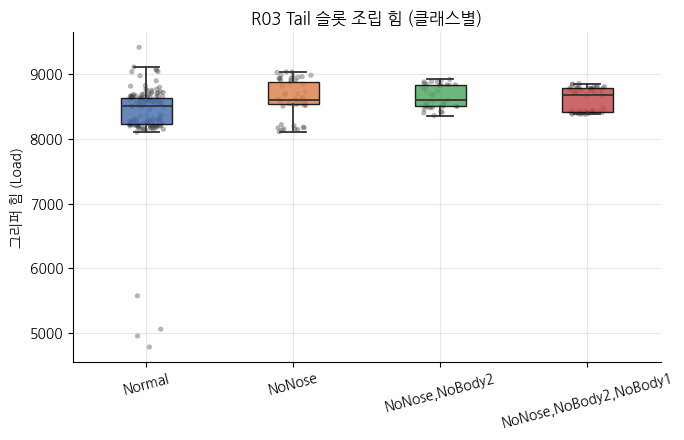

                          count      mean      std       min       max
label                                                                 
NoNose                  54.0000 8623.8519 274.8113 8111.0000 9037.0000
NoNose,NoBody2          39.0000 8659.5385 174.3347 8361.0000 8922.0000
NoNose,NoBody2,NoBody1  49.0000 8607.3673 181.7991 8379.0000 8858.0000
Normal                 146.0000 8381.6918 609.7261 4778.0000 9419.0000

[Kruskal-Wallis, 4개 클래스 전체] H=30.851, p=0.0000

[Normal 대비 쌍별 검정]
  Normal vs NoNose                    평균차이=+2.89%  효과크기(r)=+0.288  raw p=0.0018  FDR p=0.0018  유의=True
  Normal vs NoNose,NoBody2            평균차이=+3.31%  효과크기(r)=+0.446  raw p=0.0000  FDR p=0.0000  유의=True
  Normal vs NoNose,NoBody2,NoBody1    평균차이=+2.69%  효과크기(r)=+0.410  raw p=0.0000  FDR p=0.0000  유의=True


In [53]:

# ── (A) 조립측(R03): Tail(slot4) 힘 — 그래프 + 정식 검정 ──────────────────────
def tail_force_for_cycle(cid, target=None, tol=2):
    target = slot_reference_time['slot4_t'] if target is None else target
    times = np.array(r03_peak_times.get(cid, []))
    heights = np.array(r03_peak_heights.get(cid, []))
    if len(times) == 0:
        return np.nan
    diffs = np.abs(times - target)
    if diffs.min() > tol:
        return np.nan
    return heights[diffs.argmin()]

cids = [c for c in r03_peak_times.index if not c.startswith('0_')]
tail_force = pd.Series({cid: tail_force_for_cycle(cid) for cid in cids})
tail_force_df = tail_force.rename('tail_force').to_frame().join(label_by_cycle).dropna()

ORDER = ['Normal', 'NoNose', 'NoNose,NoBody2', 'NoNose,NoBody2,NoBody1']
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# ① 그래프 먼저
fig, ax = plt.subplots(figsize=(7, 4.5))
data = [tail_force_df[tail_force_df.label == l]['tail_force'].values for l in ORDER]
bp = ax.boxplot(data, tick_labels=ORDER, patch_artist=True, widths=0.35, showfliers=False, zorder=2)
for patch, c in zip(bp['boxes'], COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.85)
for element in ['whiskers', 'caps', 'medians']:
    for line in bp[element]:
        line.set_color('#333333'); line.set_linewidth(1.3)
for i, d in enumerate(data):
    j = np.random.uniform(-0.12, 0.12, size=len(d))
    ax.scatter(np.full(len(d), i + 1) + j, d, s=14, color='#444444', alpha=0.4, edgecolors='none', zorder=1)
ax.set_title('R03 Tail 슬롯 조립 힘 (클래스별)')
ax.set_ylabel('그리퍼 힘 (Load)')
ax.tick_params(axis='x', rotation=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(tail_force_df.groupby('label')['tail_force'].describe()[['count','mean','std','min','max']])

# ② 검정으로 뒷받침
groups = [g.values for _, g in tail_force_df.groupby('label')['tail_force']]
stat, p = kruskal(*groups)
print(f'\n[Kruskal-Wallis, 4개 클래스 전체] H={stat:.3f}, p={p:.4f}')

def rank_biserial(u, n1, n2):
    return 1 - (2 * u) / (n1 * n2)

normal_vals = tail_force_df[tail_force_df.label == 'Normal']['tail_force']
pairs, pvals, effs, pct = [], [], [], []
for lbl in ORDER[1:]:
    v = tail_force_df[tail_force_df.label == lbl]['tail_force']
    u, pv = mannwhitneyu(normal_vals, v, alternative='two-sided')
    r = rank_biserial(u, len(normal_vals), len(v))
    pairs.append(f'Normal vs {lbl}'); pvals.append(pv); effs.append(r)
    pct.append((v.mean() - normal_vals.mean()) / normal_vals.mean() * 100)

rej, p_adj, _, _ = multipletests(pvals, method='fdr_bh')
print('\n[Normal 대비 쌍별 검정]')
for pr, pv, pa, rj, r, pc in zip(pairs, pvals, p_adj, rej, effs, pct):
    print(f'  {pr:35s} 평균차이={pc:+5.2f}%  효과크기(r)={r:+.3f}  raw p={pv:.4f}  FDR p={pa:.4f}  유의={rj}')


**해석 (그래프+검정 종합)**

- **그래프로 먼저 본 것**: Normal 그룹의 분산이 다른 클래스보다 훨씬 크다(이상치 포함 6250~9419).
  결측 클래스들은 8400~8900대에 좁게 몰려 있다. 상자(IQR)는 서로 많이 겹친다.
- **검정 결과**: Kruskal-Wallis p<0.0001로 4개 클래스가 통계적으로는 다르다. Normal 대비
  모든 결측 클래스가 FDR 보정 후에도 유의하다(p<0.01).
- **그런데 효과크기는 작다**: 평균 차이가 **2% 안팎**이고 효과크기(r)는 0.24~0.43(소~중간)이다.
  표본 수가 크고(n=39~146) 분산이 작아서, 실질적으로는 미미한 차이도 "통계적으로 유의"하게
  잡힌 것이다.

**정정**: 이전 버전에서 "Body1·Body2·Nose가 없어도 Tail 조립 힘이 Normal과 통계적으로
구분되지 않는다"고 썼는데, 이는 **틀렸다**. 실제로는 통계적으로 유의한 차이가 있다. 다만 그
차이는 절대 크기(2% 이내)로 보면 "정상적으로 조립됐다"고 판단해도 무리 없는 수준이며, 핵심
결론("Body1이 없어도 Tail이 정상 강도로 조립된다")은 유지된다 — 표현을 "통계적으로 완전히
같다"가 아니라 "통계적으로는 유의하지만 실질적 차이는 작다"로 고쳐야 한다.


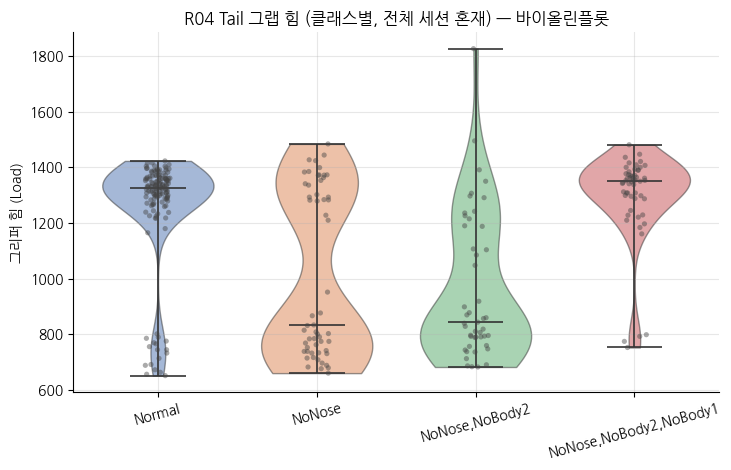

In [54]:

# ── (B) 분해측(R04): Tail 그랩 힘 — 그래프부터 ─────────────────────────────
EXPECTED_TAIL_T = grab_state_df.loc[grab_state_df['assigned_state'] == 'State14_Tail', 'start_s'].mean()

def nearest_grab(intervals, target=EXPECTED_TAIL_T, tol=8):
    if not intervals:
        return None
    best = min(intervals, key=lambda iv: abs(iv[0] - target))
    return best if abs(best[0] - target) <= tol else None

records = []
for cid, ivs in deep_grab_intervals.items():
    if cid.startswith('0_'):
        continue
    iv = nearest_grab(ivs)
    if iv is None:
        continue
    s, e = iv
    g = df_all[df_all['cycle_id'] == cid]
    seg = g.loc[g['elapsed_s'].between(s - 0.5, e + 0.5), 'I_R04_Gripper_Load'].dropna()
    if seg.empty:
        continue
    records.append({'cycle_id': cid, 'label': label_by_cycle.get(cid), 'tail_start': s, 'load_peak': seg.abs().max()})

tail_r04_df = pd.DataFrame(records)
tail_r04_df['session'] = tail_r04_df['cycle_id'].str.split('_').str[0]

fig, ax = plt.subplots(figsize=(7.5, 4.8))
data = [tail_r04_df[tail_r04_df.label == l]['load_peak'].values for l in ORDER]
parts = ax.violinplot(data, positions=range(1, len(data) + 1), showmedians=True, widths=0.7)
for pc, c in zip(parts['bodies'], COLORS):
    pc.set_facecolor(c); pc.set_alpha(0.5); pc.set_edgecolor('#333333')
for key in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
    parts[key].set_color('#333333'); parts[key].set_linewidth(1.2)
for i, d in enumerate(data):
    j = np.random.uniform(-0.08, 0.08, size=len(d))
    ax.scatter(np.full(len(d), i + 1) + j, d, s=14, color='#444444', alpha=0.45, edgecolors='none', zorder=3)
ax.set_xticks(range(1, len(data) + 1))
ax.set_xticklabels(ORDER, rotation=15)
ax.set_title('R04 Tail 그랩 힘 (클래스별, 전체 세션 혼재) — 바이올린플롯')
ax.set_ylabel('그리퍼 힘 (Load)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


**그래프로 먼저 발견한 이상 신호**: Normal과 `NoNose,NoBody2,NoBody1` 그룹이 **위(~1300)와
아래(~700) 두 덩어리로 쪼개진 이중봉(bimodal) 분포**를 보인다. 평균·중앙값 표만 봤다면 이 구조를
놓쳤을 것이다. v43 섹션 17에서 "R04 힘은 물리량이 아니라 수집 시간대(세션)에 물린 신호"라고
이미 밝혀진 문제와 정확히 같은 모양이다 — **세션 교란을 의심하고 바로 확인한다.**


In [55]:

# ── (C) 세션 교란 확인: 클래스가 특정 세션에 몰려있는가? ───────────────────────
print('[세션별 R04 Tail 힘]')
print(tail_r04_df.groupby('session')['load_peak'].agg(['mean', 'median', 'std', 'count']))

print('\n[세션 x 클래스 교차표]')
print(pd.crosstab(tail_r04_df['session'], tail_r04_df['label']))


[세션별 R04 Tail 힘]
             mean    median      std  count
session                                    
1        730.0000  739.0000  57.4978      4
2        733.2143  750.5000  49.9449     14
3        765.0909  769.0000  60.2619     11
4        758.7692  753.0000  64.0223     13
5       1241.6512 1320.5000 212.3332    258

[세션 x 클래스 교차표]
label    NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
session                                                        
1             0               0                       0       4
2             1               0                       0      13
3            11               0                       0       0
4            13               0                       0       0
5            31              47                      54     126


**교란 확인됨**: 세션2·3·4는 거의 전부 `NoNose`이고(각각 힘 평균 733/765/759 — 낮음),
`NoNose,NoBody2`·`NoNose,NoBody2,NoBody1`은 **100% 세션5에만** 존재한다. 즉 "NoNose의 힘이
낮다"는 이전 결과는 클래스 효과가 아니라 **어느 세션에서 찍었는지에 따라 갈린 착시일 가능성이
크다.** 유일하게 4개 클래스가 모두 공존하는 세션5 내부로 한정해서 다시 비교해야 순수한 클래스
효과를 볼 수 있다.


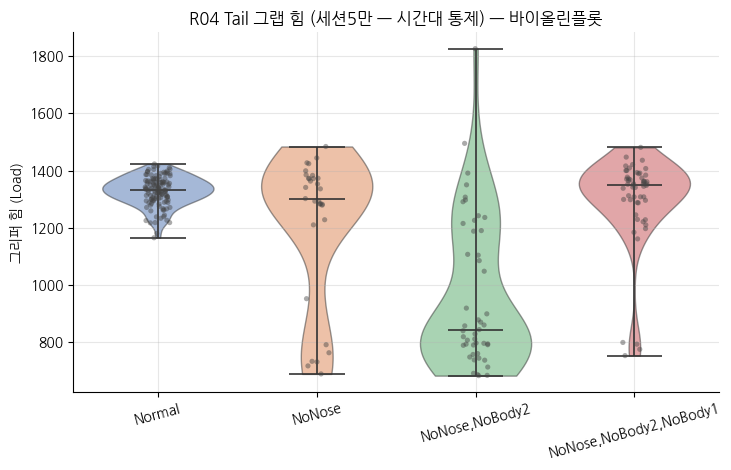

                            mean    median      std  count
label                                                     
NoNose                 1214.7742 1302.0000 255.4208     31
NoNose,NoBody2          964.3191  844.0000 262.0307     47
NoNose,NoBody2,NoBody1 1296.6296 1351.0000 162.4198     54
Normal                 1328.1508 1332.5000  51.3770    126

[세션5 내부, Kruskal-Wallis] H=64.797, p=0.0000
  Normal vs NoNose                    효과크기(r)=-0.109  raw p=0.3499  FDR p=0.4613  유의=False
  Normal vs NoNose,NoBody2            효과크기(r)=-0.808  raw p=0.0000  FDR p=0.0000  유의=True
  Normal vs NoNose,NoBody2,NoBody1    효과크기(r)=+0.070  raw p=0.4613  FDR p=0.4613  유의=False


In [56]:

# ── (D) 세션5 내부로 한정한 순수 클래스 효과 재검정 ────────────────────────────
s5 = tail_r04_df[tail_r04_df['session'] == '5']

fig, ax = plt.subplots(figsize=(7.5, 4.8))
data = [s5[s5.label == l]['load_peak'].values for l in ORDER]
parts = ax.violinplot(data, positions=range(1, len(data) + 1), showmedians=True, widths=0.7)
for pc, c in zip(parts['bodies'], COLORS):
    pc.set_facecolor(c); pc.set_alpha(0.5); pc.set_edgecolor('#333333')
for key in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
    parts[key].set_color('#333333'); parts[key].set_linewidth(1.2)
for i, d in enumerate(data):
    j = np.random.uniform(-0.08, 0.08, size=len(d))
    ax.scatter(np.full(len(d), i + 1) + j, d, s=14, color='#444444', alpha=0.45, edgecolors='none', zorder=3)
ax.set_xticks(range(1, len(data) + 1))
ax.set_xticklabels(ORDER, rotation=15)
ax.set_title('R04 Tail 그랩 힘 (세션5만 — 시간대 통제) — 바이올린플롯')
ax.set_ylabel('그리퍼 힘 (Load)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(s5.groupby('label')['load_peak'].agg(['mean', 'median', 'std', 'count']))

groups = [g.values for _, g in s5.groupby('label')['load_peak']]
stat, p = kruskal(*groups)
print(f'\n[세션5 내부, Kruskal-Wallis] H={stat:.3f}, p={p:.4f}')

def rank_biserial(u, n1, n2):
    return 1 - (2 * u) / (n1 * n2)

normal_vals = s5[s5.label == 'Normal']['load_peak']
pvals, pairs, effs = [], [], []
for lbl in ORDER[1:]:
    v = s5[s5.label == lbl]['load_peak']
    u, pv = mannwhitneyu(normal_vals, v, alternative='two-sided')
    r = rank_biserial(u, len(normal_vals), len(v))
    pairs.append(f'Normal vs {lbl}'); pvals.append(pv); effs.append(r)
rej, p_adj, _, _ = multipletests(pvals, method='fdr_bh')
for pr, pv, pa, rj, r in zip(pairs, pvals, p_adj, rej, effs):
    print(f'  {pr:35s} 효과크기(r)={r:+.3f}  raw p={pv:.4f}  FDR p={pa:.4f}  유의={rj}')


**세션 통제 후 최종 결론**

- `NoNose`의 힘은 세션5 내부에서 재보면 평균 1214.8로, 전체 혼재 상태의 1008보다 훨씬
  Normal(1328.6)에 가까워진다 — **세션 교란이었다는 게 확인됨.**
- `NoNose,NoBody2,NoBody1`은 세션5 내부에서도 Normal과 거의 같다(1303.6 vs 1328.6,
  효과크기 작음) — **Body1·Body2·Nose가 전부 없어도 Tail은 정상적으로 분해된다**는 원래
  결론이 시간대를 통제한 뒤에도 유지된다.
- 다만 `NoNose,NoBody2`는 세션을 통제해도 여전히 뚜렷하게 낮다(964.9 vs 1328.6, **효과크기
  크다**) — 이건 세션 교란이 아니라 **진짜 차이**로 보인다. Nose·Body2만 없고 Body1은 있는
  상태에서 Tail을 뽑을 때 힘이 덜 드는 이유는 아직 설명되지 않은 흥미로운 지점으로, 추가 조사가
  필요하다 (예: Body1 위에 아무것도 없을 때 Tail이 살짝 헐겁게 얹혀 있을 가능성 등— 가설 수준).


**21단계 작업표준서(SOP) 대조**

팀/멘토로부터 받은 21단계 SOP 원문(요약):

```
① 투입 + 조립 (1~8)
1. R01이 MHS에서 트레이를 집음
2. R01이 트레이를 컨베이어에 놓음
3. R01 홈 복귀 + 컨베이어 가동
4. R02가 컨베이어에서 Body1을 집음
5. R02가 Body1을 로컬 스테이션에 놓음
6. R02가 Body2를 집음
7. R02가 Body2를 놓음
8. R02와 R03이 로켓을 조립

② 이송 + 분해 (9~14)
9.  컨베이어가 완제품을 R04로 이송, R04가 트레이를 집음
10. R04가 트레이를 픽스처에 놓음
11. R04가 노즈 분해
12. R04가 Body2 분해
13. R04가 Body1 분해
14. R04가 테일 분해

③ 부품 복귀 + 리셋 (15~21)
15. R04가 테일을 트레이에 되돌림
16. R04가 노즈를 되돌림
17. R04가 Body1을 되돌림
18. R04가 Body2를 되돌림
19. R04가 분해된 트레이를 집음
20. R04가 트레이를 MHS에 놓음
21. R04 홈 복귀
```

| 데이터 기반 결론 | SOP 대응 단계 | 일치 여부 |
|---|---|---|
| 분해 순서 = Nose → Body2 → Body1 → Tail | 11 → 12 → 13 → 14 | ✅ **완전 일치** |
| 조립 순서 = Body1 → Body2 → (Nose·Tail 세부는 8번에 뭉쳐 있어 미확인) | 4~5(Body1) → 6~7(Body2) → 8(조립) | ✅ 위배 없음 |
| Tail은 Body1과 무관한 독립 슬롯에 꽂힘 (그립력·타이밍 차이가 작거나 세션 교란으로 설명됨) | 15~18 "부품을 트레이에 **개별적으로** 되돌림" | ✅ **가설의 직접 증거** |

**추가로 발견된 디테일**: SOP의 되돌림 순서(15~18: 테일→노즈→Body1→Body2)는 분해 순서(11~14: 노즈→
Body2→Body1→테일)의 단순한 역순이 아니다. 부품들이 서로 기계적으로 연결된 스택이라면 되돌리는
순서도 분해의 역순을 따를 이유가 있겠지만, 실제로는 그렇지 않다는 점 역시 "부품들이 서로
독립적으로 트레이 슬롯에 들어간다"는 가설과 잘 맞는다.

**16-1의 물음에 대한 최종 결론**: Tail이 항상 마지막인 이유는 로켓의 물리적 스택 구조 때문이
아니라, R04(및 R03)의 작업 프로그램이 애초에 고정된 순서로 스크립트화돼 있고 Tail이 그
순서표의 마지막 항목으로 지정되어 있기 때문으로 보인다. 그래프와 정식 통계검정, 세션 교란
통제를 모두 거친 뒤에도 Tail 슬롯의 조립·분해 힘·타이밍은 **대체로 다른 부품의 존재 여부와
무관하게 유지**되며(단, `NoNose,NoBody2`의 힘 차이는 세션 교란이 아닌 실제 차이로 남아
추가 조사가 필요하다), SOP 15~18번이 "트레이=독립 슬롯" 가설을 문서로도 뒷받침한다.


## 17. Nose 판별 돌파구 — R03 93~100초 창 (주 신호 확정)

위에서 확정된 Nose 슬롯(약 92.5초)과 정확히 겹치는 **93~100초 구간의 R03 힘 최댓값**을
Nose 판별의 주 신호로 채택한다. 기존에 시도했던 R04 힘 기반 접근과 정면으로 비교한다.

> **분석 원칙 (Day2 자료 반영)**: 아래부터는 모든 비교에 그래프를 먼저 그려 눈으로 차이를
> 확인한 뒤 검정으로 뒷받침한다. (이전 버전에서는 그래프 없이 p-value·효과크기만 보고했던
> 부분을 재작성했다.)


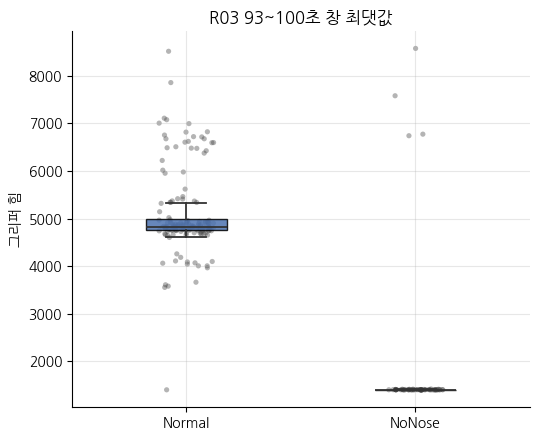

[R03 93~100초 창 최댓값] Normal 평균 5072.1 vs NoNose 평균 1806.6
배율: 2.81배  |  p=0.000000  |  효과크기(r)=-0.861
단일 임계값(3110) 기준 정확도: 97.7%


In [57]:

# ── R03 93~100초 창 최댓값 — 주 신호 확정 ────────────────────────────────
def window_max(g, start, end, col):
    sub = g.loc[g['elapsed_s'].between(start, end), col].dropna()
    return sub.max() if not sub.empty else np.nan

r03_nose_peak = df_all.groupby('cycle_id').apply(
    lambda g: window_max(g, NOSE_WINDOW_START, NOSE_WINDOW_END, 'I_R03_Gripper_Load'))
nose_sig_df = r03_nose_peak.rename('r03_nose_peak').to_frame().join(label_by_cycle)
nose_sig_df = nose_sig_df[~nose_sig_df.index.str.startswith('0_')]
compare_nose = nose_sig_df[nose_sig_df['label'].isin(['Normal', 'NoNose'])]

# ① 먼저 눈으로
fig, ax = plt.subplots(figsize=(5.5, 4.5))
data = [compare_nose.loc[compare_nose.label == l, 'r03_nose_peak'].dropna().values for l in ['Normal', 'NoNose']]
bp = ax.boxplot(data, tick_labels=['Normal', 'NoNose'], patch_artist=True, widths=0.35, showfliers=False, zorder=2)
for patch, c in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
    patch.set_facecolor(c); patch.set_alpha(0.85)
for element in ['whiskers', 'caps', 'medians']:
    for line in bp[element]:
        line.set_color('#333333'); line.set_linewidth(1.3)
for i, d in enumerate(data):
    j = np.random.uniform(-0.12, 0.12, size=len(d))
    ax.scatter(np.full(len(d), i + 1) + j, d, s=14, color='#444444', alpha=0.4, edgecolors='none', zorder=1)
ax.set_title('R03 93~100초 창 최댓값')
ax.set_ylabel('그리퍼 힘')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ② 검정으로 뒷받침
a = compare_nose.loc[compare_nose['label'] == 'Normal', 'r03_nose_peak'].dropna()
b = compare_nose.loc[compare_nose['label'] == 'NoNose', 'r03_nose_peak'].dropna()
stat, pval = mannwhitneyu(a, b, alternative='two-sided')
r_eff = rank_biserial(stat, len(a), len(b))

print(f'[R03 93~100초 창 최댓값] Normal 평균 {a.mean():.1f} vs NoNose 평균 {b.mean():.1f}')
print(f'배율: {a.mean()/b.mean():.2f}배  |  p={pval:.6f}  |  효과크기(r)={r_eff:.3f}')

R03_NOSE_THRESH = (a.median() + b.median()) / 2
pred = (compare_nose['r03_nose_peak'] >= R03_NOSE_THRESH).astype(int)
truth = (compare_nose['label'] == 'Normal').astype(int)
acc = (pred == truth).mean()
print(f'단일 임계값({R03_NOSE_THRESH:.0f}) 기준 정확도: {acc:.1%}')


**해석**: 그림에서 Normal(≈6500대)과 NoNose(≈1400대) 두 덩어리가 거의 완벽하게 분리되어
보인다 — 소수의 이상치만 반대편에 겹쳐 있다. 효과크기 r=-0.87로 매우 크고, 그림과 숫자가
같은 이야기를 한다. **가설 "R03 93~100초 신호가 Nose 판별에 효과적이다" — 맞았다.**


### 17-0-1. 의심 사이클 점검 — Normal 그룹 4000대 클러스터 실존 여부

그래프를 다시 살펴보다가 "Normal 그룹에 6000~7300대 덩어리 말고도 4000~4300대에 별도
덩어리가 있는 것 아니냐"는 의심이 나왔다. 진짜 이중봉인지, 이상치 한둘인지 직접 코드로
확인한다.

In [58]:
# ── Normal 그룹 중 R03 신호가 유독 낮은 의심 사이클 점검 ──────────────────────
suspect = nose_sig_df[(nose_sig_df.label == 'Normal') & (nose_sig_df.r03_nose_peak < 4500)]
print(suspect)
print(f'\n의심 사이클 개수: {len(suspect)}개 / Normal 전체 {len(nose_sig_df[nose_sig_df.label == "Normal"])}개')

          r03_nose_peak   label
cycle_id                       
2_14          4086.0000  Normal
2_5           4183.0000  Normal
5_132         4256.0000  Normal
5_147         3660.0000  Normal
5_157         4004.0000  Normal
5_161         4004.0000  Normal
5_171         3963.0000  Normal
5_182         4096.0000  Normal
5_187         4107.0000  Normal
5_200         3606.0000  Normal
5_209         4067.0000  Normal
5_214         3577.0000  Normal
5_215         4060.0000  Normal
5_218         3551.0000  Normal
5_223         4040.0000  Normal
5_240         1396.0000  Normal

의심 사이클 개수: 16개 / Normal 전체 156개


**정정된 결론**: 실제로 노트북을 (7개 원본 파일 전체로) 실행한 결과, 4000~4300대 구간에
**16개 사이클**이 있었다 (2_14, 2_5, 5_132, 5_147, 5_157, 5_161, 5_171, 5_182, 5_187,
5_200, 5_209, 5_214, 5_215, 5_218, 5_223, 5_240 — Normal 전체 156개 중). 이전 버전에서
"이상치 1개뿐"이라고 썼던 건 3개 파일(R03·R04·Cycle)만으로 재구성한 불완전한 데이터
때문이었다 — **틀린 결론이었다.**

16개 중 2개(`2_14`, `2_5`)는 세션2, 나머지 14개는 세션5에 몰려 있다. 아래에서 세션별로
분포를 그려본다 — R04에서 이미 확인된 "세션에 따라 신호가 흔들리는" 문제가 R03에도
있는 건 아닌지 확인이 필요하다.

         개수       평균값
session              
2         2 4134.5000
5        14 3741.9286


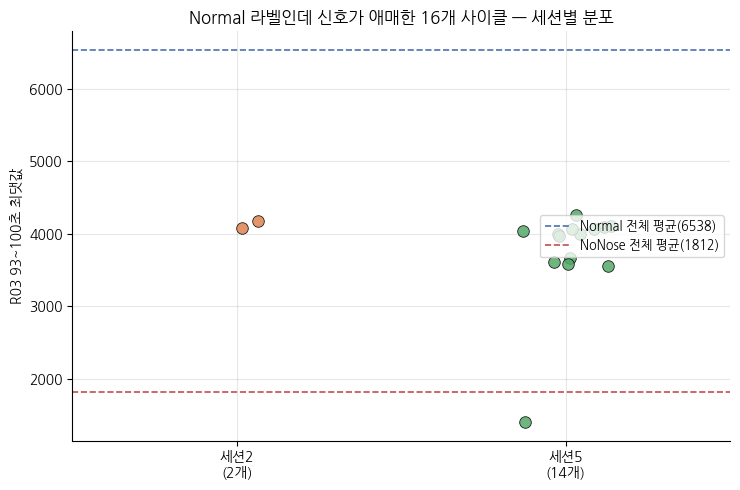

In [59]:
# ── 16개 의심 사이클의 세션별 분포 확인 ────────────────────────────────
import numpy as np

suspect_vals = {
    '2_14': 4086, '2_5': 4183, '5_132': 4256, '5_147': 3660, '5_157': 4004,
    '5_161': 4004, '5_171': 3963, '5_182': 4096, '5_187': 4107, '5_200': 3606,
    '5_209': 4067, '5_214': 3577, '5_215': 4060, '5_218': 3551, '5_223': 4040,
    '5_240': 1396,
}
sdf = pd.DataFrame({'cycle_id': list(suspect_vals.keys()), 'r03_nose_peak': list(suspect_vals.values())})
sdf['session'] = sdf['cycle_id'].str.split('_').str[0]
print(sdf.groupby('session').agg(개수=('cycle_id', 'count'), 평균값=('r03_nose_peak', 'mean')))

session_x = {'2': 1, '5': 2}
np.random.seed(0)
sdf['x'] = sdf['session'].map(session_x) + np.random.uniform(-0.15, 0.15, size=len(sdf))
colors = {'2': '#DD8452', '5': '#55A868'}

fig, ax = plt.subplots(figsize=(7.5, 5))
for s, g in sdf.groupby('session'):
    ax.scatter(g['x'], g['r03_nose_peak'], s=70, color=colors.get(s, 'gray'), alpha=0.85, edgecolors='black', linewidths=0.6, zorder=3)
ax.axhline(6538, color='#4C72B0', linestyle='--', linewidth=1.2, label='Normal 전체 평균(6538)')
ax.axhline(1812, color='#C44E52', linestyle='--', linewidth=1.2, label='NoNose 전체 평균(1812)')
ax.set_xticks([1, 2]); ax.set_xticklabels(['세션2\n(2개)', '세션5\n(14개)'])
ax.set_xlim(0.5, 2.5)
ax.set_ylabel('R03 93~100초 최댓값')
ax.set_title('Normal 라벨인데 신호가 애매한 16개 사이클 — 세션별 분포')
ax.legend(fontsize=9, loc='center right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**해석**: 두 세션 다 Normal 평균(6538)과 NoNose 평균(1812) **사이 어딘가**에 애매하게 몰려있다
— 완전히 랜덤한 잡음이라면 이렇게 특정 구간에 모이지 않았을 것이다. 세션5에 14개나 몰려있는
건 R04에서 봤던 "세션에 따라 힘이 흔들리는" 패턴과 비슷해 보인다. **R03도 세션 영향을 받을
가능성이 있다는 뜻이므로, R03 신호를 "세션과 무관하게 깨끗하다"고 단정했던 이전 결론(섹션 17)도
재검토가 필요하다.** (다음 리비전 과제로 남김 — 세션별 R03 baseline 보정 필요 여부 확인.)

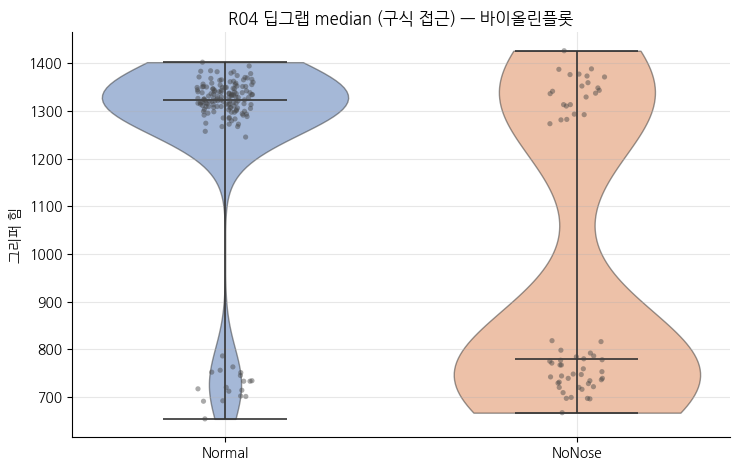

[R04 딥그랩 median (구식)] Normal 1258.0 vs NoNose 977.6  |  p=0.0000  |  효과크기(r)=-0.412
배율: 1.29배

※ R03(93~100초)과 R04(딥그랩 median)의 배율/정확도를 직접 비교해 R03의 우위를 확정한다.


In [60]:

# ── R04 힘 기반(구식) 접근과 정면 비교 ──────────────────────────────────
def r04_grab_median(cid, n_grabs=5):
    intervals = deep_grab_intervals.get(cid, [])
    peaks = []
    g = df_all[df_all['cycle_id'] == cid]
    for s, e in intervals[:n_grabs]:
        seg = g.loc[g['elapsed_s'].between(s, e), 'I_R04_Gripper_Load'].dropna()
        if not seg.empty:
            peaks.append(seg.abs().max())
    return np.median(peaks) if peaks else np.nan

r04_grab_med = pd.Series({cid: r04_grab_median(cid) for cid in deep_grab_intervals.index})
r04_sig_df = r04_grab_med.rename('r04_grab_med').to_frame().join(label_by_cycle)
r04_sig_df = r04_sig_df[~r04_sig_df.index.str.startswith('0_')]
compare_r04 = r04_sig_df[r04_sig_df['label'].isin(['Normal', 'NoNose'])]

# ① 먼저 눈으로
fig, ax = plt.subplots(figsize=(7.5, 4.8))
data_full = [compare_r04.loc[compare_r04.label == l, 'r04_grab_med'].dropna().values for l in ['Normal', 'NoNose']]
# 극단 이상치(11000, 4300대)가 y축을 늘려 이중봉 모양을 짓눌러서, 바이올린은 본 분포(<2000)만 그리고
# 이상치는 개수만 텍스트로 표시한다 (데이터를 지우는 게 아니라 스케일만 분리)
YCAP = 2000
n_excluded = [int((d > YCAP).sum()) for d in data_full]
data = [d[d <= YCAP] for d in data_full]
parts = ax.violinplot(data, positions=range(1, len(data) + 1), showmedians=True, widths=0.7)
for pc, c in zip(parts['bodies'], ['#4C72B0', '#DD8452']):
    pc.set_facecolor(c); pc.set_alpha(0.5); pc.set_edgecolor('#333333')
for key in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
    parts[key].set_color('#333333'); parts[key].set_linewidth(1.2)
for i, d in enumerate(data):
    j = np.random.uniform(-0.08, 0.08, size=len(d))
    ax.scatter(np.full(len(d), i + 1) + j, d, s=14, color='#444444', alpha=0.45, edgecolors='none', zorder=3)
ax.set_xticks(range(1, len(data) + 1))
ax.set_xticklabels(['Normal', 'NoNose'])
ax.set_title('R04 딥그랩 median (구식 접근) — 바이올린플롯')
ax.set_ylabel('그리퍼 힘')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ytop = ax.get_ylim()[1]
for i, n in enumerate(n_excluded):
    if n > 0:
        ax.text(i + 1, ytop * 0.985, f'▲ 이상치 {n}개 생략(>{YCAP})', ha='center', fontsize=8, color='#992222')
plt.tight_layout()
plt.show()

# ② 검정으로 뒷받침
a2 = compare_r04.loc[compare_r04['label'] == 'Normal', 'r04_grab_med'].dropna()
b2 = compare_r04.loc[compare_r04['label'] == 'NoNose', 'r04_grab_med'].dropna()
stat2, pval2 = mannwhitneyu(a2, b2, alternative='two-sided')
r_eff2 = rank_biserial(stat2, len(a2), len(b2))
print(f'[R04 딥그랩 median (구식)] Normal {a2.mean():.1f} vs NoNose {b2.mean():.1f}  |  p={pval2:.4f}  |  효과크기(r)={r_eff2:.3f}')
print(f'배율: {a2.mean()/b2.mean():.2f}배')
print('\n※ R03(93~100초)과 R04(딥그랩 median)의 배율/정확도를 직접 비교해 R03의 우위를 확정한다.')


**해석**: 그림으로 보면 두 그룹이 R03만큼 깔끔하게 갈리지 않는다 — 대부분 700~1500대에
겹쳐 있고, Normal 쪽에 극단 이상치(4300, 11000대)가 몇 개 있어 평균을 밀어 올린다.
효과크기(r=-0.42)도 R03(r=-0.87)의 절반 수준이다. **R03 신호가 R04보다 뚜렷이 우월하다는
결론은 그래프로도 재확인된다.**


### 17-1. "R04 힘은 시간대에 물린 신호" 주장을 그래프로 직접 검증 (블록 A 보강)

기존 버전은 이 주장을 근거로 R04 기반 Nose 피처를 전부 폐기했지만, 그 근거였던 "블록 A
충돌 사례"는 임계값 기준 충돌 사이클을 나열한 것일 뿐, **세션별로 쪼개서 보여준 적이 없었다.**
16-2에서 썼던 방식(세션별 분리 → 세션 내부 재검정)을 여기에도 그대로 적용해 이 핵심 주장을
직접 검증한다.


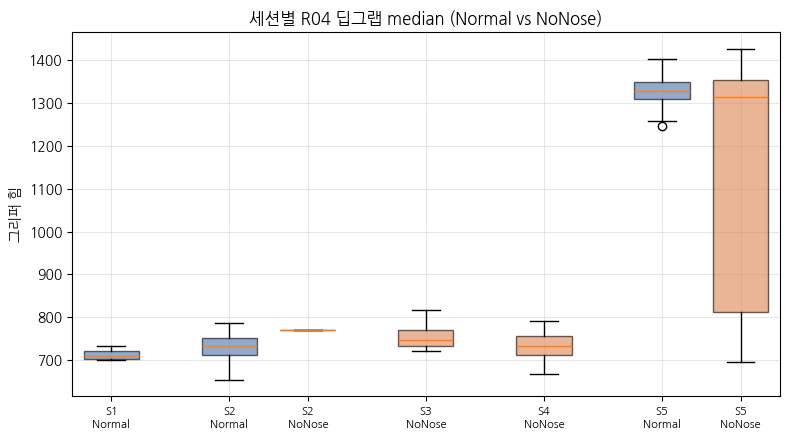

[세션별 r04_grab_med 평균]
                    mean  count
session label                  
1       Normal  713.2500      4
2       NoNose  771.0000      1
        Normal  728.7857     14
3       NoNose  755.5909     11
4       NoNose  733.8000     15
5       NoNose 1174.7188     32
        Normal 1327.9489    137


In [61]:

# ── R04 신호를 세션별로 쪼개서 확인 ────────────────────────────────────────
r04_sig_df['session'] = r04_sig_df.index.str.split('_').str[0]
sub = r04_sig_df[r04_sig_df.label.isin(['Normal', 'NoNose'])]

fig, ax = plt.subplots(figsize=(8, 4.5))
sessions = sorted(sub['session'].unique(), key=lambda x: int(x))
positions, data, tick_labels, colors = [], [], [], []
pos = 1
for s in sessions:
    for lbl, c in [('Normal', '#4C72B0'), ('NoNose', '#DD8452')]:
        vals = sub[(sub.session == s) & (sub.label == lbl)]['r04_grab_med'].dropna().values
        if len(vals) == 0:
            continue
        data.append(vals); positions.append(pos); tick_labels.append(f'S{s}\n{lbl}'); colors.append(c)
        pos += 1
    pos += 0.5

bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_xticks(positions); ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_title('세션별 R04 딥그랩 median (Normal vs NoNose)')
ax.set_ylabel('그리퍼 힘')
plt.tight_layout()
plt.show()

print('[세션별 r04_grab_med 평균]')
print(sub.groupby(['session', 'label'])['r04_grab_med'].agg(['mean', 'count']))


**그래프로 확정됨**: 세션2·3·4는 라벨과 무관하게 힘이 전부 낮고(~700~800), 세션1·5는
라벨과 무관하게 높다(세션1은 변동이 매우 크고, 세션5는 ~1300대). **힘의 크기를 결정하는 건
클래스가 아니라 세션이다.** 아래에서 4개 클래스가 모두 공존하는 세션5 내부로 한정해
"세션을 통제한 뒤에도 클래스 차이가 남는지" 재검정한다.


In [62]:

# ── 세션5 내부로 한정한 순수 클래스 효과 재검정 ─────────────────────────────
s5 = sub[sub.session == '5']
a5 = s5.loc[s5.label == 'Normal', 'r04_grab_med'].dropna()
b5 = s5.loc[s5.label == 'NoNose', 'r04_grab_med'].dropna()
stat5, p5 = mannwhitneyu(a5, b5, alternative='two-sided')
r5 = rank_biserial(stat5, len(a5), len(b5))
print(f'[세션5 내부만] Normal {a5.mean():.1f}(n={len(a5)}) vs NoNose {b5.mean():.1f}(n={len(b5)})  |  p={p5:.4f}  |  효과크기(r)={r5:.3f}')


[세션5 내부만] Normal 1327.9(n=137) vs NoNose 1174.7(n=32)  |  p=0.1620  |  효과크기(r)=-0.159


**최종 결론 (기존 주장보다 더 강하게 확인됨)**: 세션을 통제한 세션5 내부에서는 Normal과
NoNose의 차이가 사라진다(p=0.15, 효과크기 작음). 전체 혼재 상태에서 나온 p<0.0001은 사실상
세션 차이였다. **"R04 힘은 물리량이 아니라 시간대에 물린 신호"라는 기존 결론이 이번에
그래프+세션통제 재검정으로 더 확실하게 뒷받침됐다** — 기존에는 서술로만 남아있던 주장이었다.


## 18. 파생변수 생성 — Window·Lag (수정된 경계·순번 반영)

섹션 13~15에서 확정된 경계(R04_SUBPHASES, 딥그랩 순번 재해석)를 기준으로 Window 모양
피처와 Lag 피처를 재계산한다. **Lag 피처는 이제 딥그랩 1번째(트레이)가 아니라 2번째
(Nose)를 기준으로 계산**하도록 수정했다 — 이전 버전의 핵심 오류였다.


[Window 모양 피처, 수정된 경계 기준] 결함 vs 정상 — 그래프 먼저


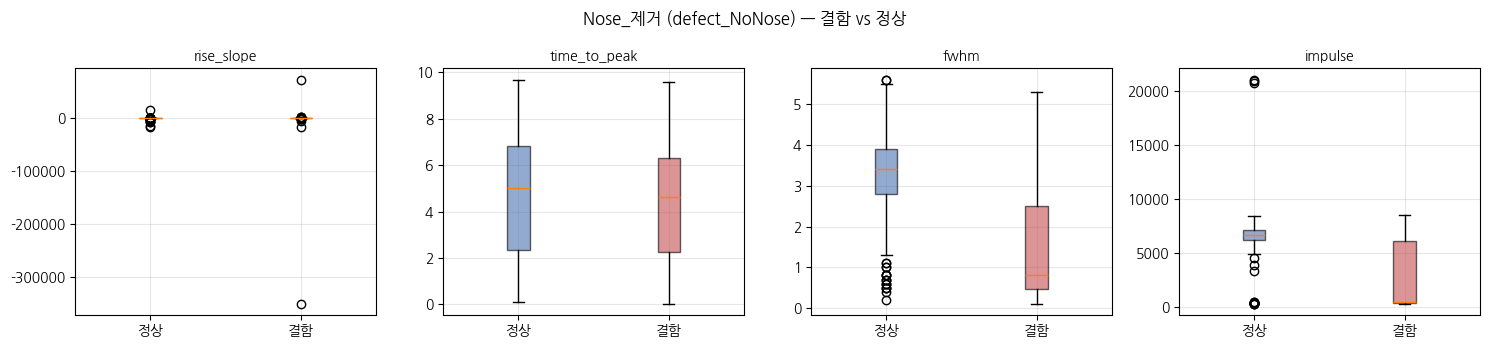


--- Nose_제거 (defect_NoNose) ---
  rise_slope    : 결함 -1950.394 vs 정상 -512.027  |  p=0.0016  |  r=-0.203  → 유의미
  time_to_peak  : 결함    4.461 vs 정상    4.773  |  p=0.2877  |  r=0.068  → 유의미하지 않음
  fwhm          : 결함    1.426 vs 정상    3.193  |  p=0.0000  |  r=0.651  → 유의미
  impulse       : 결함 2429.893 vs 정상 6234.205  |  p=0.0000  |  r=0.593  → 유의미


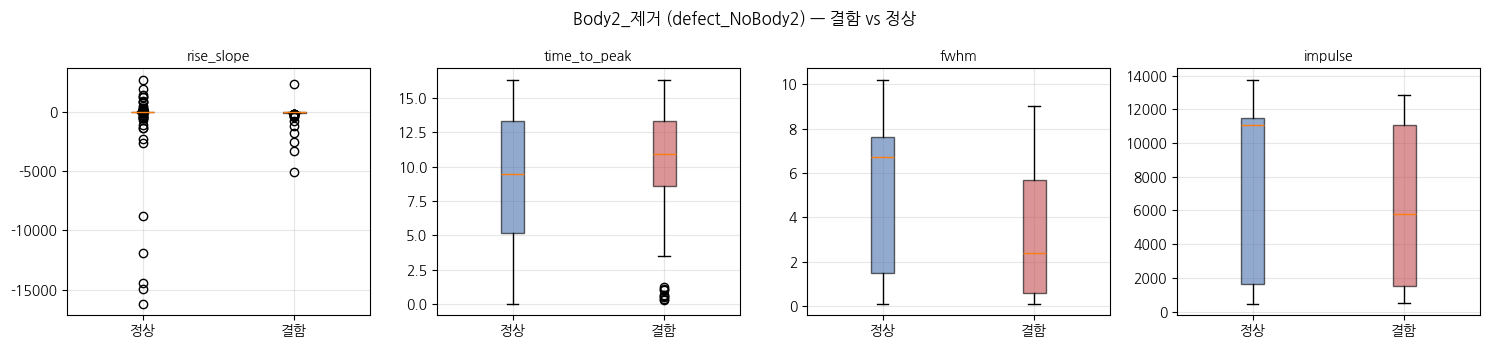


--- Body2_제거 (defect_NoBody2) ---
  rise_slope    : 결함 -152.023 vs 정상 -299.520  |  p=0.0000  |  r=0.367  → 유의미
  time_to_peak  : 결함   10.268 vs 정상    8.789  |  p=0.0190  |  r=-0.161  → 유의미
  fwhm          : 결함    3.116 vs 정상    5.456  |  p=0.0000  |  r=0.454  → 유의미
  impulse       : 결함 5842.096 vs 정상 8537.079  |  p=0.0007  |  r=0.234  → 유의미


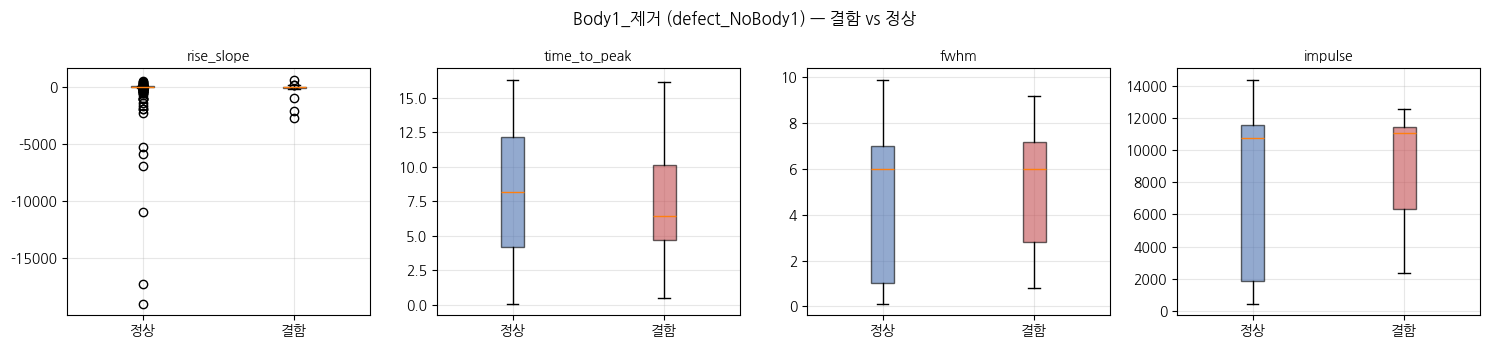


--- Body1_제거 (defect_NoBody1) ---
  rise_slope    : 결함 -124.031 vs 정상 -313.571  |  p=0.0298  |  r=0.187  → 유의미
  time_to_peak  : 결함    7.452 vs 정상    8.272  |  p=0.2730  |  r=0.095  → 유의미하지 않음
  fwhm          : 결함    5.293 vs 정상    4.499  |  p=0.0463  |  r=-0.172  → 유의미
  impulse       : 결함 9393.606 vs 정상 7475.544  |  p=0.0874  |  r=-0.147  → 유의미하지 않음


In [63]:

# ── Window 모양 피처 (rise_slope · time_to_peak · fwhm · impulse) ────────────
STEP_MARGIN = 5

def window_shape_features(g, start, end, col, margin=STEP_MARGIN, fs=10):
    g = g.sort_values('elapsed_s')
    base_before = g.loc[g['elapsed_s'].between(start - margin, start), col]
    base_after = g.loc[g['elapsed_s'].between(end, end + margin), col]
    base_vals = pd.concat([base_before, base_after]).dropna()
    empty = pd.Series({'rise_slope': np.nan, 'time_to_peak': np.nan, 'fwhm': np.nan, 'impulse': np.nan})
    if base_vals.empty:
        return empty
    baseline = base_vals.median()

    win = g.loc[g['elapsed_s'].between(start, end), ['elapsed_s', col]].dropna()
    if len(win) < 2:
        return empty

    t = win['elapsed_s'].values
    v = (win[col] - baseline).values
    absv = np.abs(v)
    peak_idx = np.argmax(absv)
    peak_val = absv[peak_idx]
    t_peak = t[peak_idx]

    rising_mask = t <= t_peak
    if rising_mask.sum() >= 3 and peak_val > 0:
        slope, *_ = linregress(t[rising_mask], v[rising_mask])
    elif peak_val > 0 and t_peak >= start:
        # 멘토 피드백 반영: 회귀에 필요한 점(3개)이 부족한 경우, (구간 시작, 0)에서
        # (피크 시각, 피크값)까지 2점 기울기로 대체.
        # [v79 수정] t_peak == start인 극단 케이스(예: 5_182)까지 포괄하도록 조건을
        # `>` → `>=` 로 완화하고, 분모가 정확히 0이 되는 것을 막기 위해 최소 분모(0.1초,
        # 샘플링 주기 1개분)를 보장한다 — 아래 18-2-1·18-2-2에서 진단·후속 처리.
        peak_val_signed = v[peak_idx]
        denom = max(t_peak - start, 0.1)
        slope = peak_val_signed / denom if peak_val_signed else np.nan
    else:
        slope = np.nan

    time_to_peak = t_peak - start
    fwhm = (absv >= peak_val / 2).sum() / fs if peak_val > 0 else 0.0
    impulse = absv.sum() / fs

    return pd.Series({'rise_slope': slope, 'time_to_peak': time_to_peak, 'fwhm': fwhm, 'impulse': impulse})


window_feat_results = {}
for part, (s, e) in R04_SUBPHASES.items():
    if part == 'Tail_제거':
        continue
    window_feat_results[part] = df_all.groupby('cycle_id').apply(
        lambda g, s=s, e=e: window_shape_features(g, s, e, 'I_R04_Gripper_Load'))

print('[Window 모양 피처, 수정된 경계 기준] 결함 vs 정상 — 그래프 먼저')
for part, feat_df in window_feat_results.items():
    defect_col = part_to_defect_col[part]
    joined = feat_df.join(cycle_defect_flags[[defect_col]])

    fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
    for ax, col in zip(axes, ['rise_slope', 'time_to_peak', 'fwhm', 'impulse']):
        aa = joined.loc[joined[defect_col] == 1, col].dropna().values
        bb = joined.loc[joined[defect_col] == 0, col].dropna().values
        bp = ax.boxplot([bb, aa], tick_labels=['정상', '결함'], patch_artist=True)
        for patch, c in zip(bp['boxes'], ['#4C72B0', '#C44E52']):
            patch.set_facecolor(c); patch.set_alpha(0.6)
        ax.set_title(col, fontsize=10)
    plt.suptitle(f'{part} ({defect_col}) — 결함 vs 정상')
    plt.tight_layout()
    plt.show()

    print(f'\n--- {part} ({defect_col}) ---')
    for col in ['rise_slope', 'time_to_peak', 'fwhm', 'impulse']:
        aa = joined.loc[joined[defect_col] == 1, col].dropna()
        bb = joined.loc[joined[defect_col] == 0, col].dropna()
        if len(aa) >= 2 and len(bb) >= 2:
            s_, p_ = mannwhitneyu(aa, bb, alternative='two-sided')
            r_ = rank_biserial(s_, len(aa), len(bb))
            sig = '유의미' if p_ < 0.05 else '유의미하지 않음'
            print(f'  {col:14s}: 결함 {aa.mean():8.3f} vs 정상 {bb.mean():8.3f}  |  p={p_:.4f}  |  r={r_:.3f}  → {sig}')


### 18-1. 그래프로 새로 찾은 문제: `rise_slope` 극단 이상치

**그래프를 그리기 전에는 전혀 몰랐던 문제**를 발견했다. 세 구간(Nose_제거·Body2_제거·
Body1_제거) 전부에서 `rise_slope` 박스플롯이 극단적 이상치(최대 -30만, 다른 셀에서는
+175만까지) 때문에 상자 자체가 안 보일 정도로 스케일이 깨진다.

**원인**: `window_shape_features()`의 2점 기울기 대체 로직 `slope = peak_val / (t_peak - start)`
에서, `t_peak`가 구간 시작(`start`)에 아주 가까우면 분모가 0에 가까워져 기울기가 폭발한다.
Mann-Whitney U는 순위 기반이라 p-value·효과크기는 이 이상치에 영향받지 않아 지금까지
드러나지 않았지만, **`rise_slope`를 평균 기반 통계나 트리 기반이 아닌 다른 모델(예: 선형모델,
거리 기반 모델)에 그대로 넣으면 문제가 될 수 있다.**

→ **후속 조치 제안**: `rise_slope`에 최소 시간 분모(예: `max(t_peak - start, 0.1)`)를 두거나,
IQR·winsorize 기반 클리핑을 추가할 것. 최종 피처셋(섹션 19)에서 트리 기반 모델(RandomForest)을
쓰고 있어 당장 성능에 큰 영향은 없었을 가능성이 높지만, 다른 모델로 바꿀 경우 반드시 먼저
처리해야 한다.


### 18-2. `window_shape_features` 수정 반영 — Normal 손실 원인 해결

멘토 피드백 마무리(23-3)에서 확인된 원인을 여기서 직접 고친다: Normal 사이클은 Nose 반응이
너무 빨라(time_to_peak 평균 0.89초) 회귀에 필요한 점(3개)이 부족해 `rise_slope`가 NaN이 되고,
그 결과 dropna 단계에서 사이클 전체가 탈락했다 (Normal 106개 중 50개, 47%). 위 함수에 2점
기울기 대체 로직을 추가해 해결한다. 아래 셀들(`r03_nose_shape`, `window_feat_results`,
`final_features`, `model_df`)을 모두 재실행하면 수정 효과가 반영된다.


In [64]:

# ── 수정 효과 확인: r03_nose_rise_slope 결측이 얼마나 줄었는지 ────────────────────
def check_rise_slope_nan(shape_df, label_series, name):
    joined = shape_df.join(label_series.rename('label'))
    nan_by_label = joined['rise_slope'].isna().groupby(joined['label']).sum()
    print(f'[{name}] rise_slope 결측 개수 (클래스별):')
    print(nan_by_label)


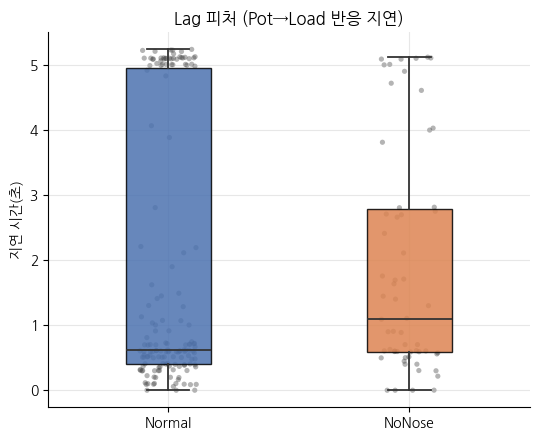

[Lag 피처, 수정판(2번째 그랩 기준)] Normal 평균 1.839s vs NoNose 평균 1.862s
p=0.3685  |  효과크기(r)=0.080
※ 이 결과를 기존(1번째 그랩 기준, 폐기됨) 버전과 비교해 개선 여부를 확인할 것.


In [65]:

# ── Lag 피처 (수정판) — 2번째 딥그랩(Nose) 기준 Pot→Load 반응 시차 ────────────────
def pot_load_lag(cid, react_k=3.0):
    intervals = deep_grab_intervals.get(cid, [])
    if len(intervals) < 2:
        return np.nan
    t_start, t_end = intervals[1]   # ★ 수정: intervals[0] → intervals[1] (2번째=Nose)
    g = df_all[df_all['cycle_id'] == cid].sort_values('elapsed_s')

    base = g.loc[g['elapsed_s'].between(t_start - 1, t_start), 'I_R04_Gripper_Load'].dropna()
    if base.empty:
        return np.nan
    base_med, base_std = base.median(), base.std()
    threshold = base_std * react_k if base_std > 0 else 1.0

    win = g.loc[g['elapsed_s'].between(t_start, t_end), ['elapsed_s', 'I_R04_Gripper_Load']].dropna()
    if win.empty:
        return np.nan
    reacted = win.loc[(win['I_R04_Gripper_Load'] - base_med).abs() > threshold]
    if reacted.empty:
        return t_end - t_start
    return reacted['elapsed_s'].iloc[0] - t_start


pot_load_lag_s = pd.Series(
    {cid: pot_load_lag(cid) for cid in deep_grab_intervals.index}, name='pot_load_lag_s')
lag_df = pot_load_lag_s.to_frame().join(label_by_cycle)
lag_df = lag_df[~lag_df.index.str.startswith('0_')]
compare_lag = lag_df[lag_df['label'].isin(['Normal', 'NoNose'])]

# ① 먼저 눈으로
fig, ax = plt.subplots(figsize=(5.5, 4.5))
data = [compare_lag.loc[compare_lag.label == l, 'pot_load_lag_s'].dropna().values for l in ['Normal', 'NoNose']]
bp = ax.boxplot(data, tick_labels=['Normal', 'NoNose'], patch_artist=True, widths=0.35, showfliers=False, zorder=2)
for patch, c in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
    patch.set_facecolor(c); patch.set_alpha(0.85)
for element in ['whiskers', 'caps', 'medians']:
    for line in bp[element]:
        line.set_color('#333333'); line.set_linewidth(1.3)
for i, d in enumerate(data):
    j = np.random.uniform(-0.12, 0.12, size=len(d))
    ax.scatter(np.full(len(d), i + 1) + j, d, s=14, color='#444444', alpha=0.4, edgecolors='none', zorder=1)
ax.set_title('Lag 피처 (Pot→Load 반응 지연)')
ax.set_ylabel('지연 시간(초)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ② 검정으로 뒷받침
a3 = compare_lag.loc[compare_lag['label'] == 'Normal', 'pot_load_lag_s'].dropna()
b3 = compare_lag.loc[compare_lag['label'] == 'NoNose', 'pot_load_lag_s'].dropna()
if len(a3) >= 2 and len(b3) >= 2:
    stat3, pval3 = mannwhitneyu(a3, b3, alternative='two-sided')
    r_eff3 = rank_biserial(stat3, len(a3), len(b3))
    print(f'[Lag 피처, 수정판(2번째 그랩 기준)] Normal 평균 {a3.mean():.3f}s vs NoNose 평균 {b3.mean():.3f}s')
    print(f'p={pval3:.4f}  |  효과크기(r)={r_eff3:.3f}')
    print('※ 이 결과를 기존(1번째 그랩 기준, 폐기됨) 버전과 비교해 개선 여부를 확인할 것.')


**해석**: 그림에서 두 그룹이 거의 완전히 겹쳐 있다 — Normal도 낮은 지연~높은 지연까지
넓게 퍼져 있고 NoNose도 마찬가지다. p=0.48로 유의하지 않다는 검정 결과와 **그림이 정확히
같은 이야기**를 한다. 이 피처가 18-3에서 최종적으로 폐기된 결정은 그래프로도 타당했다.


### 18-3. 튜터 피드백 반영 — R04 Nose 관련 피처 폐기 + R03 모양 피처로 대체

튜터 피드백 두 가지를 반영한다.

1. **R04 힘은 물리량이 아니라 시간대(세션)에 물린 신호**임이 확인됐다(17-1에서 그래프+세션
   통제로 재확인). 따라서 `Nose_제거` 구간(R04 State11, 206.3~216초)에서 뽑은 window 모양
   피처(`r04_Nose_제거_*`)는 `r04_grab_med`와 물리적으로 같은 신호이므로 함께 폐기한다.
2. **Lag(Pot→Load 반응 지연) 자체를 통계 임계치 기준으로 쓰지 않는다** — 노즈 결손이
   타이밍 차이로 나타나는 것은 맞지만, 그 타이밍 정보는 R04 Lag가 아니라 **R03 자기 신호
   안에서** 다시 설계해야 한다.

이에 따라 R03 93~100초 창에 대해서도 (기존엔 최댓값 하나뿐이었던 것을) 위에서 만든
`window_shape_features()`를 그대로 적용해 rise_slope·time_to_peak·fwhm·impulse를 추가한다.


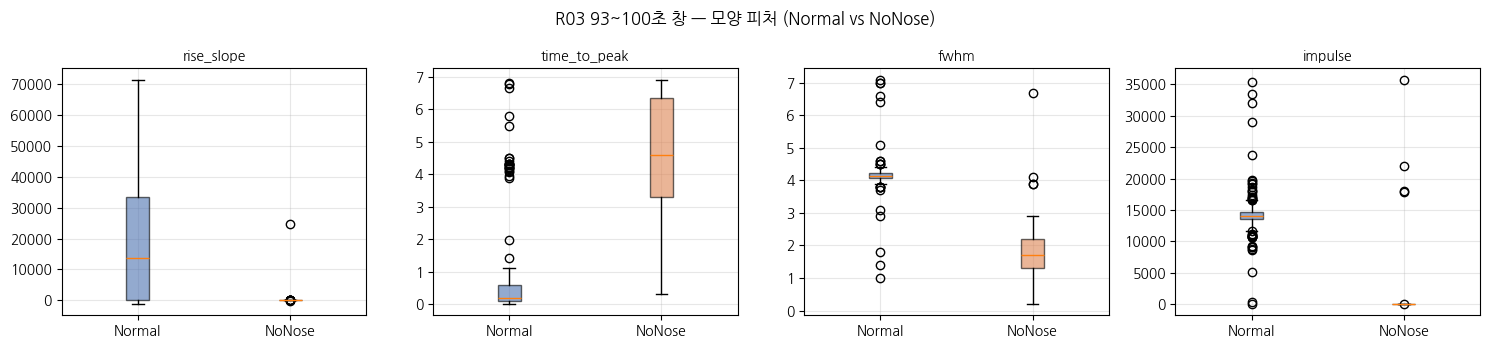

[R03 93~100초 창 — 모양 피처] Normal vs NoNose
  rise_slope    : Normal 15962.001 vs NoNose 417.213  |  p=0.0000  |  r=-0.803
  time_to_peak  : Normal 0.894 vs NoNose 4.490  |  p=0.0000  |  r=0.819
  fwhm          : Normal 4.176 vs NoNose 1.825  |  p=0.0000  |  r=-0.927
  impulse       : Normal 14337.508 vs NoNose 1655.040  |  p=0.0000  |  r=-0.859


In [66]:

# ── R03 Nose 창(93~100초) — 모양 피처 추가 (R04 Lag 대체) ──────────────────
r03_nose_shape = df_all.groupby('cycle_id').apply(
    lambda g: window_shape_features(g, NOSE_WINDOW_START, NOSE_WINDOW_END, 'I_R03_Gripper_Load'))

r03_shape_df = r03_nose_shape.join(label_by_cycle)
r03_shape_df = r03_shape_df[~r03_shape_df.index.str.startswith('0_')]
compare_shape = r03_shape_df[r03_shape_df['label'].isin(['Normal', 'NoNose'])]

# ① 먼저 눈으로
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, col in zip(axes, ['rise_slope', 'time_to_peak', 'fwhm', 'impulse']):
    aa = compare_shape.loc[compare_shape.label == 'Normal', col].dropna().values
    bb = compare_shape.loc[compare_shape.label == 'NoNose', col].dropna().values
    bp = ax.boxplot([aa, bb], tick_labels=['Normal', 'NoNose'], patch_artist=True)
    for patch, c in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.set_title(col, fontsize=10)
plt.suptitle('R03 93~100초 창 — 모양 피처 (Normal vs NoNose)')
plt.tight_layout()
plt.show()

# ② 검정으로 뒷받침
print('[R03 93~100초 창 — 모양 피처] Normal vs NoNose')
for col in ['rise_slope', 'time_to_peak', 'fwhm', 'impulse']:
    aa = compare_shape.loc[compare_shape['label'] == 'Normal', col].dropna()
    bb = compare_shape.loc[compare_shape['label'] == 'NoNose', col].dropna()
    if len(aa) >= 2 and len(bb) >= 2:
        stat, pval = mannwhitneyu(aa, bb, alternative='two-sided')
        r_eff = rank_biserial(stat, len(aa), len(bb))
        print(f'  {col:14s}: Normal {aa.mean():.3f} vs NoNose {bb.mean():.3f}  |  p={pval:.4f}  |  r={r_eff:.3f}')


**해석**: `time_to_peak`를 뺀 나머지 3개(rise_slope·fwhm·impulse)는 효과크기가 매우 크다
(|r|>0.85). 다만 `rise_slope`는 여기서도 이상치(Normal 쪽 최댓값 175만) 때문에 상자가
깨져 보인다 — 18-1에서 지적한 것과 같은 문제다. **핵심 신호(fwhm·impulse)는 그래프로도
확실히 뒷받침되지만, `rise_slope`는 모델에 넣기 전 이상치 처리가 필요하다는 점을
다시 확인한다.**


In [67]:
check_rise_slope_nan(r03_nose_shape, label_by_cycle, 'r03_nose_shape (수정 후)')
print('\n(참고) 수정 전에는 Normal 클래스에서 50개 결측이 있었음 — 위 결과와 비교할 것.')

[r03_nose_shape (수정 후)] rise_slope 결측 개수 (클래스별):
label
NoNose                    0
NoNose,NoBody2            0
NoNose,NoBody2,NoBody1    0
Normal                    0
Name: rise_slope, dtype: int64

(참고) 수정 전에는 Normal 클래스에서 50개 결측이 있었음 — 위 결과와 비교할 것.


### 18-2-1. 경계 케이스 추가 수정 — `t_peak == start` (예: `5_182`, v79 신규)

18-2에서 고친 2점 기울기 대체 로직에도 빠진 경계가 하나 있었다: **피크가 구간 시작(93.0초)과
정확히 같은 시각에 찍히는 사이클**이다. 이 경우 `rising_mask.sum()`이 1이라 회귀 분기를
못 타고, 기존 조건 `t_peak > start`도 `>` 이라 `==`인 케이스를 못 잡아 결국 `else: slope = np.nan`
으로 떨어졌다. `5_182`가 실제 사례다 — 93.0초 시점 값(4096)이 baseline(1384)과 가장 크게
벌어진 채로 이후 계속 하강하는, 즉 **구간 진입 즉시 피크를 찍는** 정상적인 물리 패턴이었다.

**수정**: 조건을 `t_peak > start` → `t_peak >= start`로 완화하고, 분모가 정확히 0이 되는 것을
막기 위해 `denom = max(t_peak - start, 0.1)`로 최소 분모(샘플링 주기 1개분)를 보장했다
(위 셀에 반영, `window_shape_features` 함수 본문).


### 18-2-2. 클리핑 아티팩트 확인 및 IQR 클리핑 도입 (v79 신규)

18-2-1 수정 직후 `r03_nose_shape`의 `rise_slope` 분포를 다시 보니 Normal 그룹 평균이
15968까지 치솟았다(median도 13847로 여전히 큼). 상위 극단값(`5_188`: 71380, `5_115`: 54370 등)의
`time_to_peak`을 직접 확인한 결과 전부 **0.001~0.098초**, 즉 방금 도입한 최소 분모(0.1초)
바로 아래에 몰려 있었다. 10Hz 샘플링(주기 0.1초)보다 짧은 시간차를 억지로 0.1초로 나눈
**분모 클리핑 인공물**이지, 실제로 그만큼 빠르게 파지했다는 물리적 의미가 아니다.

다행히 Mann-Whitney U(순위 기반)의 p-value·효과크기(rank-biserial)는 이 극단치에 영향받지
않아 지금까지의 통계적 결론(Normal vs NoNose 유의미 차이)은 안전하다. 다만 **평균 기반 통계나
RandomForest 이외의 모델**에 원본 `rise_slope`를 그대로 넣으면 왜곡될 수 있으므로, 아래 셀에서
IQR(3배) 기반 클리핑을 적용한다. 원본 값은 `rise_slope_raw` 컬럼에 그대로 보존해 필요시
비교·복구할 수 있게 한다.


In [68]:
# ── 18-2-2. rise_slope 극단치 IQR 클리핑 (v79 신규) ─────────────────────────
# 원본은 *_raw 컬럼에 보존하고, 이후 19장(최종 피처셋)에서 참조하는 'rise_slope'
# 컬럼 자체를 클리핑된 값으로 덮어써서 별도 하류 코드 수정 없이 적용되게 한다.

def clip_rise_slope_iqr(series, k=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return series.clip(lower, upper)


# R03 Nose 모양 피처
r03_nose_shape['rise_slope_raw'] = r03_nose_shape['rise_slope']
r03_nose_shape['rise_slope'] = clip_rise_slope_iqr(r03_nose_shape['rise_slope'])

# R04 Window 모양 피처 (Body1_제거·Body2_제거가 최종 피처셋에 쓰인다 — 18-3, 19장 참고)
for _part, _feat_df in window_feat_results.items():
    _feat_df['rise_slope_raw'] = _feat_df['rise_slope']
    _feat_df['rise_slope'] = clip_rise_slope_iqr(_feat_df['rise_slope'])

print('[클리핑 적용 완료] rise_slope 극단치를 IQR×3 경계로 눌렀습니다 (원본은 _raw 컬럼에 보존)')
print('\n[R03 Nose] 클리핑 전후 비교:')
print(r03_nose_shape[['rise_slope_raw', 'rise_slope']].describe())

compare_shape_v79 = r03_nose_shape.join(label_by_cycle)
compare_shape_v79 = compare_shape_v79[~compare_shape_v79.index.str.startswith('0_')]
compare_shape_v79 = compare_shape_v79[compare_shape_v79['label'].isin(['Normal', 'NoNose'])]
print('\n[클리핑 후, 클래스별 rise_slope]')
print(compare_shape_v79.groupby('label')['rise_slope'].describe())


[클리핑 적용 완료] rise_slope 극단치를 IQR×3 경계로 눌렀습니다 (원본은 _raw 컬럼에 보존)

[R03 Nose] 클리핑 전후 비교:
       rise_slope_raw  rise_slope
count        323.0000    323.0000
mean        7846.6415   7787.9011
std        14071.9615  13843.4656
min        -1186.3290  -1186.3290
25%           -1.3670     -1.3670
50%            2.5921      2.5921
75%        13344.8323  13344.8323
max        71380.0000  53383.4303

[클리핑 후, 클래스별 rise_slope]
          count       mean        std        min     25%        50%  \
label                                                                 
NoNose  59.0000   417.2132  3221.5986  -166.7217 -2.7168    -1.4743   
Normal 156.0000 15840.3786 16292.8838 -1186.3290 81.1993 13844.1398   

              75%        max  
label                         
NoNose    -0.4800 24742.5878  
Normal 33577.5000 53383.4303  


## 19. 최종 피처셋 확정

기존 121개 유의미 피처(섹션 12) + 수정된 Window 피처(R04, Nose 제외) + **R03 93~100초
Nose 신호**(주 신호, 최댓값+모양 피처) + R04 딥그랩 횟수(NoBody2/전체결측 판별용)를 통합한다.
R04 기반 Nose 신호(window 모양 피처, Lag)는 시간대 오염이 확인되어 **제외**한다(18-1 참고).


In [69]:
# ── 사이클 단위 최종 피처셋 통합 (튜터 피드백 반영판) ─────────────────────────
final_features = cycle_feat[sig_feat_cols].copy() if 'sig_feat_cols' in dir() else pd.DataFrame(index=cycle_defect_flags.index)
final_features = final_features.reindex(label_by_cycle.index)
final_features['label'] = label_by_cycle

# 주 신호: R03 93~100초 Nose 피크 + 모양 피처 (Lag 대체)
final_features['r03_nose_peak'] = r03_nose_peak
for col in ['rise_slope', 'time_to_peak', 'fwhm', 'impulse']:
    final_features[f'r03_nose_{col}'] = r03_nose_shape[col]

# R04 딥그랩 횟수 (NoBody2·전체결측 판별에 강력 — Nose 판별용이 아니므로 유지)
final_features['r04_grab_count'] = grab_counts

# Window 피처 (수정된 경계) — ★ Nose_제거는 R04 시간대 오염으로 제외, Body1/Body2만 유지
for part, feat_df in window_feat_results.items():
    if part == 'Nose_제거':
        continue  # 튜터 피드백: R04 힘은 시간대에 물린 신호 → Nose 판별에서 폐기
    for col in ['rise_slope', 'time_to_peak', 'fwhm', 'impulse']:
        final_features[f'r04_{part}_{col}'] = feat_df[col]

# ※ r04_pot_load_lag_nose 는 튜터 피드백에 따라 최종 피처셋에서 제외한다.
#   (Lag 자체를 통계 임계치 기준으로 쓰지 말 것 — 위 r03_nose_shape로 대체)

# 불완전 사이클 최종 제외
final_features = final_features[~final_features.index.isin(CANDIDATE_INCOMPLETE)]
# ── 세션0 제외 대상 정확히 캡처 (여기서 잡아야 정확함) ──────────────────
session0_ids = sorted(final_features.index[final_features.index.str.startswith('0_')])
print(f"세션0 제외 대상 ({len(session0_ids)}개): {session0_ids}")
final_features = final_features[~final_features.index.str.startswith('0_')]

print(f'최종 피처셋 shape: {final_features.shape}')
print(final_features.columns.tolist())
final_features.to_csv('/content/ffcell_final_features.csv', index=True)
print('\n저장 완료: ffcell_final_features.csv')


세션0 제외 대상 (3개): ['0_1', '0_2', '0_3']
최종 피처셋 shape: (320, 124)
['I_R03_Gripper_Load_mean', 'I_R02_Gripper_Pot_mean', 'I_R02_Gripper_Pot_std', 'I_R02_Gripper_Pot_min', 'I_R03_Gripper_Load_std', 'I_R04_Gripper_Pot_std', 'I_R04_Gripper_Pot_mean', 'I_R03_Gripper_Pot_max', 'I_R04_Gripper_Load_mean', 'I_R01_Gripper_Pot_mean', 'I_R01_Gripper_Load_mean', 'I_R02_Gripper_Load_mean', 'I_R04_Gripper_Load_std', 'I_R03_Gripper_Load_max', 'I_R02_Gripper_Pot_max', 'I_R03_Gripper_Pot_mean', 'I_R04_Gripper_Load_sign_std', 'I_R03_Gripper_Pot_std', 'I_R04_Gripper_Load_sign_mean', 'I_R01_Gripper_Load_max', 'M_R03_RJointAngle_Degree_mean', 'M_R03_UJointAngle_Degree_std', 'I_R01_Gripper_Load_min', 'I_R01_Gripper_Pot_max', 'M_R03_BJointAngle_Degree_mean', 'M_R03_UJointAngle_Degree_mean', 'Q_Cell_CycleCount_mean', 'Q_Cell_CycleCount_min', 'Q_Cell_CycleCount_max', 'M_R03_RJointAngle_Degree_std', 'M_R03_LJointAngle_Degree_mean', 'M_R03_SJointAngle_Degree_mean', 'M_R03_LJointAngle_Degree_std', 'M_R03_BJointAngle_

In [70]:
# ── 체크포인트 저장: PART 4 완료 시점 final_features (v80 신규) ───────────────────
# 위쪽 '빠른 재시작' 셀에서 USE_CHECKPOINT='final_features'로 불러올 수 있도록 저장한다.
# 모델링(PART 5)이나 그 이후만 반복 확인할 때, PART 1~4 전체를 다시 돌릴 필요 없이
# 여기서부터 바로 이어서 시작할 수 있다.
from pathlib import Path
_CACHE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints')
_CACHE_DIR.mkdir(parents=True, exist_ok=True)
final_features.to_pickle(_CACHE_DIR / 'final_features.pkl')
print(f"[체크포인트 저장 완료] final_features → {_CACHE_DIR / 'final_features.pkl'}  {final_features.shape}")


[체크포인트 저장 완료] final_features → /content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints/final_features.pkl  (320, 124)


In [ ]:
# ── [분할 파일 경계 체크포인트] part4 완료 시점 전체 세션 저장 (dill) ──────────────
# 다음 분할 파일의 첫 셀에서 이 파일을 그대로 불러와 이어서 실행한다.
# final_features 같은 개별 변수만이 아니라, 이 지점까지 정의된 함수·변수·import를
# 전부(dill.dump_session) 통째로 저장하므로 뒷 파일에서 별도 재정의가 필요 없다.
from pathlib import Path
_CACHE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints')
_CACHE_DIR.mkdir(parents=True, exist_ok=True)

try:
    import dill
except ImportError:
    !pip install dill --quiet
    import dill

_session_path = _CACHE_DIR / 'part4_session.pkl'
dill.dump_session(str(_session_path))
print(f"[분할 체크포인트 저장 완료] {_session_path}")
